In [46]:
# A carrier object has an ID and dictionaries with all Vehicles and all Services
class Carrier:  
    """
    This class represents a Carrier with an ID and dictionaries with all Vehicles and all Services.
    """
        
    def __init__(self, carrierID): 
        self.carrierID = carrierID 
        self.vehicles = {} 
        self.services = {}   
        self.missedDeliveries = []
        self.logisticProvider = getProviderFromID(self.carrierID)
        
    def __str__(self):
        return "[Carrier ID: " + str(self.carrierID) + " with " + str(len(self.vehicles)) + " Vehicles and " + str(len(self.services)) + " Services]"
    
    def __repr__(self):
        return self.__str__()
    
    def getNumberOfVehicles(self):
        return (len(self.vehicles))
    
    def getNumberOfServices(self):
        return (len(self.services))
        
    def addVehicle(self, vehicle): 
        self.vehicles[vehicle.getVehicleId] = vehicle
        
    def addService(self, service): 
        self.services[service.getServiceID] = service

    def getTotalNumberofServices(self):  
        return sum((s.getDemand() for s in self.services.values()))
    
    def getProvider(self):
        return self.logisticProvider
    
    def getServices(self): 
        return [s for s in self.services.values()]   
    
    def getCarrierId(self): 
        return self.carrierID    
    
    def getVehicles(self): 
        return self.vehicles
    
    def getMissedDeliveries(self): 
        return self.missedDeliveries  
    
    def setMissedDeliveries(self, missDeliveries): 
        self.missedDeliveries = missDeliveries


# A Vehicle has an ID, a Typ and you can add Plans to this vehicles with services and Routes. 
# These Vehicles / Plans have to be converted to Sumo! 
class Vehicle: 
    """
    This class represents a Vehicle with an ID, a Type and you can add Plans to this vehicles with services and Routes.
    """
        
    def __init__(self, vehicleID, vehicleType): 
        self.vehicleID = vehicleID 
        self.vehicleType = vehicleType 
        self.plans = []
        
    def __str__(self):
        return "[Vehicle ID: " + str(self.vehicleID) + " with Type: " + self.vehicleType +"]"
    
    def __repr__(self):
        return self.__str__()
    
    def addVehiclePlan(self, plan): 
        self.plans.append(plan)
        
    def changeVehicleType(self, vehicleType): 
        self.vehicleType == vehicleType
        
    def getVehicleId(self): 
        return self.vehicleID
    
    def getPlans(self):
        return self.plans


# A Plan is a sequence of Activies (start, service, service, ... , end)
# all important Information are stored in the activities / legs dictionary
# The Order of the sequence is stored as a list called "planSequence"
class Plan:  
    """
    This class represents a Plan which is a sequence of Activities (start, service, service, ... , end).
    """
        
    def __init__(self, planId, vehicle, activities, legs): 
        self.planId = planId
        self.vehicle = vehicle
        self.activities = activities 
        self.legs = legs 
        self.planSequence = [] 
        
    def __str__(self):
        return "[Plan ID: " + str(self.planId) + " with " + str(len(self.activities)) +" Activities and " + str(len(self.legs)) + " Legs]"
    
    def __repr__(self):
        return self.__str__()
    
    def getPlanSequence(self):
        return self.planSequence
    
    def createInternalPlanSequence(self):
        for i in range (len(self.legs)):            
            self.planSequence.append(get_nth_key(self.activities, i))
            self.planSequence.append(get_nth_key(self.legs, i))
        self.planSequence.append(get_nth_key(self.activities, len(self.activities)-1))    

# A Service is a data container storing all available information from the CSV/XML
class Service:
    """
    Data container for a delivery/pickup service.
    All durations are stored in seconds (int).
    Extra attributes are kept in a dict.
    """

    def __init__(self, serviceType, serviceID, capacityDemand, duration, link, extra_attributes=None):
        self.serviceType = serviceType
        self.serviceID = serviceID
        self.capacityDemand = capacityDemand
        # ensure duration is numeric seconds
        try:
            self.duration = int(duration)
        except Exception:
            self.duration = 0
        self.link = link
        self.extra_attributes = extra_attributes or {}

        # optional: vehicleType placeholder if you need it later
        self.vehicleType = self.extra_attributes.get("vehicleType", None)

    def __str__(self):
        return f"[Service ID: {self.serviceID} (Type: {self.serviceType}) with a CapacityDemand of {self.capacityDemand} to Link: {self.link}]"

    __repr__ = __str__

    # --- attributes API ---
    def getAttribute(self, key, default=None):
        return self.extra_attributes.get(key, default)

    def setAttribute(self, key, value):
        self.extra_attributes[key] = value

    # --- typed getters/setters ---
    def getServiceType(self):
        return self.serviceType

    def changeVehicleType(self, vehicleType):
        # was '==' before (no effect). Should assign.
        self.vehicleType = vehicleType
        self.extra_attributes["vehicleType"] = vehicleType

    def getDemand(self):
        return self.capacityDemand

    def getServiceID(self):
        return self.serviceID

    def getServiceLink(self):
        return self.link

    def setServiceLink(self, link):
        self.link = link

    def getDuration(self):
        """Return dwell time in seconds."""
        return int(self.duration)

    def setDuration(self, duration_s):
        """Set dwell time in seconds."""
        self.duration = int(duration_s)
        
        
        
# Get Logistic Provider from XML ID
def getProviderFromID(carrierID):
    """
    This function returns the provider name based on the carrier ID.
    
    Args:
        carrierID (str): The ID of the carrier.
        
    Returns:
        str: The name of the provider.
    """
        
    if("dhl" in str(carrierID)):
        return "dhl"  
    elif("amazon" in str(carrierID)):
        return "amazon"  
    elif("ups" in str(carrierID)):
        return "ups"  
    elif("gls" in str(carrierID)):
        return "gls"  
    elif("dpd" in str(carrierID)):
        return "dpd"  
    elif("fedex" in str(carrierID)):
        return "fedex"  
    elif("hermes" in str(carrierID)):
        return "hermes"  
    elif("wl" in str(carrierID)):
        return "White-Label"  
    else:
        raise ValueError('Carrier Provider unknown: ' + str(carrierID))
    
# Method returning the index of an element of a dictionary
def get_nth_key(dictionary, n=0):
    """
    This function returns the nth key of a dictionary.
    
    Args:
        dictionary (dict): The dictionary to get the key from.
        n (int): The index of the key to get. Default is 0.
        
    Returns:
        key: The nth key of the dictionary.
    """
        
    if n < 0:
        n += len(dictionary)
    for i, key in enumerate(dictionary.keys()):
        if i == n:
            return key
    raise IndexError("dictionary index out of range") 

In [47]:
import os
import re
import pickle
import pandas as pd

# --- Paths ---
BATCH_DIR = r"C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch"
OUTPUT_BASE = os.path.join(BATCH_DIR, r"processed")

# --- Helper to load pickles ---
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

# Only files like <run>_emissions_result.pkl
PATTERN = re.compile(r"^(?P<run>.+)_result\.pkl$", re.ASCII)

def load_all_operating_result(output_base):
    """
    Returns:
      results_by_run: dict run_name -> object loaded from pickle
      df_all: DataFrame concatenated across runs if each is a DataFrame
              otherwise None
    """
    results_by_run = {}
    frames = []

    for root, _, files in os.walk(output_base):
        for fn in files:
            m = PATTERN.match(fn)
            if not m:
                continue
            run_name = m.group("run")
            p = os.path.join(root, fn)
            try:
                obj = load_pickle(p)
            except Exception as e:
                print(f"[WARN] Could not load {p}: {e}")
                continue

            results_by_run[run_name] = obj

            # If the object is a DataFrame, collect for concatenation
            if isinstance(obj, pd.DataFrame):
                df = obj.copy()
                if "run_name" not in df.columns:
                    df["run_name"] = run_name
                frames.append(df)

    df_all = pd.concat(frames, ignore_index=True) if frames else None
    print(f"[INFO] Loaded emissions_result for {len(results_by_run)} runs from {output_base}")
    if df_all is not None:
        print("[INFO] Concatenated DataFrame shape:", df_all.shape)
    return results_by_run, df_all

# --- Execute load ---
results_by_run, df_all = load_all_operating_result(OUTPUT_BASE)

# Example: inspect keys and one sample
print("Runs:", list(results_by_run.keys())[:10])

# If you want just the combined table:
if df_all is not None:
    display(df_all.head())


[INFO] Loaded emissions_result for 48 runs from C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\processed
[INFO] Concatenated DataFrame shape: (119073, 62)
Runs: ['basecase_12052025_iter150_jsprit100', 'basecase_13052025_iter150_jsprit100', 'basecase_14052025_iter150_jsprit100', 'basecase_15052025_iter150_jsprit100', 'basecase_16052025_iter150_jsprit100', 'basecase_17052025_iter150_jsprit100', 'batchhigh_12052025_iter150_jsprit100', 'batchhigh_13052025_iter150_jsprit100', 'batchhigh_14052025_iter150_jsprit100', 'batchhigh_15052025_iter150_jsprit100']


,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,run_name,Tour Duration,Travel Duration,tour_km,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
df_all

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,run_name,Tour Duration,Travel Duration,tour_km,initial_delivery_distance,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,basecase_12052025_iter150_jsprit100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119068,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,NaN,1873.0,NaN,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,batchmoderate_17052025_iter150_jsprit100_emiss...,5963.0,4090.0,47.124502,18.844908,0.090909,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Rural with Industrial Influence
119069,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,NaN,3630.0,NaN,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,batchmoderate_17052025_iter150_jsprit100_emiss...,14296.0,10666.0,93.165305,34.231393,0.181818,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Urbanized Periphery
119070,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,NaN,4035.0,NaN,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,batchmoderate_17052025_iter150_jsprit100_emiss...,9254.0,5219.0,44.599322,4.331356,0.193939,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Rural with Industrial Influence
119071,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,NaN,1848.0,NaN,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,batchmoderate_17052025_iter150_jsprit100_emiss...,4945.0,3097.0,69.829936,32.424032,0.090909,True,1.0,"{'drive': 0.0, 'idle': 0.0, 'cold': 0.0, 'tota...",Urbanized Periphery


In [49]:
df_all = df_all[df_all["Vehicle Utilization (%)"] > 0.05]

In [50]:
df_all["Cost per Parcel [€/parcel]"] =  df_all["vehicle_cost"] / df_all["deliveries"] 

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_14516\2849653561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["Cost per Parcel [€/parcel]"] =  df_all["vehicle_cost"] / df_all["deliveries"]


In [129]:
import pandas as pd

# Example: df_all["run_name"] = ["basecase_12052025_iter150_jsprit100", "basecase_13052025_iter150_jsprit100", ...]

# Function to extract weekday name from run_name
def extract_weekday_from_runname(run_name):
    """
    Extracts date (DDMMYYYY) from run_name like 'basecase_12052025_iter150_jsprit100'
    and returns the corresponding weekday name ('Monday', 'Tuesday', ...)
    """
    import re
    from datetime import datetime

    m = re.search(r"_(\d{8})_", run_name)
    if not m:
        return None
    date_str = m.group(1)
    try:
        dt = datetime.strptime(date_str, "%d%m%Y")
        return dt.strftime("%A")  # English weekday name
    except Exception:
        return None

# Apply to your DataFrame
df_all["weekday"] = df_all["run_name"].astype(str).apply(extract_weekday_from_runname)

# Optional: if you prefer English names even when German ones are present
weekday_map = {
    "Montag": "Monday",
    "Dienstag": "Tuesday",
    "Mittwoch": "Wednesday",
    "Donnerstag": "Thursday",
    "Freitag": "Friday",
    "Samstag": "Saturday",
    "Sonntag": "Sunday",
}
df_all["weekday"] = df_all["weekday"].replace(weekday_map)

# Inspect result
print(df_all[["run_name", "weekday"]].head())


                              run_name weekday
0  basecase_12052025_iter150_jsprit100  Monday
1  basecase_12052025_iter150_jsprit100  Monday
2  basecase_12052025_iter150_jsprit100  Monday
3  basecase_12052025_iter150_jsprit100  Monday
4  basecase_12052025_iter150_jsprit100  Monday


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_14516\2527830859.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["weekday"] = df_all["run_name"].astype(str).apply(extract_weekday_from_runname)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_14516\2527830859.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["weekday"] = df_all["weekday"].replace(weekday_map)


In [52]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

In [53]:
import numpy as np
# Filter tours: Mixed carrier, Urban area, Wednesday, scenario = batchhigh

import re
from datetime import datetime

df = df_all.copy()

# Ensure scenario column from run_name prefix
if "scenario" not in df.columns:
    if "run_name" not in df.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    df["scenario"] = df["run_name"].astype(str).str.split("_").str[0]



# Provider active batch days (English weekday names)
provider_active_days = {
    "dhl": {"Monday", "Wednesday", "Friday"},
    "hermes": {"Tuesday", "Saturday"},
    "dpd": {"Tuesday", "Friday"},
    "gls": {"Monday", "Thursday"},
    "ups": {"Monday", "Thursday"},
    "amazon": {"Tuesday", "Thursday", "Saturday"},
    "fedex": {"Monday", "Thursday"},
}

def _is_active(row):
    prov = str(row.get("provider", "")).strip().lower()
    wd = str(row.get("weekday", "")).strip()
    days = provider_active_days.get(prov, set())
    return wd in days

df["active_flag"] = df.apply(_is_active, axis=1)
df["activity_group"] = np.where(
    df["active_flag"],
    "Batch Delivery Day",
    "Non-batch Delivery Day"
)

# Area column can be area_type_agg or area_type
area_col = "area_type_agg" if "area_type_agg" in df.columns else ("area_type" if "area_type" in df.columns else None)
if area_col is None:
    raise RuntimeError("Neither 'area_type_agg' nor 'area_type' is present in df_all.")

# Robust alias mapping: raw -> canonical
rename_to_canonical = {
    "Tour Length (km)": "Distance per Tour (km)",
    "delivery_area_km2": "Delivery Area (km^2)",
    "deliveries_per_stop": "Deliveries per Stop",
}

# Apply mapping only for columns that exist
rename_actual = {raw: canon for raw, canon in rename_to_canonical.items() if raw in df.columns}
df.rename(columns=rename_actual, inplace=True)

# Canonical KPI list for downstream code
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    # add if you want it in the plot/table:
    "Driving Share of Tour (%)",
]

# Ensure all KPI columns are numeric
for c in kpis:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Optional sanity check
missing_kpis = [c for c in kpis if c not in df.columns]
if missing_kpis:
    print("[WARN] Missing KPI columns after rename:", missing_kpis)





In [54]:
# Ensure scenario column from run_name prefix
if "scenario" not in df_all.columns:
    if "run_name" not in df_all.columns:
        raise RuntimeError("Column 'run_name' is missing in df_all.")
    df_all["scenario"] = df_all["run_name"].astype(str).str.split("_").str[0]

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_14516\1268560380.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all["scenario"] = df_all["run_name"].astype(str).str.split("_").str[0]


In [55]:
df_all.groupby("scenario").size()

scenario
basecase          9979
batchhigh         9661
batchmedium      10031
batchmoderate     9804
dtype: int64

In [56]:
# KPIs, nur die die du im Plot nutzt
# Canonical KPI list for downstream code
kpis = [
    "Vehicle Utilization (%)",
    "Distance per Tour (km)",
    "Initial Delivery Distance (km)",
    "Mean Distance Between Stops (km)",
    "Delivery Area (km^2)",
    "Deliveries per Stop",
    # add if you want it in the plot/table:
    "Driving Share of Tour (%)",
]
# Vektorisiert sicherstellen, dass es numerisch ist
for c in kpis:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Szenario-Mittel je activity_group x weekday x scenario
grp = ["activity_group", "weekday", "scenario"]
if "run_name" in df.columns:
    per_run = df.groupby(grp + ["run_name"], dropna=False)[kpis].mean().reset_index()
    scen_avg = per_run.groupby(grp, dropna=False)[kpis].mean().reset_index()
else:
    scen_avg = df.groupby(grp, dropna=False)[kpis].mean().reset_index()

# Baseline erkennen
def _detect_baseline(cands):
    keys = ["basecase","baseline","base","bau","ref","reference","statusquo","status_quo","status-quo","basis","default"]
    for k in keys:
        for s in cands:
            if k in str(s).lower():
                return s
    return None

BASELINE = _detect_baseline(scen_avg["scenario"].astype(str).unique().tolist()) or \
           sorted(scen_avg["scenario"].astype(str).unique().tolist())[0]

# Baseline je activity_group x weekday
base = (
    scen_avg[scen_avg["scenario"] == BASELINE]
    .loc[:, ["activity_group","weekday"] + kpis]
    .rename(columns={c: f"base__{c}" for c in kpis})
)

# Merge und Prozentdeltas
m = scen_avg.merge(base, on=["activity_group","weekday"], how="left")

for c in kpis:
    num = pd.to_numeric(m[c], errors="coerce")
    den = pd.to_numeric(m[f"base__{c}"], errors="coerce")
    # Prozentdelta, Inf -> NaN
    m[c] = (num / den - 1.0) * 100.0
m[kpis] = m[kpis].replace([np.inf, -np.inf], np.nan)

# Das ist deine saubere Tabelle für den Plot
pct_tbl = m[["activity_group","weekday","scenario"] + kpis].copy()

# Debug: prüfe, ob Baseline je Gruppe vorhanden ist
pct_tbl

,activity_group,weekday,scenario,Vehicle Utilization (%),Distance per Tour (km),Initial Delivery Distance (km),Mean Distance Between Stops (km),Delivery Area (km^2),Deliveries per Stop,Driving Share of Tour (%)
0,Batch Delivery Day,Friday,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Batch Delivery Day,Friday,batchhigh,3.969037,-12.955096,18.345289,17.573777,23.303562,65.246817,-12.572324
2,Batch Delivery Day,Friday,batchmedium,3.696106,-9.664197,19.121608,20.591875,31.426478,60.546884,-10.786673
3,Batch Delivery Day,Friday,batchmoderate,0.520690,-5.624324,6.847816,3.805297,-18.054764,19.409891,-7.376012
4,Batch Delivery Day,Monday,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Batch Delivery Day,Monday,batchhigh,4.953727,-18.038602,9.731035,-0.685345,-34.547478,60.280761,-13.989055
6,Batch Delivery Day,Monday,batchmedium,3.984435,1.611932,16.011666,39.818763,68.066630,46.328740,-1.565291
7,Batch Delivery Day,Monday,batchmoderate,3.829094,-5.931446,7.575808,1.048560,-17.532545,24.041161,-6.300760
8,Batch Delivery Day,Saturday,basecase,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Batch Delivery Day,Saturday,batchhigh,11.931385,-14.891603,4.857483,25.082742,10.110136,87.664566,-14.725311


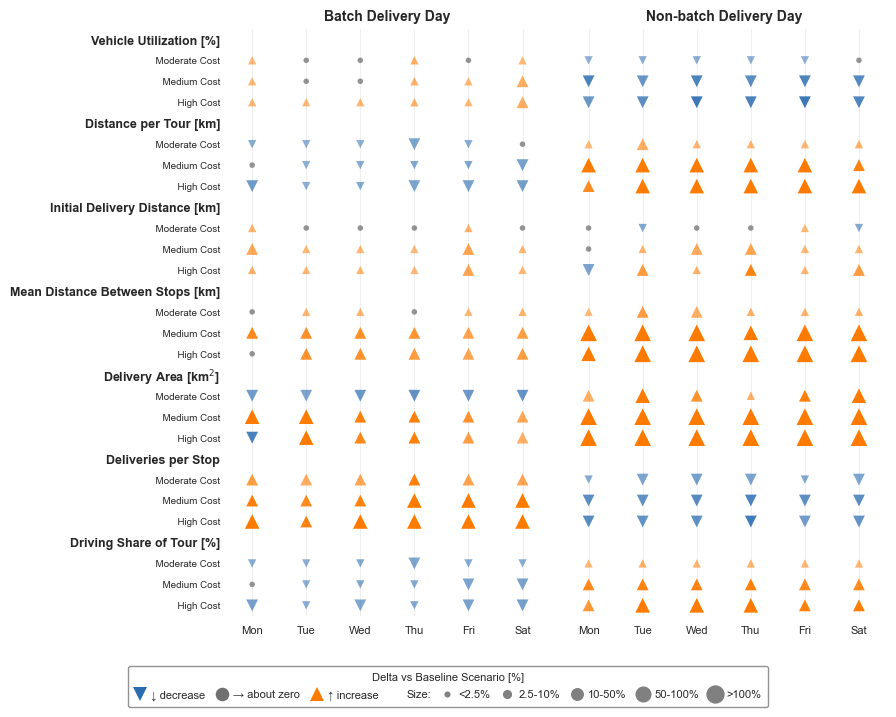

In [57]:
# -----------------------------
# Plot settings: scenarios without baseline
# -----------------------------
scen_order_pref = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
present_scens = pct_tbl["scenario"].astype(str).unique().tolist()
scenarios_all = [s for s in scen_order_pref if s in present_scens] or sorted(present_scens)
scenarios_plot = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] if s in scenarios_all]
scenario_display = {"batchmoderate": "Moderate Cost", "batchmedium": "Medium Cost", "batchhigh": "High Cost"}

weekday_order  = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sns.set_style("whitegrid")
# -----------------------------
# Visual encoding
# -----------------------------
NEUTRAL_BAND = 2.5
COLOR_NEG = "#2b6cb0"
COLOR_NEU = "#707070"
COLOR_POS = "#ff7b00"

# size range for scatter areas (pt^2)
MIN_SIZE = 24
MAX_SIZE = 80
SIZE_CAP = 50.0  # cap absolute pct delta at 50 for sizing


def color_for_delta(x: float):
    """
    Return (facecolor, edgecolor, filled_flag) with color fixed and alpha scaled by |x|.
    The stronger the deviation, the more opaque the bubble.
    """
    import numpy as np
    import matplotlib.colors as mcolors

    if not np.isfinite(x):
        return ("white", "0.5", False)

    # Normalize deviation magnitude (0 = none, 1 = full intensity)
    a = abs(float(x))
    t = min(a / SIZE_CAP, 1.0)

    # Alpha grows with deviation magnitude (from 0.25 to 1.0)
    alpha = 0.5 + 0.5 * t

    # Choose base color by sign (fixed hue)
    if x < -NEUTRAL_BAND:
        base = COLOR_NEG
    elif x > NEUTRAL_BAND:
        base = COLOR_POS
    else:
        base = COLOR_NEU
        alpha = 0.75  # neutral band slightly lighter

    # Convert hex color to RGBA with adjusted alpha
    rgba = list(mcolors.to_rgba(base))
    rgba[3] = alpha  # only modify alpha

    return (tuple(rgba), "none", True)


def kpi_display(name: str) -> str:
    if not isinstance(name, str):
        return str(name)
    if name.strip() in ("Delivery Area (km^2)", "Delivery Area (km²)"):
        return "Delivery Area [km$^2$]"
    m = re.match(r"^(.*)\s*\(([^)]+)\)\s*$", name.strip())
    if not m:
        return name
    base = m.group(1).strip()
    unit = m.group(2).strip().replace("km²", "km^2").replace("^2", "$^2$")
    return f"{base} [{unit}]"


## Constants
MIN_SIZE = 4    # radius for the smallest bin
MAX_SIZE = 12   # radius for the largest bin
# Diskrete Radien je Bin, von klein nach groß
# Passe die vier Zwischenwerte bei Bedarf an
BIN_RADII = [
    MIN_SIZE,          # for |delta| < 2.5
    6,                 # for 2.5 <= |delta| < 10
    8.5,               # for 10 <= |delta| < 50
    10.5,              # for 50 <= |delta| <= 100
    MAX_SIZE           # for |delta| > 100
]

# Diskrete Schwellen in Prozent, strikt aufsteigend
# Bins: [0,2.5), [2.5,10), [10,50), [50,100], (100,inf)
THRESHOLDS = [2.5, 10.0, 50.0, 100.0]

def size_for_delta(x: float) -> float:
    """
    Return bubble area for absolute percent delta using discrete bins.
    No interpolation. No overshoot. Area = radius**2.
    """
    if not np.isfinite(x):
        return float(BIN_RADII[0] ** 2)

    a = abs(float(x))

    # map to bin index
    if a < THRESHOLDS[0]:
        idx = 0
    elif a < THRESHOLDS[1]:
        idx = 1
    elif a < THRESHOLDS[2]:
        idx = 2
    elif a <= THRESHOLDS[3]:
        idx = 3
    else:
        idx = 4

    r = BIN_RADII[idx] if 'BIN_RADII' in globals() else BIN_RADII[idx]
    return float(r ** 2)

# --- keep your color_for_delta, it returns RGBA with per-point alpha ---
# unchanged function body from your latest version

def plot_panel(ax, df_group, title, kpis, scenarios_plot):
    # rows...
    rows, is_header = [], []
    vals = []  # store values for sign-based markers
    for k in kpis:
        rows.append((k, None)); is_header.append(True); vals.append(np.nan)
        for s in scenarios_plot:
            rows.append((k, s)); is_header.append(False); vals.append(np.nan)

    n_rows = len(rows)
    n_cols = len(weekday_order)

    xs, ys, ss = [], [], []
    facecols, edgecols, filled_flags = [], [], []
    vals = np.array(vals, dtype=float)

    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_group[df_group["scenario"] == s]
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan
            vals[r_idx] = val if np.isfinite(val) else vals[r_idx]
            sz = size_for_delta(val)
            fc, ec, filled = color_for_delta(val)
            xs.append(c_idx); ys.append(r_idx); ss.append(sz)
            facecols.append(fc); edgecols.append(ec); filled_flags.append(bool(filled))

    xs = np.array(xs); ys = np.array(ys); ss = np.array(ss)

    # Convert facecolors to a proper (N,4) float array to preserve per-point alpha
    import matplotlib.colors as mcolors
    facecols = mcolors.to_rgba_array(facecols)  # shape (N,4)
    edgecols = np.array(edgecols, dtype=object)
    filled_flags = np.array(filled_flags, dtype=bool)

    # sign masks for arrow markers
    val_arr = facecols[:, 0] * 0  # dummy to get length
    # derive sign from colors? better recompute from per-point alpha not available -> use edgecols len equals N
    # keep a parallel list of values aligned with points
    # We stored last val per row; need per point -> recompute quickly
    all_vals = []
    for (k, s) in rows:
        if s is None:
            continue
    # rebuild value list for points
    all_vals = []
    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_group[df_group["scenario"] == s]
        for wd in weekday_order:
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan
            all_vals.append(val)
    all_vals = np.array(all_vals, dtype=float)

    neg_mask = all_vals < -NEUTRAL_BAND
    pos_mask = all_vals > NEUTRAL_BAND
    neu_mask = ~(neg_mask | pos_mask)

    # draw neutral (circles), increases (up), decreases (down) preserving per-point alpha
    if neu_mask.any():
        ax.scatter(
            xs[neu_mask], ys[neu_mask], s=ss[neu_mask],
            facecolors=facecols[neu_mask], edgecolors="none", marker="o"
        )
    if pos_mask.any():
        ax.scatter(
            xs[pos_mask], ys[pos_mask], s=ss[pos_mask],
            facecolors=facecols[pos_mask], edgecolors="none", marker="^"
        )
    if neg_mask.any():
        ax.scatter(
            xs[neg_mask], ys[neg_mask], s=ss[neg_mask],
            facecolors=facecols[neg_mask], edgecolors="none", marker="v"
        )

    # ticks and labels unchanged...
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels, fontsize=8)

    yticklabels = []
    for (k, s), hdr in zip(rows, is_header):
        if hdr:
            yticklabels.append(kpi_display(k))
        else:
            yticklabels.append("  " + scenario_display.get(str(s), str(s)))
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(yticklabels, fontsize=7)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, len(rows) - 0.5)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)
    # for y_idx, hdr in enumerate(is_header):
        # if hdr:
        #     ax.axhline(y_idx - 0.5, color="0.85", linewidth=1.1)
    for lbl, hdr in zip(ax.get_yticklabels(), is_header):
        if hdr:
            lbl.set_fontweight("bold"); lbl.set_fontsize(9)

    ax.set_axisbelow(True)
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=10, pad=6, weight="bold")
    
    ax.grid(False)                 # alles aus
    ax.grid(axis="x", alpha=0.3)   # nur vertikal wieder an
    ax.yaxis.grid(False)           # redundant, aber explizit

# -----------------------------
# Build figure with two panels: Active vs Not active
# -----------------------------

present_groups = list(pct_tbl["activity_group"].unique())
if not present_groups:
    raise RuntimeError("No activity groups found in pct_tbl.")

fig_w, fig_h = 9.0, 6.5
fig, axes = plt.subplots(1, len(present_groups), figsize=(fig_w, fig_h))
if len(present_groups) == 1:
    axes = np.array([axes])

plt.subplots_adjust(top=0.88, bottom=0.25, left=0.08, right=0.95, wspace=0.25)

for j, g in enumerate(present_groups):
    ax = axes[j]
    df_g = pct_tbl[pct_tbl["activity_group"] == g]
    plot_panel(ax, df_g, g, kpis, scenarios_plot)
    if j != 0:
        ax.set_yticklabels([])

# Legend: single row, color keys with arrow markers + size keys
def make_bubble_legend_single_row(
    fig,
    color_items=None,
    size_labels=("<2.5%", "2.5-10%", "10-50%", "50-100%", ">100%"),
    separator_label="Size:",
    y_bottom=-0.10,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
 ):
    if color_items is None:
        color_items = [
            ("decrease", COLOR_NEG, False),
            ("about zero", COLOR_NEU, False),
            ("increase", COLOR_POS, False),
        ]
    marker_map = {"decrease": "v", "about zero": "o", "increase": "^"}
    label_map = {"decrease": "↓ decrease", "about zero": "→ about zero", "increase": "↑ increase"}

    handles, labels = [], []

    # Color legend (fixed marker size based on a mid bin), arrow markers for direction
    ms_color = BIN_RADII[2] * scale_colors  # mid bin radius for a balanced look
    for lab, col, hollow in color_items:
        marker_shape = marker_map.get(lab, "o")
        pretty_lab = label_map.get(lab, lab)
        h = Line2D(
            [0], [0], marker=marker_shape, linestyle="None",
            markersize=ms_color,
            markerfacecolor=("white" if hollow else col),
            markeredgecolor=("0.5" if hollow else "none"),
            markeredgewidth=(1.0 if hollow else 0.0)
        )
        handles.append(h)
        labels.append(pretty_lab)

    # Separator
    handles.append(Line2D([], [], linestyle="None"))
    labels.append(separator_label)

    # Size legend (neutral gray), use BIN_RADII directly (markersize expects radius in points)
    for r, lab in zip(BIN_RADII, size_labels):
        h = Line2D(
            [0], [0], marker="o", linestyle="None",
            markersize=(r * scale_sizes),
            markerfacecolor="#808080",
            markeredgecolor="none"
        )
        handles.append(h)
        labels.append(lab)

    leg = fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, y_bottom),
        ncol=len(labels),
        frameon=True, fancybox=True, framealpha=0.85,
        edgecolor="0.5", fontsize=8, title=legend_title,
        handlelength=1.0, handletextpad=0.5, columnspacing=1.0,
        borderpad=0.6, labelspacing=0.7
    )
    return leg

# Usage (no size_samples needed now; sizes come from BIN_RADII)
make_bubble_legend_single_row(
    fig,
    color_items=[
        ("decrease", COLOR_NEG, False),
        ("about zero", COLOR_NEU, False),
        ("increase", COLOR_POS, False),
    ],
    separator_label="Size:",
    y_bottom=-0.10,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
 )
plt.tight_layout()
# Save if needed
# fig.savefig("kpi_bubble_overview_active_vs_inactive.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [58]:
df.groupby("scenario")["vehicle_cost"].sum()

scenario
basecase         2.289263e+06
batchhigh        2.116528e+06
batchmedium      2.233142e+06
batchmoderate    2.248796e+06
Name: vehicle_cost, dtype: float64

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_14516\176004852.py:84: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Scenario", "Day"], as_index=False)["Total"].sum()


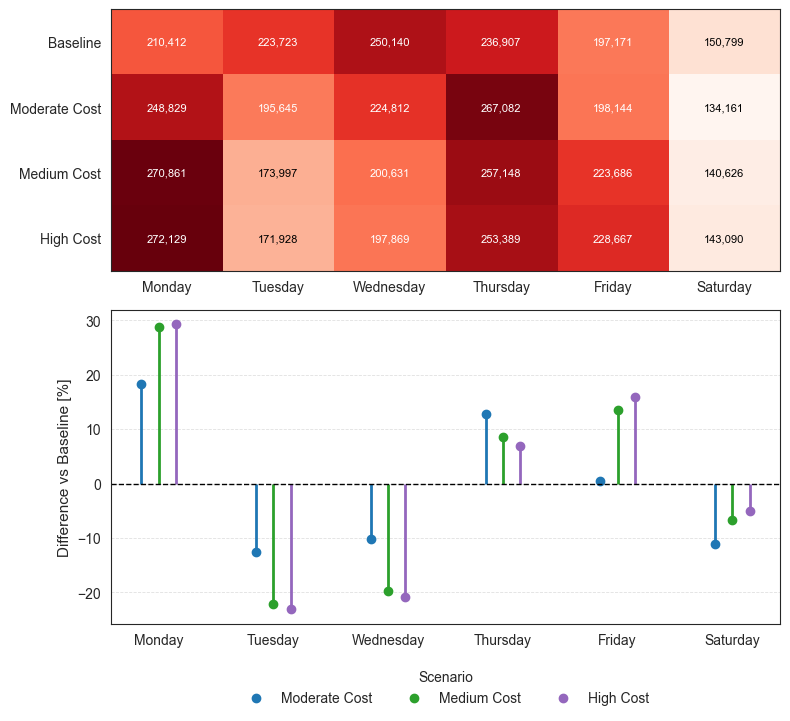

In [130]:
# Deliveries per scenario and weekday: heatmap + lollipop vs baseline (fixed order/colors)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_style("white")

# Fixed scenario column name
scenario_col = "scenario"
if scenario_col not in df.columns:
    raise KeyError(f"Expected column '{scenario_col}' in df")

# Resolve day and delivery columns flexibly
day_candidates = ["weekday", "Weekday", "day", "Day"]
delivery_candidates = ["deliveries", "Deliveries", "total_deliveries", "Total", "total"]

day_col = next((c for c in day_candidates if c in df.columns), None)
delivery_col = next((c for c in delivery_candidates if c in df.columns), None)

if day_col is None:
    raise KeyError(f"No weekday column found in df; expected one of {day_candidates}")
if delivery_col is None:
    raise KeyError(f"No deliveries column found in df; expected one of {delivery_candidates}")

# Orders (fallbacks if globals are missing)
if "weekday_order" in globals():
    day_order = list(weekday_order)
else:
    default_day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    present_days = df[day_col].dropna().astype(str).unique().tolist()
    day_order = [d for d in default_day_order if d in present_days] + [d for d in present_days if d not in default_day_order]

# Canonical order and colors
canonical_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"]
color_map = {
    "Baseline": "#808080",
    "Moderate Cost": "#1f77b4",  # blue
    "Medium Cost": "#2ca02c",    # green
    "High Cost": "#9467bd",      # purple
}

# Map actual scenario names to canonical display
def canonical_name(name: str) -> str:
    n = str(name).strip().lower()
    if "base" in n or n == "baseline":
        return "Baseline"
    if "moderate" in n:
        return "Moderate Cost"
    if "medium" in n:
        return "Medium Cost"
    if "high" in n:
        return "High Cost"
    return str(name)

actual_scens = df[scenario_col].dropna().astype(str).unique().tolist()
display_name = {s: canonical_name(s) for s in actual_scens}

# Build ordered list of actual scenario keys following canonical order
scenario_order = [
    s for canon in canonical_order
    for s in actual_scens
    if display_name[s] == canon
 ]
if not scenario_order:
    scenario_order = sorted(actual_scens)

# Pick baseline actual (first that maps to Baseline, else first)
baseline_candidates = [s for s in scenario_order if display_name[s] == "Baseline"]
BASELINE_SCENARIO = baseline_candidates[0] if baseline_candidates else scenario_order[0]

# Colors per actual scenario using canonical name
palette = sns.color_palette("Set1", len(scenario_order))
colors = {s: color_map.get(display_name[s], palette[i % len(palette)]) for i, s in enumerate(scenario_order)}

# Aggregate deliveries
df_day_total = (
    df.assign(
        Day=pd.Categorical(df[day_col], categories=day_order, ordered=True),
        Scenario=pd.Categorical(df[scenario_col], categories=scenario_order, ordered=True),
        Total=pd.to_numeric(df[delivery_col], errors="coerce"),
    )
    .groupby(["Scenario", "Day"], as_index=False)["Total"].sum()
 )

base = (
    df_day_total[df_day_total["Scenario"] == BASELINE_SCENARIO]
    .set_index("Day")["Total"]
    .astype(float)
)

df_rel = df_day_total[df_day_total["Scenario"] != BASELINE_SCENARIO].copy()
df_rel["Baseline"] = pd.to_numeric(df_rel["Day"].map(base), errors="coerce")
df_rel["Total"] = pd.to_numeric(df_rel["Total"], errors="coerce")
den = df_rel["Baseline"].replace(0, np.nan)
df_rel["Diff_%"] = (df_rel["Total"] / den - 1.0) * 100.0

# Heatmap pivot
pivot_abs = (
    df_day_total.pivot(index="Scenario", columns="Day", values="Total")
    .reindex(index=scenario_order, columns=day_order)
)

# Lollipop settings
scens = [s for s in scenario_order if s != BASELINE_SCENARIO]
x_idx = np.arange(len(day_order))
offsets = np.linspace(-0.15, 0.15, num=len(scens)) if len(scens) > 0 else [0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7.2), gridspec_kw={"height_ratios": [1, 1.2]})

# Heatmap
im = ax1.imshow(pivot_abs.values, aspect="auto", cmap="Reds")
ax1.set_yticks(np.arange(len(pivot_abs.index)))
ax1.set_yticklabels([display_name[s] for s in pivot_abs.index])
ax1.set_xticks(np.arange(len(pivot_abs.columns)))
ax1.set_xticklabels(pivot_abs.columns)

vmax = np.nanmax(pivot_abs.values) if np.isfinite(pivot_abs.values).any() else 0
for i in range(pivot_abs.shape[0]):
    for j in range(pivot_abs.shape[1]):
        val = pivot_abs.values[i, j]
        ax1.text(
            j, i, f"{val:,.0f}", ha="center", va="center", fontsize=8,
            color="white" if vmax and val > 0.65 * vmax else "black"
        )

# ax1.set_title("Total deliveries per scenario and weekday", fontsize=11, fontweight="bold", pad=6)

# Lollipop (% vs baseline)
for k, scen in enumerate(scens):
    yvals = (
        df_rel.loc[df_rel["Scenario"] == scen]
        .set_index("Day").reindex(day_order)["Diff_%"].values
    )
    x_pos = x_idx + offsets[k]
    for xp, val in zip(x_pos, yvals):
        ax2.vlines(xp, 0, val, linewidth=2, color=colors[scen])
    ax2.plot(x_pos, yvals, "o", markersize=6, color=colors[scen], label=display_name[scen])

ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_xticks(x_idx)
ax2.set_xticklabels(day_order)
ax2.set_ylabel("Difference vs Baseline [%]", fontsize=11)
ax2.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax2.legend(title="Scenario", frameon=False, loc="lower center", bbox_to_anchor=(0.5, -0.3), ncol=max(1, len(scens)))

plt.tight_layout()
plt.savefig("daily_deliveries_scenario_weekday.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [60]:
# Quick check: deliveries per scenario over the full week
scen_list = scenario_order if "scenario_order" in globals() else sorted(df_day_total["Scenario"].astype(str).unique())
if not scen_list:
    raise ValueError("No scenarios found in df_day_total")

weekly_totals = (
    df_day_total
    .assign(Scenario=df_day_total["Scenario"].astype(str))
    .groupby("Scenario")['Total'].sum().reindex(scen_list)
)

print("Weekly deliveries by scenario:")
for scen, val in weekly_totals.items():
    if pd.isna(val):
        print(f"  {scen}: n/a")
    else:
        print(f"  {scen}: {val:,.0f}")

grand_total = weekly_totals.sum(skipna=True)
print(f"\nGrand total (all scenarios): {grand_total:,.0f}")

Weekly deliveries by scenario:
  basecase: 1,269,152
  batchmoderate: 1,268,673
  batchmedium: 1,266,949
  batchhigh: 1,267,072

Grand total (all scenarios): 5,071,846


In [61]:
# Summary per scenario across all days: tours, total km, km per tour, duration, utilization
import numpy as np

# Columns
scenario_col = "scenario"
distance_candidates = ["Distance per Tour (km)", "Tour Length (km)", "tour_length_km"]
duration_candidates = ["Tour Duration (min)", "tour_duration_min", "Duration per Tour (min)", "tour_duration"]
util_col = "Vehicle Utilization (%)"
delivery_candidates = ["deliveries", "Deliveries", "total_deliveries", "Total", "total"]

if scenario_col not in df.columns:
    raise KeyError(f"Missing scenario column '{scenario_col}'")

dist_col = next((c for c in distance_candidates if c in df.columns), None)
if dist_col is None:
    raise KeyError(f"No distance column found; tried {distance_candidates}")

duration_col = next((c for c in duration_candidates if c in df.columns), None)
deliv_col = next((c for c in delivery_candidates if c in df.columns), None)

# Canonical naming to align with Baseline/Moderate/Medium/High display
canonical_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"]

def canonical_name(name: str) -> str:
    n = str(name).strip().lower()
    if "base" in n or n == "baseline":
        return "Baseline"
    if "moderate" in n:
        return "Moderate Cost"
    if "medium" in n:
        return "Medium Cost"
    if "high" in n:
        return "High Cost"
    return str(name)

# Aggregate
agg_dict = {
    "tours": (scenario_col, "size"),
    "total_km": (dist_col, "sum"),
    "mean_km_per_tour": (dist_col, "mean"),
}
if duration_col:
    agg_dict["mean_duration_min"] = (duration_col, "mean")
if util_col in df.columns:
    agg_dict["mean_util_pct"] = (util_col, "mean")
if deliv_col:
    agg_dict["total_deliveries"] = (deliv_col, "sum")

summary = df.groupby(scenario_col).agg(**agg_dict).reset_index()
summary["Scenario"] = summary[scenario_col].map(canonical_name)

# Reorder rows by canonical order when present
order = [s for s in canonical_order if s in summary["Scenario"].unique()] + [
    s for s in summary["Scenario"].unique() if s not in canonical_order
]
summary["_ord"] = summary["Scenario"].map({v: i for i, v in enumerate(order)})
summary = summary.sort_values("_ord").drop(columns="_ord")

# Add hours if duration available
if "mean_duration_min" in summary.columns:
    summary["mean_duration_h"] = summary["mean_duration_min"] / 60.0

# Round for readability
for col in ["total_km", "mean_km_per_tour", "mean_duration_min", "mean_duration_h", "mean_util_pct"]:
    if col in summary.columns:
        summary[col] = summary[col].round(2)

summary_display_cols = ["Scenario", "tours", "total_km", "mean_km_per_tour"]
if "mean_duration_min" in summary.columns:
    summary_display_cols += ["mean_duration_min", "mean_duration_h"]
if "mean_util_pct" in summary.columns:
    summary_display_cols += ["mean_util_pct"]
if "total_deliveries" in summary.columns:
    summary_display_cols += ["total_deliveries"]

summary = summary[summary_display_cols]
summary

,Scenario,tours,total_km,mean_km_per_tour,mean_util_pct,total_deliveries
0,Baseline,9979,927238.19,92.92,0.68,1269152.0
3,Moderate Cost,9804,902140.65,92.02,0.68,1268673.0
2,Medium Cost,10031,942631.90,93.97,0.68,1266949.0
1,High Cost,9661,838779.97,86.82,0.70,1267072.0


In [131]:
df

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name,Cost per Parcel [€/parcel],weekday,scenario,active_flag,activity_group
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,NaN,NaN,NaN,NaN,NaN,2.656254,Monday,basecase,True,Batch Delivery Day
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,NaN,NaN,NaN,NaN,NaN,4.139754,Monday,basecase,True,Batch Delivery Day
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,NaN,NaN,NaN,NaN,NaN,3.246762,Monday,basecase,True,Batch Delivery Day
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,NaN,NaN,NaN,NaN,NaN,2.695286,Monday,basecase,True,Batch Delivery Day
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,NaN,NaN,NaN,NaN,NaN,3.574697,Monday,basecase,True,Batch Delivery Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39470,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,1.656389,1873.0,1.136111,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,NaN,NaN,NaN,NaN,NaN,12.620688,Saturday,batchmoderate,True,Batch Delivery Day
39471,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,3.971111,3630.0,2.962778,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,NaN,NaN,NaN,NaN,NaN,6.881250,Saturday,batchmoderate,True,Batch Delivery Day
39472,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,2.570556,4035.0,1.449722,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,NaN,NaN,NaN,NaN,NaN,5.886592,Saturday,batchmoderate,True,Batch Delivery Day
39473,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,1.373611,1848.0,0.860278,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,NaN,NaN,NaN,NaN,NaN,13.183782,Saturday,batchmoderate,True,Batch Delivery Day


In [62]:
# df[(df["scenario"] == BASELINE_SCENARIO) & (df[day_col] == target_day)]

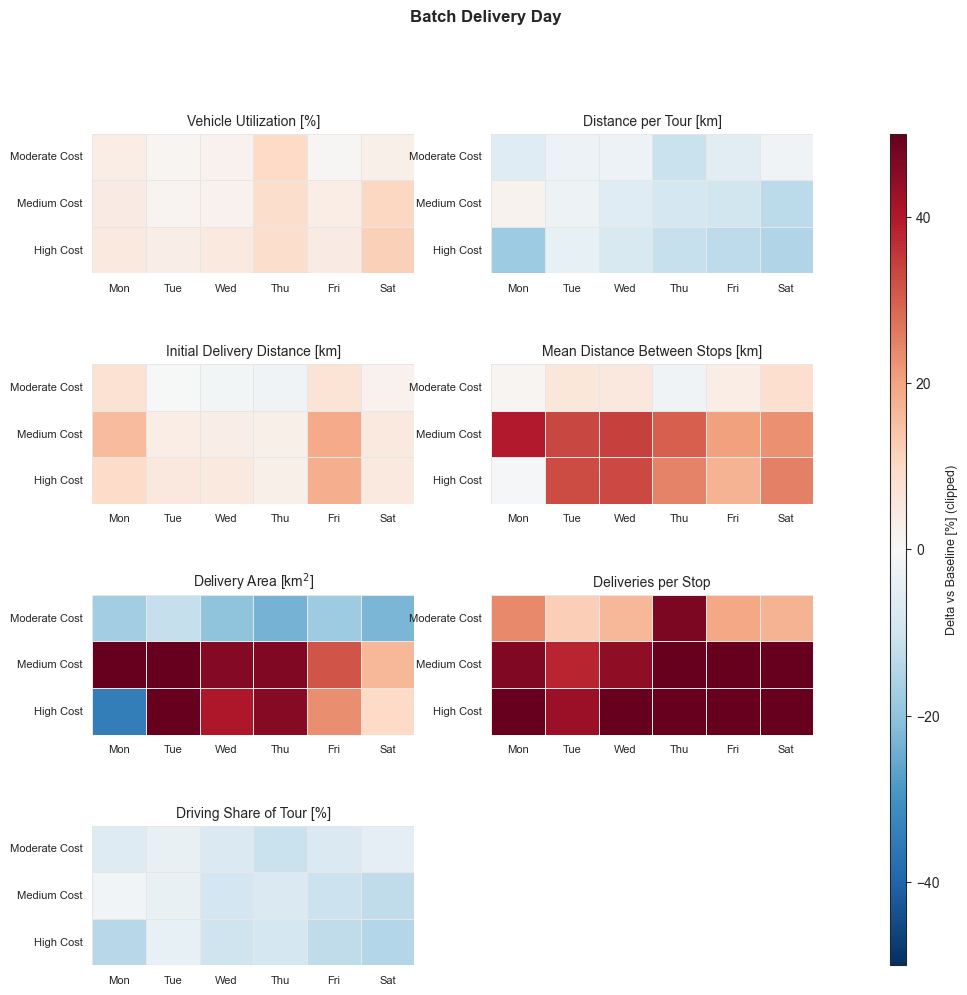

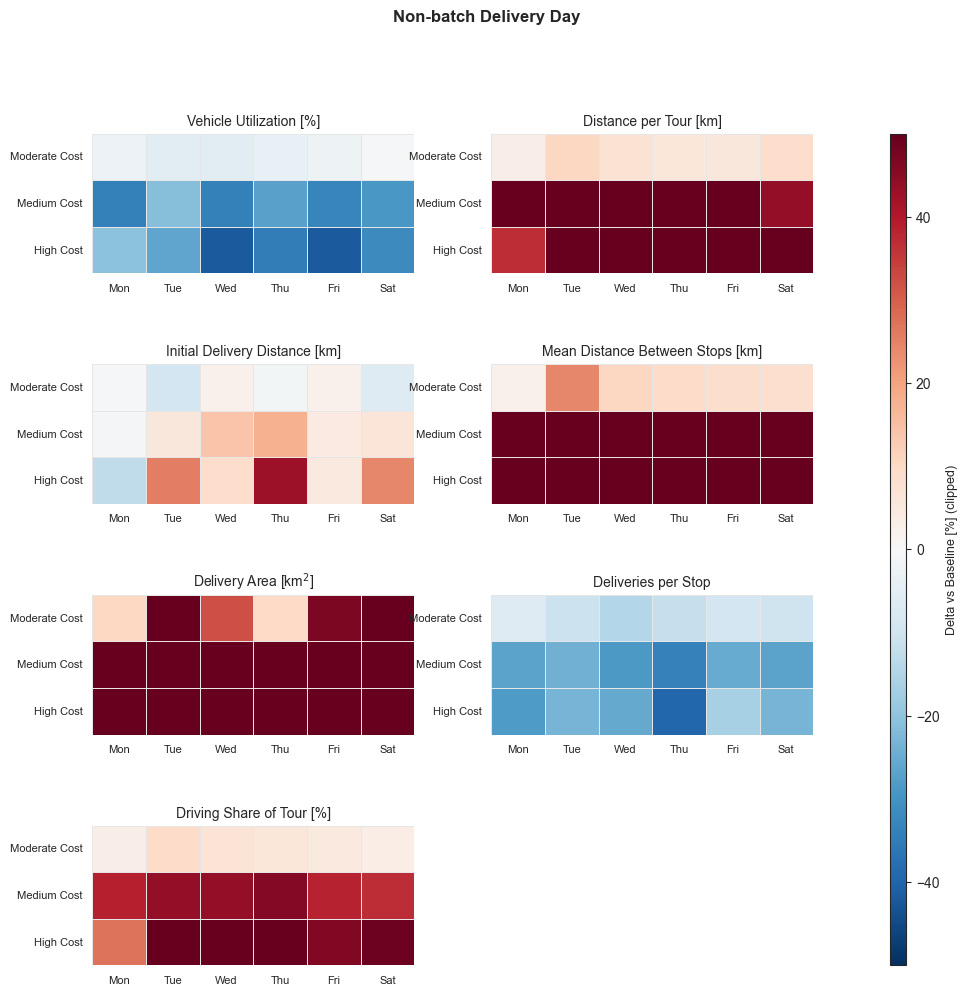

In [63]:
# Alternative Plot (übersichtlicher): Heatmaps der %-Deltas
# - pro activity_group eine Figure
# - pro KPI ein Heatmap-Panel: rows=scenario, cols=weekday, color=delta vs baseline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Welche Szenarien sollen gezeigt werden? (Baseline i.d.R. ausblenden)
scenarios_hm = [s for s in scenarios_plot if s in pct_tbl["scenario"].astype(str).unique()]
if not scenarios_hm:
    # Fallback: alles außer baseline
    scenarios_hm = [s for s in sorted(pct_tbl["scenario"].astype(str).unique()) if str(s).lower() != str(BASELINE).lower()]

# Weekday order aus dem Plot-Setup nehmen, aber auf tatsächlich vorhandene Werte beschränken
present_wd = pct_tbl["weekday"].astype(str).unique().tolist()
weekday_hm = [wd for wd in weekday_order if wd in present_wd] or sorted(present_wd)
wd_label_map = dict(zip(weekday_order, weekday_labels))

# Color scale: symmetrisch um 0; cap zum besseren Lesen
CAP = 50.0  # %

sns.set_style("white")

def _heatmap_panel(ax, data, title):
    # data: DataFrame (scenario x weekday)
    # clamp to [-CAP, CAP] for readability
    plot_data = data.copy().astype(float)
    plot_data = plot_data.clip(lower=-CAP, upper=CAP)

    sns.heatmap(
        plot_data,
        ax=ax,
        cmap="RdBu_r",
        center=0.0,
        vmin=-CAP,
        vmax=CAP,
        linewidths=0.5,
        linecolor="0.9",
        cbar=False,
        annot=False,
    )
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")

# Build figures
for g in pct_tbl["activity_group"].astype(str).unique().tolist():
    df_g = pct_tbl[pct_tbl["activity_group"].astype(str) == str(g)].copy()

    # nur gewünschte Szenarien
    df_g = df_g[df_g["scenario"].astype(str).isin([str(s) for s in scenarios_hm])]

    if df_g.empty:
        print(f"[WARN] No data for activity_group={g}")
        continue

    kpis_present = [k for k in kpis if k in df_g.columns]
    if not kpis_present:
        print(f"[WARN] No KPI columns found for activity_group={g}")
        continue

    n_k = len(kpis_present)
    ncols = 2 if n_k > 1 else 1
    nrows = int(np.ceil(n_k / ncols))

    # Use GridSpec with an extra column for a shared colorbar (avoids tight_layout warnings)
    import matplotlib as mpl

    fig = plt.figure(figsize=(10.5, 2.7 * nrows))
    gs = fig.add_gridspec(
        nrows=nrows,
        ncols=ncols + 1,
        width_ratios=[1] * ncols + [0.05],
        wspace=0.35,
        hspace=0.65,
    )

    axes = []
    for r in range(nrows):
        for c in range(ncols):
            axes.append(fig.add_subplot(gs[r, c]))

    cax = fig.add_subplot(gs[:, -1])

    for i, k in enumerate(kpis_present):
        ax = axes[i]

        mat = (
            df_g.pivot_table(
                index="scenario",
                columns="weekday",
                values=k,
                aggfunc="mean",
                dropna=False,
            )
            .reindex(index=[str(s) for s in scenarios_hm])
            .reindex(columns=weekday_hm)
        )

        _heatmap_panel(ax, mat, title=kpi_display(k))

        ax.set_yticklabels([scenario_display.get(s, s) for s in mat.index], rotation=0, fontsize=8)
        ax.set_xticklabels([wd_label_map.get(wd, str(wd)[:3]) for wd in mat.columns], rotation=0, fontsize=8)

    # unused axes off
    for j in range(n_k, len(axes)):
        axes[j].axis("off")

    # Shared colorbar
    norm = mpl.colors.TwoSlopeNorm(vmin=-CAP, vcenter=0.0, vmax=CAP)
    sm = mpl.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
    sm.set_array([])
    cb = fig.colorbar(sm, cax=cax)
    cb.set_label("Delta vs Baseline [%] (clipped)", fontsize=9)

    fig.suptitle(str(g), y=0.995, fontsize=12, fontweight="bold")
    plt.show()

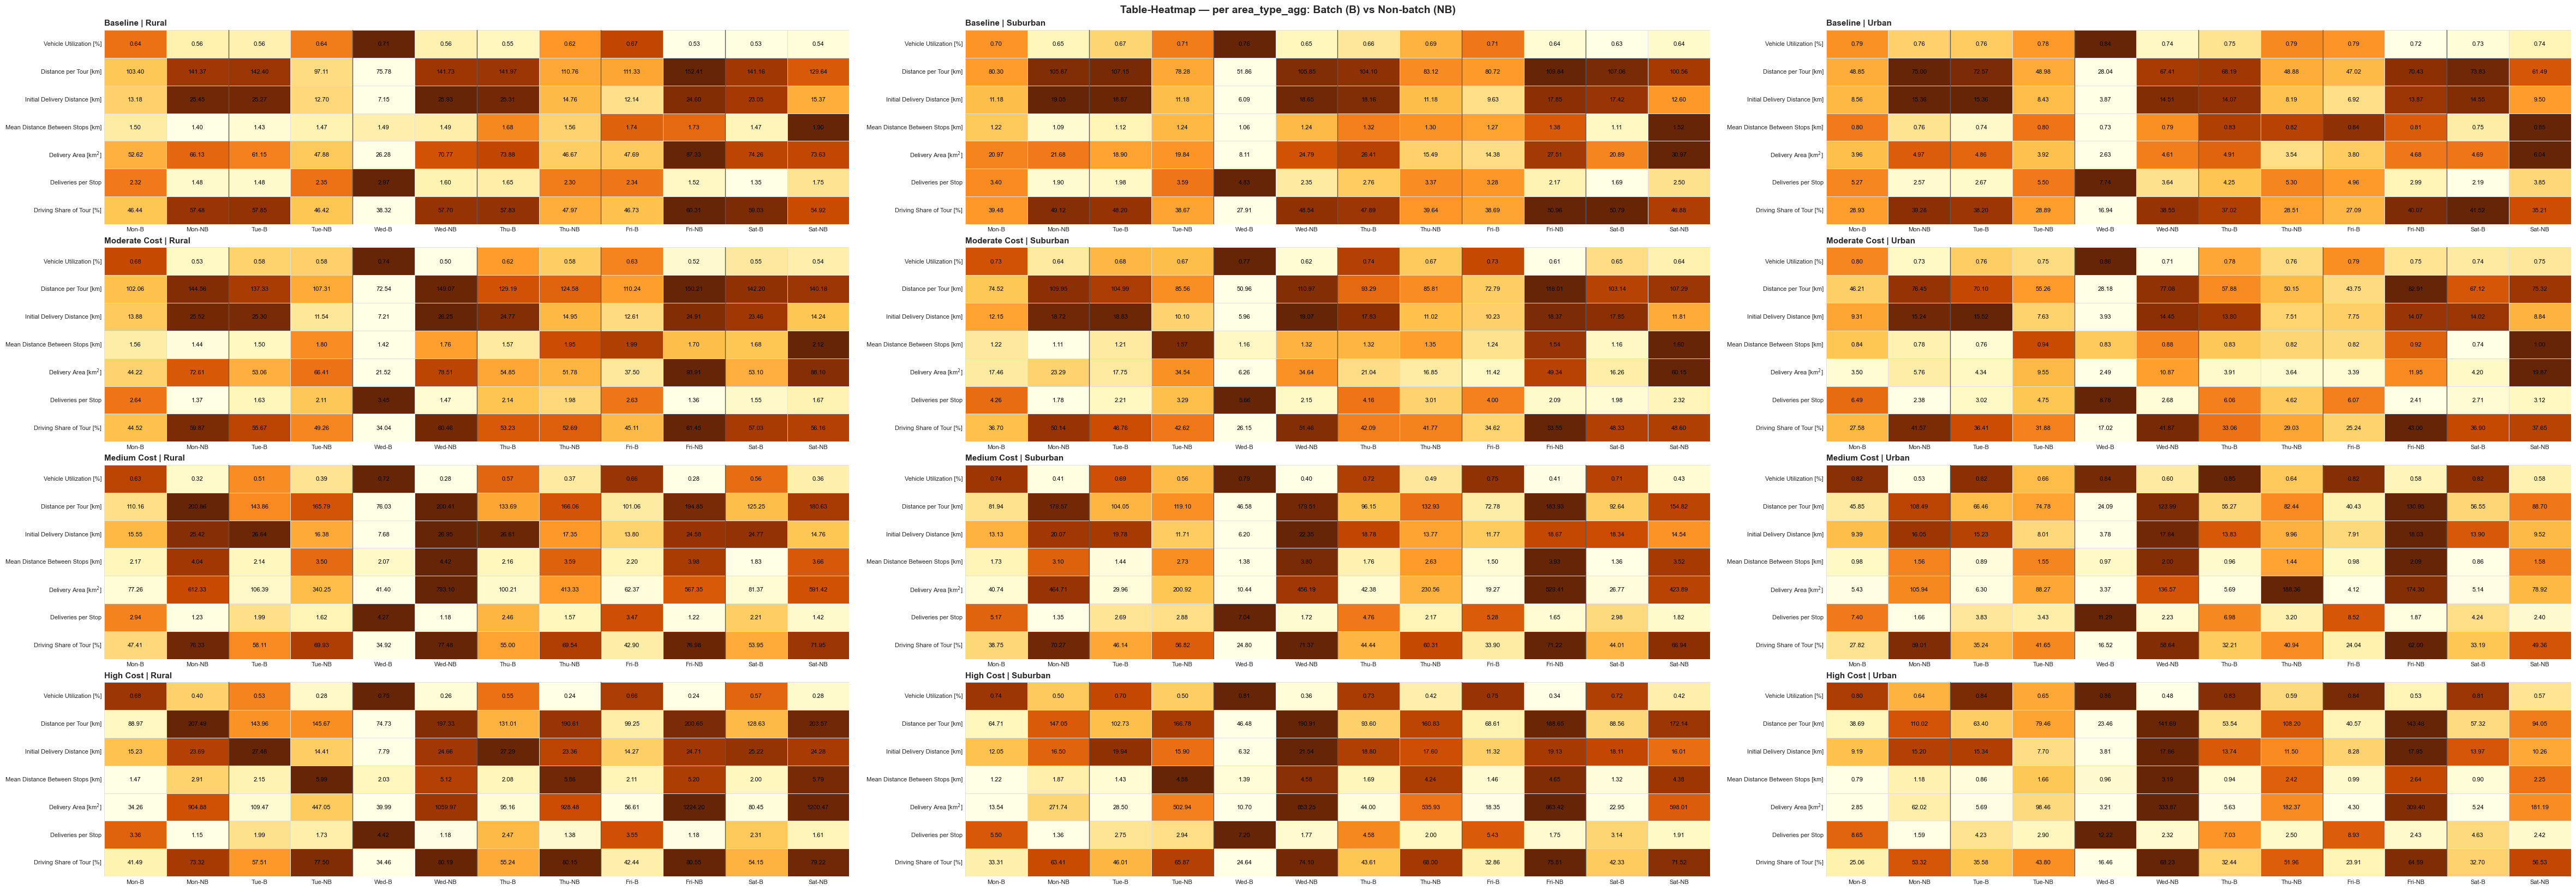

,scenario,area_type_agg,kpi,Mon-B,Mon-NB,Tue-B,Tue-NB,Wed-B,Wed-NB,Thu-B,Thu-NB,Fri-B,Fri-NB,Sat-B,Sat-NB
0,Baseline,Rural,Vehicle Utilization [%],0.642181,0.561288,0.560285,0.636048,0.708833,0.560146,0.553280,0.622217,0.669922,0.532120,0.534349,0.538855
1,Baseline,Rural,Distance per Tour [km],103.401298,141.366266,142.403959,97.114044,75.780939,141.727405,141.966105,110.763542,111.325503,152.405030,141.155891,129.637272
2,Baseline,Rural,Initial Delivery Distance [km],13.181232,25.446029,25.273817,12.700375,7.153497,25.933696,25.308524,14.761754,12.135657,24.602803,23.053480,15.374442
3,Baseline,Rural,Mean Distance Between Stops [km],1.495978,1.398528,1.429750,1.474678,1.485929,1.490485,1.676699,1.556206,1.739991,1.726579,1.468645,1.902893
4,Baseline,Rural,Delivery Area [km$^2$],52.616931,66.131092,61.147802,47.882252,26.280897,70.773594,73.879239,46.672757,47.685410,87.325670,74.261989,73.627340
5,Baseline,Rural,Deliveries per Stop,2.320222,1.480931,1.480350,2.354991,2.974998,1.599078,1.647874,2.304775,2.337556,1.515657,1.348739,1.751532
6,Baseline,Rural,Driving Share of Tour [%],46.436133,57.477442,57.846789,46.423133,38.324244,57.698927,57.830980,47.966209,46.729680,60.306025,59.034921,54.920544
7,Baseline,Suburban,Vehicle Utilization [%],0.698562,0.649852,0.672095,0.708082,0.761403,0.648497,0.661239,0.687414,0.710111,0.639695,0.632304,0.642951
8,Baseline,Suburban,Distance per Tour [km],80.297691,105.865864,107.153735,78.281730,51.855868,105.847102,104.096157,83.117506,80.716039,109.835618,107.058133,100.562208
9,Baseline,Suburban,Initial Delivery Distance [km],11.178527,19.048823,18.871636,11.178061,6.093901,18.645029,18.160915,11.184346,9.634728,17.849178,17.422327,12.604241


Exported combined table to table_heatmap_area_type_agg.csv with shape (84, 15).


In [64]:
# Table-Heatmap per area_type_agg (Batch vs Non-batch per day) for all scenarios in SCENARIOS_TABLE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Settings
# -----------------------------
PROVIDER_TABLE = "__ALL__"  # "__ALL__" or e.g. "dhl"/"dpd"/"hermes"
SCENARIOS_TABLE = None       # None -> [BASELINE] + scenarios_plot else all present
AG_BATCH_LOCAL = AG_BATCH if "AG_BATCH" in globals() else "Batch Delivery Day"
AG_NONB_LOCAL  = AG_NONBATCH if "AG_NONBATCH" in globals() else "Non-batch Delivery Day"
AREA_COL = "area_type_agg"

if "df" not in globals():
    raise RuntimeError("df not found. Run the preprocessing cells first.")
if "kpis" not in globals() or not kpis:
    raise RuntimeError("kpis list not found/empty.")
if AREA_COL not in df.columns:
    raise RuntimeError(f"Column '{AREA_COL}' not in df.")

d = df.copy()
if "provider" in d.columns:
    d["provider"] = d["provider"].astype(str).str.strip().str.lower()
    if PROVIDER_TABLE != "__ALL__":
        d = d[d["provider"] == str(PROVIDER_TABLE).strip().lower()]
        if d.empty:
            raise RuntimeError(f"No rows for PROVIDER_TABLE={PROVIDER_TABLE!r}.")

# Use stable weekday/scenario ordering if available
wd_order = weekday_order if "weekday_order" in globals() else sorted(d["weekday"].astype(str).unique().tolist())
wd_labels = weekday_labels if "weekday_labels" in globals() else [str(w)[:3] for w in wd_order]
wd_label_map = dict(zip(wd_order, wd_labels))

# Scenarios list
present_scens = d["scenario"].astype(str).unique().tolist()
if SCENARIOS_TABLE is None:
    if "BASELINE" in globals() and "scenarios_plot" in globals():
        SCENARIOS_TABLE = [str(BASELINE)] + [str(s) for s in scenarios_plot if str(s) in present_scens]
        rest = [s for s in present_scens if s not in SCENARIOS_TABLE]
        SCENARIOS_TABLE = SCENARIOS_TABLE + sorted(rest)
    elif "BASELINE" in globals():
        SCENARIOS_TABLE = [str(BASELINE)] + sorted([s for s in present_scens if s != str(BASELINE)])
    else:
        SCENARIOS_TABLE = sorted(present_scens)
else:
    SCENARIOS_TABLE = [str(s) for s in SCENARIOS_TABLE if str(s) in present_scens] or sorted(present_scens)

# Aggregate: mean per run -> mean across runs
kpis_present = [k for k in kpis if k in d.columns]
for c in kpis_present:
    d[c] = pd.to_numeric(d[c], errors="coerce")

grp = ["activity_group", "weekday", "scenario", AREA_COL]
if "run_name" in d.columns:
    per_run = d.groupby(grp + ["run_name"], dropna=False, observed=False)[kpis_present].mean().reset_index()
    scen_avg_abs = per_run.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()
else:
    scen_avg_abs = d.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()

# limit to weekdays that exist in data
present_wd = scen_avg_abs["weekday"].astype(str).unique().tolist()
wd_order = [w for w in wd_order if str(w) in present_wd] or sorted(present_wd)
wd_labels = [wd_label_map.get(w, str(w)[:3]) for w in wd_order]

ag_order = [AG_BATCH_LOCAL, AG_NONB_LOCAL]
ag_short = {AG_BATCH_LOCAL: "B", AG_NONB_LOCAL: "NB"}

areas = scen_avg_abs[AREA_COL].dropna().astype(str).unique().tolist()
if not areas:
    raise RuntimeError("No area_type_agg values found.")

# Helper

def _sc_lab(x: str) -> str:
    if str(x).lower() == str(globals().get("BASELINE", "")).lower():
        return "Baseline"
    return scenario_display.get(str(x), str(x)) if "scenario_display" in globals() else str(x)

def _k_lab(x: str) -> str:
    return kpi_display(x) if "kpi_display" in globals() else str(x)

def _fmt_val(v: float) -> str:
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return ""
    try:
        return f"{float(v):.2f}"
    except Exception:
        return str(v)

def _rowwise_minmax_norm(mat: pd.DataFrame) -> pd.DataFrame:
    out = mat.copy().astype(float)
    for idx in out.index:
        row = out.loc[idx].to_numpy(dtype=float)
        finite = np.isfinite(row)
        if not finite.any():
            out.loc[idx] = 0.5
            continue
        rmin = np.nanmin(row[finite])
        rmax = np.nanmax(row[finite])
        if not np.isfinite(rmin) or not np.isfinite(rmax) or (rmax - rmin) < 1e-12:
            out.loc[idx] = 0.5
            continue
        out.loc[idx] = (out.loc[idx] - rmin) / (rmax - rmin)
    return out

def _build_table_for_scenario_area(scen: str, area: str):
    sub = scen_avg_abs[(scen_avg_abs["scenario"].astype(str) == str(scen)) & (scen_avg_abs[AREA_COL].astype(str) == str(area))].copy()
    col_keys = []
    col_labels = []
    for wd, wdl in zip(wd_order, wd_labels):
        for ag in ag_order:
            col_keys.append((wd, ag))
            col_labels.append(f"{wdl}-{ag_short.get(ag, ag)}")

    mat = pd.DataFrame(index=kpis_present, columns=col_labels, dtype=float)
    ann = pd.DataFrame(index=kpis_present, columns=col_labels, dtype=object)
    for k in kpis_present:
        for (wd, ag), col in zip(col_keys, col_labels):
            s = sub[(sub["weekday"].astype(str) == str(wd)) & (sub["activity_group"].astype(str) == str(ag))][k]
            v = float(s.mean()) if not s.empty else np.nan
            mat.loc[k, col] = v
            ann.loc[k, col] = _fmt_val(v)
    mat_norm = _rowwise_minmax_norm(mat)
    return mat, mat_norm, ann

sns.set_style("white")

# Figure: one row per scenario, columns = areas; each subplot is a heatmap
n_s = len(SCENARIOS_TABLE)
n_a = len(areas)
if n_s == 0:
    raise RuntimeError("No scenarios found for SCENARIOS_TABLE.")

# size heuristic
h_per = 0.40 * len(kpis_present) + 1.25
fig_h = max(3.2, n_s * h_per)
fig_w = max(12.0, n_a * (0.85 * (len(wd_order) * 2) + 5.5))
fig, axes = plt.subplots(n_s, n_a, figsize=(fig_w, fig_h), constrained_layout=True)
if n_s == 1 and n_a == 1:
    axes = np.array([[axes]])
elif n_s == 1:
    axes = axes.reshape(1, n_a)
elif n_a == 1:
    axes = axes.reshape(n_s, 1)

# Collect rows for CSV export (raw values, not normalized)
export_rows = []

for i, scen in enumerate(SCENARIOS_TABLE):
    for j, area in enumerate(areas):
        ax = axes[i, j]
        mat_abs, mat_norm, ann = _build_table_for_scenario_area(scen, area)
        sns.heatmap(
            mat_norm,
            ax=ax,
            cmap="YlOrBr",
            vmin=0.0,
            vmax=1.0,
            cbar=False,
            linewidths=0.6,
            linecolor="0.88",
            annot=ann.values,
            fmt="",
            annot_kws=dict(fontsize=8, color="black"),
        )
        ax.set_title(f"{_sc_lab(scen)} | {area}", loc="left", fontsize=11, fontweight="bold", pad=6)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_yticklabels([_k_lab(k) for k in mat_abs.index], rotation=0, fontsize=8)
        ax.set_xticklabels(mat_abs.columns.tolist(), rotation=0, fontsize=8)
        ax.tick_params(axis="both", length=0)
        for v in range(2, len(mat_abs.columns), 2):
            ax.axvline(v, color="0.35", linewidth=1.0)
        # Append rows for each KPI
        for k in mat_abs.index:
            row = {
                "scenario": _sc_lab(scen),
                AREA_COL: area,
                "kpi": _k_lab(k),
            }
            for col in mat_abs.columns:
                row[col] = mat_abs.loc[k, col]
            export_rows.append(row)

sup_title = "Table-Heatmap — per area_type_agg: Batch (B) vs Non-batch (NB)"
fig.suptitle(sup_title, fontsize=14, fontweight="bold")
plt.show()

# Export combined table (wide format) for easy CSV use
export_df = pd.DataFrame(export_rows)
csv_path = "table_heatmap_area_type_agg.csv"
export_df.to_csv(csv_path, index=False)
display(export_df.head(10))
print(f"Exported combined table to {csv_path} with shape {export_df.shape}.")

## Table-Heatmap wie Screenshot (pro Tag: Batch vs Non-batch)
Wie im Screenshot: pro Szenario ein Block, **Zahlen in den Zellen**, Farbe als „Heat“ – aber jede Woche ist **pro Tag in 2 Spalten** aufgeteilt (**B** / **NB**).
Hinweis: Die Farbe ist **pro KPI-Zeile normalisiert** (min–max über alle Spalten), damit die Schattierung pro KPI sinnvoll bleibt, auch wenn KPIs unterschiedliche Skalen haben.

In [65]:
df

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name,Cost per Parcel [€/parcel],weekday,scenario,active_flag,activity_group
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,NaN,NaN,NaN,NaN,NaN,2.656254,Monday,basecase,True,Batch Delivery Day
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,NaN,NaN,NaN,NaN,NaN,4.139754,Monday,basecase,True,Batch Delivery Day
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,NaN,NaN,NaN,NaN,NaN,3.246762,Monday,basecase,True,Batch Delivery Day
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,NaN,NaN,NaN,NaN,NaN,2.695286,Monday,basecase,True,Batch Delivery Day
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,NaN,NaN,NaN,NaN,NaN,3.574697,Monday,basecase,True,Batch Delivery Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39470,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,1.656389,1873.0,1.136111,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,NaN,NaN,NaN,NaN,NaN,12.620688,Saturday,batchmoderate,True,Batch Delivery Day
39471,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,3.971111,3630.0,2.962778,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,NaN,NaN,NaN,NaN,NaN,6.881250,Saturday,batchmoderate,True,Batch Delivery Day
39472,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,2.570556,4035.0,1.449722,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,NaN,NaN,NaN,NaN,NaN,5.886592,Saturday,batchmoderate,True,Batch Delivery Day
39473,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,1.373611,1848.0,0.860278,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,NaN,NaN,NaN,NaN,NaN,13.183782,Saturday,batchmoderate,True,Batch Delivery Day


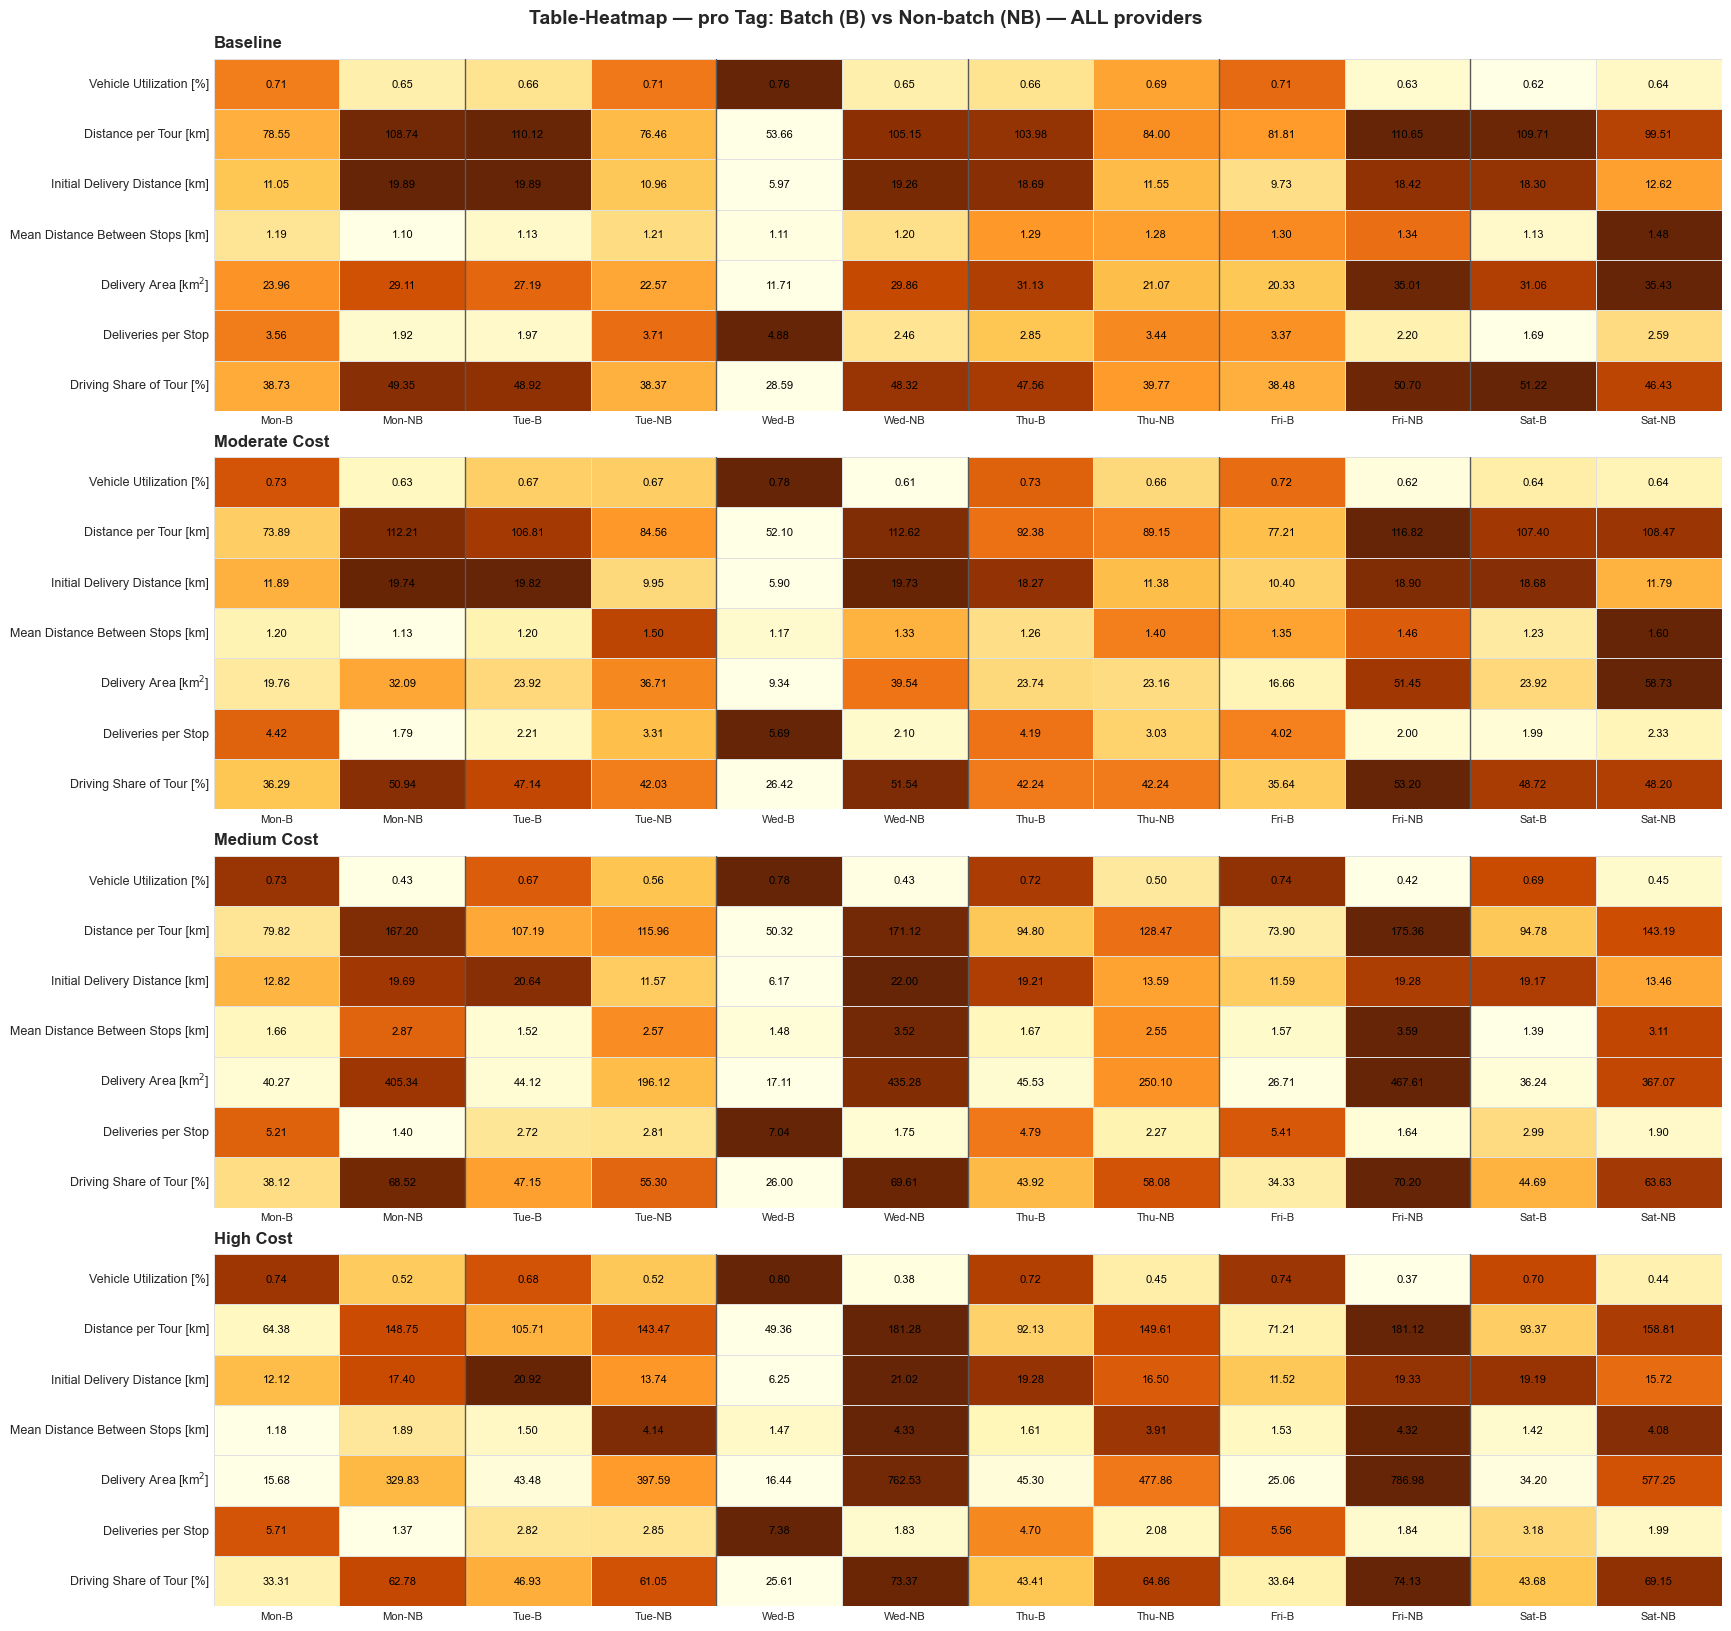

In [66]:
# Table-Heatmap wie Screenshot (pro Tag: Batch vs Non-batch)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Settings
# -----------------------------
PROVIDER_TABLE = "__ALL__"  # "__ALL__" oder z.B. "dhl"/"dpd"/"hermes" (case-insensitive)
SCENARIOS_TABLE = None       # None -> [BASELINE] + scenarios_plot (falls vorhanden) sonst alle
AG_BATCH_LOCAL = AG_BATCH if "AG_BATCH" in globals() else "Batch Delivery Day"
AG_NONB_LOCAL  = AG_NONBATCH if "AG_NONBATCH" in globals() else "Non-batch Delivery Day"

if "df" not in globals():
    raise RuntimeError("df not found. Run the preprocessing cells first.")
if "kpis" not in globals() or not kpis:
    raise RuntimeError("kpis list not found/empty.")

d = df.copy()
if "provider" in d.columns:
    d["provider"] = d["provider"].astype(str).str.strip().str.lower()
    if PROVIDER_TABLE != "__ALL__":
        d = d[d["provider"] == str(PROVIDER_TABLE).strip().lower()]
        if d.empty:
            raise RuntimeError(f"No rows for PROVIDER_TABLE={PROVIDER_TABLE!r}.")

# Use stable weekday/scenario ordering if available
wd_order = weekday_order if "weekday_order" in globals() else sorted(d["weekday"].astype(str).unique().tolist())
wd_labels = weekday_labels if "weekday_labels" in globals() else [str(w)[:3] for w in wd_order]
wd_label_map = dict(zip(wd_order, wd_labels))

# Scenarios list
present_scens = d["scenario"].astype(str).unique().tolist()
if SCENARIOS_TABLE is None:
    if "BASELINE" in globals() and "scenarios_plot" in globals():
        SCENARIOS_TABLE = [str(BASELINE)] + [str(s) for s in scenarios_plot if str(s) in present_scens]
        # keep any leftover scenarios at the end (optional)
        rest = [s for s in present_scens if s not in SCENARIOS_TABLE]
        SCENARIOS_TABLE = SCENARIOS_TABLE + sorted(rest)
    elif "BASELINE" in globals():
        SCENARIOS_TABLE = [str(BASELINE)] + sorted([s for s in present_scens if s != str(BASELINE)])
    else:
        SCENARIOS_TABLE = sorted(present_scens)
else:
    SCENARIOS_TABLE = [str(s) for s in SCENARIOS_TABLE if str(s) in present_scens] or sorted(present_scens)

# Aggregate: mean per run -> mean across runs (to avoid run-count weighting)
kpis_present = [k for k in kpis if k in d.columns]
for c in kpis_present:
    d[c] = pd.to_numeric(d[c], errors="coerce")

grp = ["activity_group", "weekday", "scenario"]
if "run_name" in d.columns:
    per_run = d.groupby(grp + ["run_name"], dropna=False, observed=False)[kpis_present].mean().reset_index()
    scen_avg_abs = per_run.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()
else:
    scen_avg_abs = d.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()

# limit to weekdays that exist in data
present_wd = scen_avg_abs["weekday"].astype(str).unique().tolist()
wd_order = [w for w in wd_order if str(w) in present_wd] or sorted(present_wd)
wd_labels = [wd_label_map.get(w, str(w)[:3]) for w in wd_order]

ag_order = [AG_BATCH_LOCAL, AG_NONB_LOCAL]
ag_short = {AG_BATCH_LOCAL: "B", AG_NONB_LOCAL: "NB"}

def _sc_lab(x: str) -> str:
    if str(x).lower() == str(globals().get("BASELINE", "")).lower():
        return "Baseline"
    return scenario_display.get(str(x), str(x)) if "scenario_display" in globals() else str(x)

def _k_lab(x: str) -> str:
    return kpi_display(x) if "kpi_display" in globals() else str(x)

def _fmt_val(v: float) -> str:
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return ""
    try:
        return f"{float(v):.2f}"
    except Exception:
        return str(v)

def _rowwise_minmax_norm(mat: pd.DataFrame) -> pd.DataFrame:
    out = mat.copy().astype(float)
    for idx in out.index:
        row = out.loc[idx].to_numpy(dtype=float)
        finite = np.isfinite(row)
        if not finite.any():
            out.loc[idx] = 0.5
            continue
        rmin = np.nanmin(row[finite])
        rmax = np.nanmax(row[finite])
        if not np.isfinite(rmin) or not np.isfinite(rmax) or (rmax - rmin) < 1e-12:
            out.loc[idx] = 0.5
            continue
        out.loc[idx] = (out.loc[idx] - rmin) / (rmax - rmin)
    return out

def _build_table_for_scenario(scen: str):
    sub = scen_avg_abs[scen_avg_abs["scenario"].astype(str) == str(scen)].copy()
    # columns: (weekday, activity_group) flattened into labels like "Mon-B" / "Mon-NB"
    col_keys = []
    col_labels = []
    for wd, wdl in zip(wd_order, wd_labels):
        for ag in ag_order:
            col_keys.append((wd, ag))
            col_labels.append(f"{wdl}-{ag_short.get(ag, ag)}")

    mat = pd.DataFrame(index=kpis_present, columns=col_labels, dtype=float)
    ann = pd.DataFrame(index=kpis_present, columns=col_labels, dtype=object)
    for k in kpis_present:
        for (wd, ag), col in zip(col_keys, col_labels):
            s = sub[(sub["weekday"].astype(str) == str(wd)) & (sub["activity_group"].astype(str) == str(ag))][k]
            v = float(s.mean()) if not s.empty else np.nan
            mat.loc[k, col] = v
            ann.loc[k, col] = _fmt_val(v)
    # row-wise normalization only for coloring
    mat_norm = _rowwise_minmax_norm(mat)
    return mat, mat_norm, ann

sns.set_style("white")
n_s = len(SCENARIOS_TABLE)
if n_s == 0:
    raise RuntimeError("No scenarios found for SCENARIOS_TABLE.")

# dynamic figure height (compact but readable)
h_per = 0.40 * len(kpis_present) + 1.25
fig_h = max(3.2, n_s * h_per)
fig_w = max(11.5, 0.85 * (len(wd_order) * 2) + 7.0)
fig, axes = plt.subplots(n_s, 1, figsize=(fig_w, fig_h), constrained_layout=True)
if n_s == 1:
    axes = [axes]

for ax, scen in zip(axes, SCENARIOS_TABLE):
    mat_abs, mat_norm, ann = _build_table_for_scenario(scen)
    sns.heatmap(
        mat_norm,
        ax=ax,
        cmap="YlOrBr",
        vmin=0.0,
        vmax=1.0,
        cbar=False,
        linewidths=0.6,
        linecolor="0.88",
        annot=ann.values,
        fmt="",
        annot_kws=dict(fontsize=8, color="black"),
    )
    ax.set_title(_sc_lab(scen), loc="left", fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels([_k_lab(k) for k in mat_abs.index], rotation=0, fontsize=9)
    ax.set_xticklabels(mat_abs.columns.tolist(), rotation=0, fontsize=8)
    ax.tick_params(axis="both", length=0)
    # vertical separators between weekdays (after each B/NB pair)
    for v in range(2, len(mat_abs.columns), 2):
        ax.axvline(v, color="0.35", linewidth=1.0)

title_provider = "ALL providers" if PROVIDER_TABLE == "__ALL__" else f"provider={str(PROVIDER_TABLE).strip().lower()}"
fig.suptitle(f"Table-Heatmap — pro Tag: Batch (B) vs Non-batch (NB) — {title_provider}", fontsize=14, fontweight="bold")
plt.show()

## Table-Heatmap V2 (übersichtlicher): pro Szenario zwei Blöcke (Batch | Non-batch)
Gleiche Idee wie Screenshot, aber statt doppelter Spalten pro Tag:
- links **Batch** (Mon…Sat), rechts **Non-batch** (Mon…Sat)
- gleiche KPI-Zeilen, gleiche Zahlen-Annotationen
- Farbe ist pro KPI-Zeile über **beide Blöcke zusammen** normalisiert (damit Batch vs Non-batch vergleichbar bleibt).

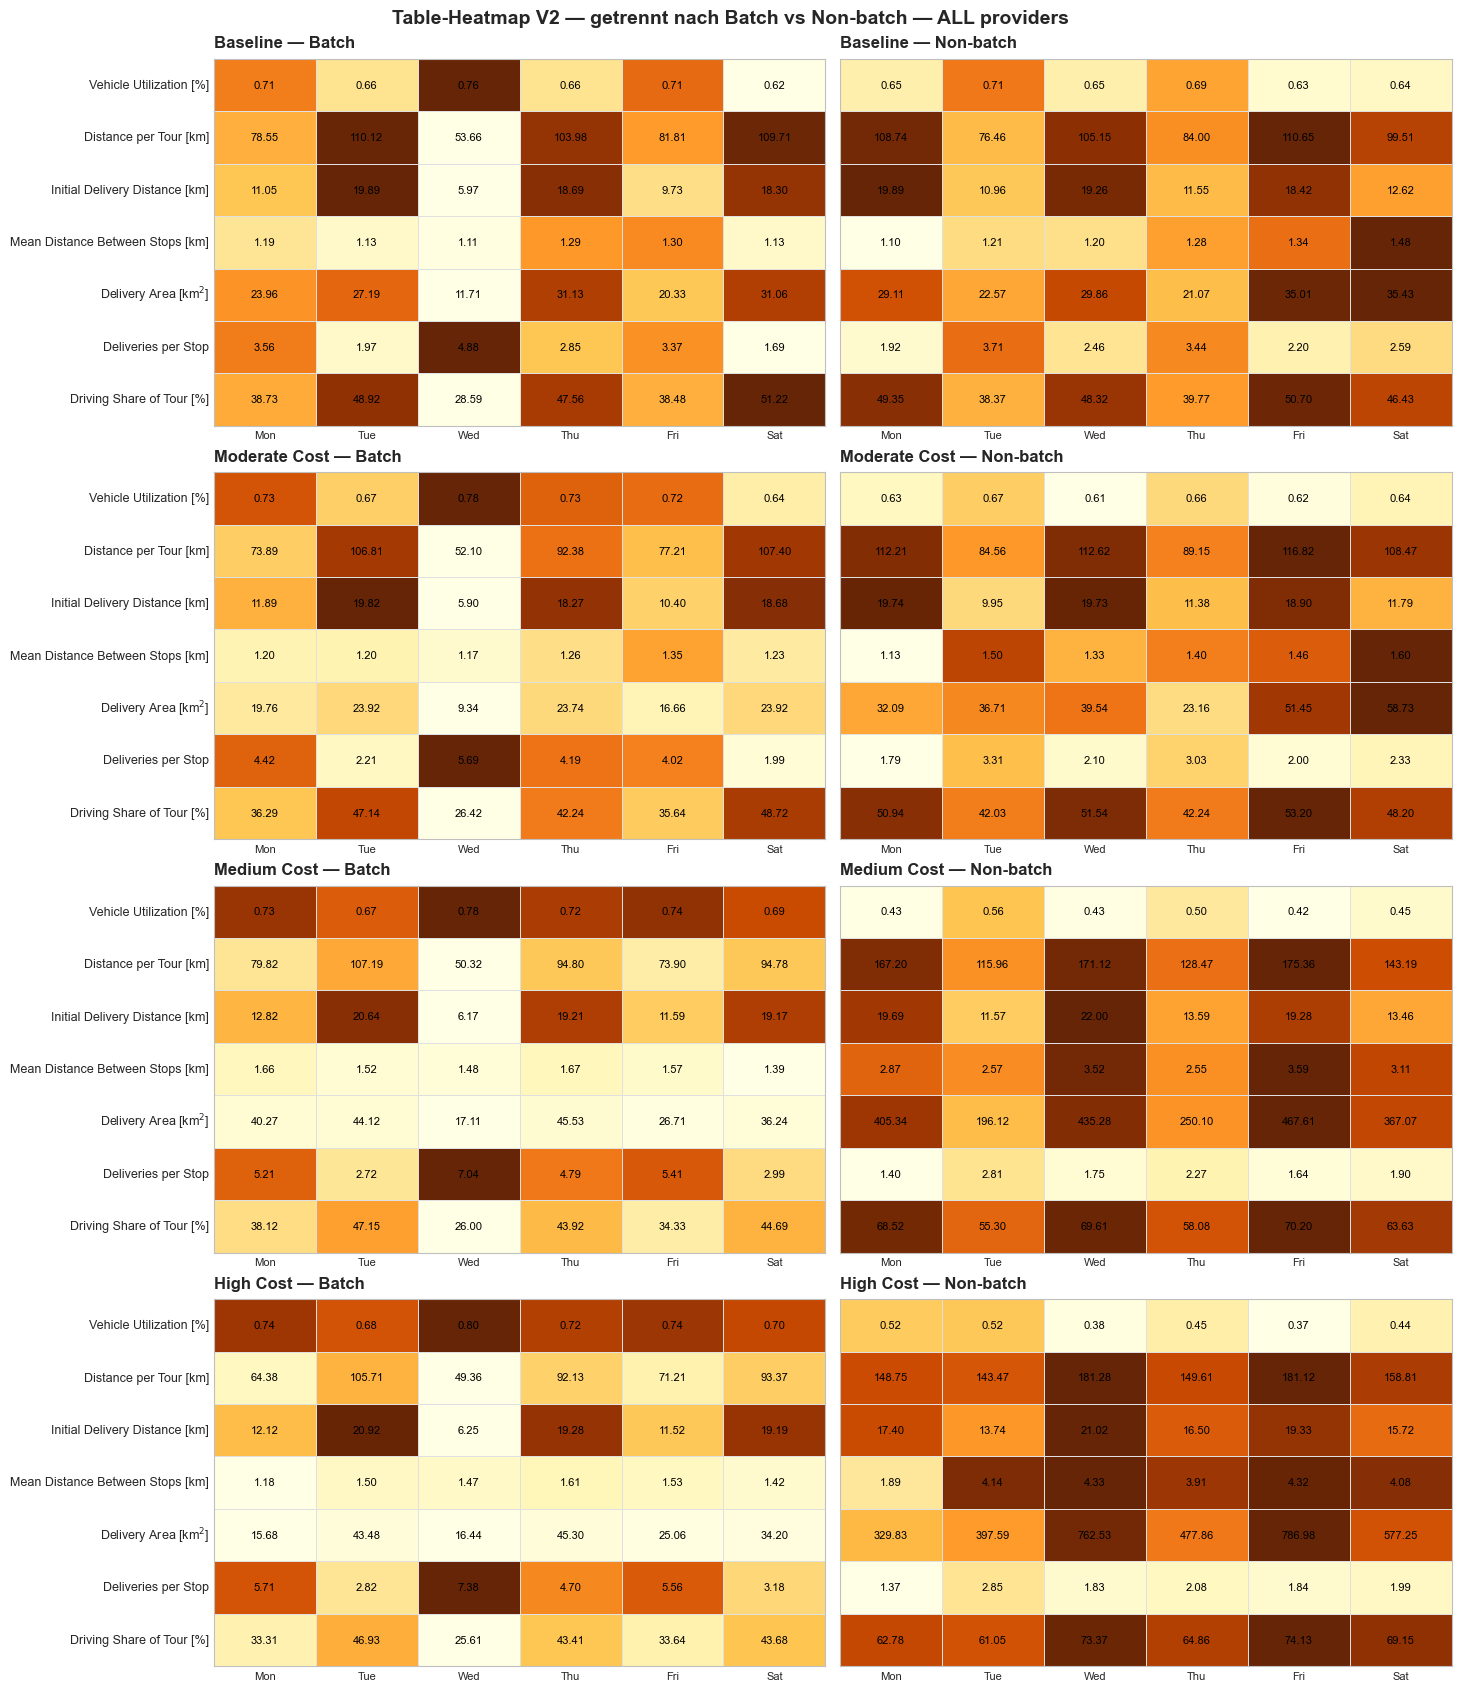

In [67]:
# Table-Heatmap V2 (übersichtlicher): pro Szenario zwei Blöcke (Batch | Non-batch)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Settings
# -----------------------------
PROVIDER_TABLE_V2 = PROVIDER_TABLE if "PROVIDER_TABLE" in globals() else "__ALL__"  # reuse if defined
SCENARIOS_TABLE_V2 = SCENARIOS_TABLE if "SCENARIOS_TABLE" in globals() else None
AG_BATCH_LOCAL = AG_BATCH if "AG_BATCH" in globals() else "Batch Delivery Day"
AG_NONB_LOCAL  = AG_NONBATCH if "AG_NONBATCH" in globals() else "Non-batch Delivery Day"

if "df" not in globals():
    raise RuntimeError("df not found. Run the preprocessing cells first.")
if "kpis" not in globals() or not kpis:
    raise RuntimeError("kpis list not found/empty.")

d2 = df.copy()
if "provider" in d2.columns:
    d2["provider"] = d2["provider"].astype(str).str.strip().str.lower()
    if PROVIDER_TABLE_V2 != "__ALL__":
        d2 = d2[d2["provider"] == str(PROVIDER_TABLE_V2).strip().lower()]
        if d2.empty:
            raise RuntimeError(f"No rows for PROVIDER_TABLE_V2={PROVIDER_TABLE_V2!r}.")

kpis_present = [k for k in kpis if k in d2.columns]
for c in kpis_present:
    d2[c] = pd.to_numeric(d2[c], errors="coerce")

wd_order = weekday_order if "weekday_order" in globals() else sorted(d2["weekday"].astype(str).unique().tolist())
wd_labels = weekday_labels if "weekday_labels" in globals() else [str(w)[:3] for w in wd_order]
wd_label_map = dict(zip(wd_order, wd_labels))

# Aggregate: mean per run -> mean across runs
grp = ["activity_group", "weekday", "scenario"]
if "run_name" in d2.columns:
    per_run2 = d2.groupby(grp + ["run_name"], dropna=False, observed=False)[kpis_present].mean().reset_index()
    scen_avg_abs2 = per_run2.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()
else:
    scen_avg_abs2 = d2.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()

present_wd2 = scen_avg_abs2["weekday"].astype(str).unique().tolist()
wd_order2 = [w for w in wd_order if str(w) in present_wd2] or sorted(present_wd2)
wd_labels2 = [wd_label_map.get(w, str(w)[:3]) for w in wd_order2]

present_scens2 = scen_avg_abs2["scenario"].astype(str).unique().tolist()
if SCENARIOS_TABLE_V2 is None:
    if "BASELINE" in globals() and "scenarios_plot" in globals():
        SCENARIOS_TABLE_V2 = [str(BASELINE)] + [str(s) for s in scenarios_plot if str(s) in present_scens2]
        rest2 = [s for s in present_scens2 if s not in SCENARIOS_TABLE_V2]
        SCENARIOS_TABLE_V2 = SCENARIOS_TABLE_V2 + sorted(rest2)
    elif "BASELINE" in globals():
        SCENARIOS_TABLE_V2 = [str(BASELINE)] + sorted([s for s in present_scens2 if s != str(BASELINE)])
    else:
        SCENARIOS_TABLE_V2 = sorted(present_scens2)
else:
    SCENARIOS_TABLE_V2 = [str(s) for s in SCENARIOS_TABLE_V2 if str(s) in present_scens2] or sorted(present_scens2)

def _sc_lab(x: str) -> str:
    if "BASELINE" in globals() and str(x).lower() == str(BASELINE).lower():
        return "Baseline"
    return scenario_display.get(str(x), str(x)) if "scenario_display" in globals() else str(x)

def _k_lab(x: str) -> str:
    return kpi_display(x) if "kpi_display" in globals() else str(x)

def _fmt_val(v: float) -> str:
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return ""
    return f"{float(v):.2f}"

def _rowwise_minmax_norm_pair(mat_left: pd.DataFrame, mat_right: pd.DataFrame):
    # Normalize per KPI-row over both mats together (so Batch vs Non-batch comparable)
    A = mat_left.copy().astype(float)
    B = mat_right.copy().astype(float)
    outA = A.copy()
    outB = B.copy()
    for idx in A.index:
        row = np.r_[A.loc[idx].to_numpy(dtype=float), B.loc[idx].to_numpy(dtype=float)]
        finite = np.isfinite(row)
        if not finite.any():
            outA.loc[idx] = 0.5
            outB.loc[idx] = 0.5
            continue
        rmin = np.nanmin(row[finite])
        rmax = np.nanmax(row[finite])
        if not np.isfinite(rmin) or not np.isfinite(rmax) or (rmax - rmin) < 1e-12:
            outA.loc[idx] = 0.5
            outB.loc[idx] = 0.5
            continue
        outA.loc[idx] = (A.loc[idx] - rmin) / (rmax - rmin)
        outB.loc[idx] = (B.loc[idx] - rmin) / (rmax - rmin)
    return outA, outB

def _build_mats_for_scenario(scen: str):
    sub = scen_avg_abs2[scen_avg_abs2["scenario"].astype(str) == str(scen)].copy()
    def _mat_for_ag(ag: str):
        mat = pd.DataFrame(index=kpis_present, columns=wd_order2, dtype=float)
        ann = pd.DataFrame(index=kpis_present, columns=wd_order2, dtype=object)
        sub_ag = sub[sub["activity_group"].astype(str) == str(ag)]
        for k in kpis_present:
            for wd in wd_order2:
                s = sub_ag[sub_ag["weekday"].astype(str) == str(wd)][k]
                v = float(s.mean()) if not s.empty else np.nan
                mat.loc[k, wd] = v
                ann.loc[k, wd] = _fmt_val(v)
        return mat, ann
    matB, annB = _mat_for_ag(AG_BATCH_LOCAL)
    matN, annN = _mat_for_ag(AG_NONB_LOCAL)
    normB, normN = _rowwise_minmax_norm_pair(matB, matN)
    return (matB, annB, normB), (matN, annN, normN)

sns.set_style("white")
n_s = len(SCENARIOS_TABLE_V2)
if n_s == 0:
    raise RuntimeError("No scenarios for SCENARIOS_TABLE_V2")

# Layout: n_s rows × (Batch, Non-batch) columns + optional colorbar not needed (rowwise norm 0..1)
fig_w = max(12.0, 0.75 * len(wd_order2) + 10.0)
fig_h = max(3.0, n_s * (0.40 * len(kpis_present) + 1.4))
fig, axes = plt.subplots(n_s, 2, figsize=(fig_w, fig_h), constrained_layout=True)
if n_s == 1:
    axes = np.array([axes])

for i, scen in enumerate(SCENARIOS_TABLE_V2):
    (matB, annB, normB), (matN, annN, normN) = _build_mats_for_scenario(scen)
    axL = axes[i, 0]
    axR = axes[i, 1]
    # Batch
    sns.heatmap(
        normB, ax=axL, cmap="YlOrBr", vmin=0, vmax=1, cbar=False,
        linewidths=0.6, linecolor="0.88",
        annot=annB.values, fmt="", annot_kws=dict(fontsize=8, color="black"),
    )
    axL.set_title(f"{_sc_lab(scen)} — Batch", loc="left", fontsize=12, fontweight="bold", pad=8)
    axL.set_xlabel("")
    axL.set_ylabel("")
    axL.set_yticklabels([_k_lab(k) for k in matB.index], rotation=0, fontsize=9)
    axL.set_xticklabels(wd_labels2, rotation=0, fontsize=8)
    axL.tick_params(axis="both", length=0)
    # Non-batch
    sns.heatmap(
        normN, ax=axR, cmap="YlOrBr", vmin=0, vmax=1, cbar=False,
        linewidths=0.6, linecolor="0.88",
        annot=annN.values, fmt="", annot_kws=dict(fontsize=8, color="black"),
    )
    axR.set_title(f"{_sc_lab(scen)} — Non-batch", loc="left", fontsize=12, fontweight="bold", pad=8)
    axR.set_xlabel("")
    axR.set_ylabel("")
    axR.set_yticklabels([])
    axR.set_xticklabels(wd_labels2, rotation=0, fontsize=8)
    axR.tick_params(axis="both", length=0)

# little separator feeling between the two blocks
    for spine in axL.spines.values():
        spine.set_visible(True)
        spine.set_color("0.75")
    for spine in axR.spines.values():
        spine.set_visible(True)
        spine.set_color("0.75")

title_provider = "ALL providers" if PROVIDER_TABLE_V2 == "__ALL__" else f"provider={str(PROVIDER_TABLE_V2).strip().lower()}"
fig.suptitle(f"Table-Heatmap V2 — getrennt nach Batch vs Non-batch — {title_provider}", fontsize=14, fontweight="bold")
plt.show()

## Table-Heatmap V3 (noch klarer): robuste Skalierung + optional Diff (Batch − Non-batch)
Warum klarer:
- **Robuste Zeilen-Skalierung** (z.B. 10–90% Quantile) verhindert, dass ein einzelner Ausreißer die ganze Zeile dominiert.
- Optional rechts: **Diff-Heatmap** (Batch − Non-batch) mit divergierender Farbskala um 0 (direkter Vergleich).

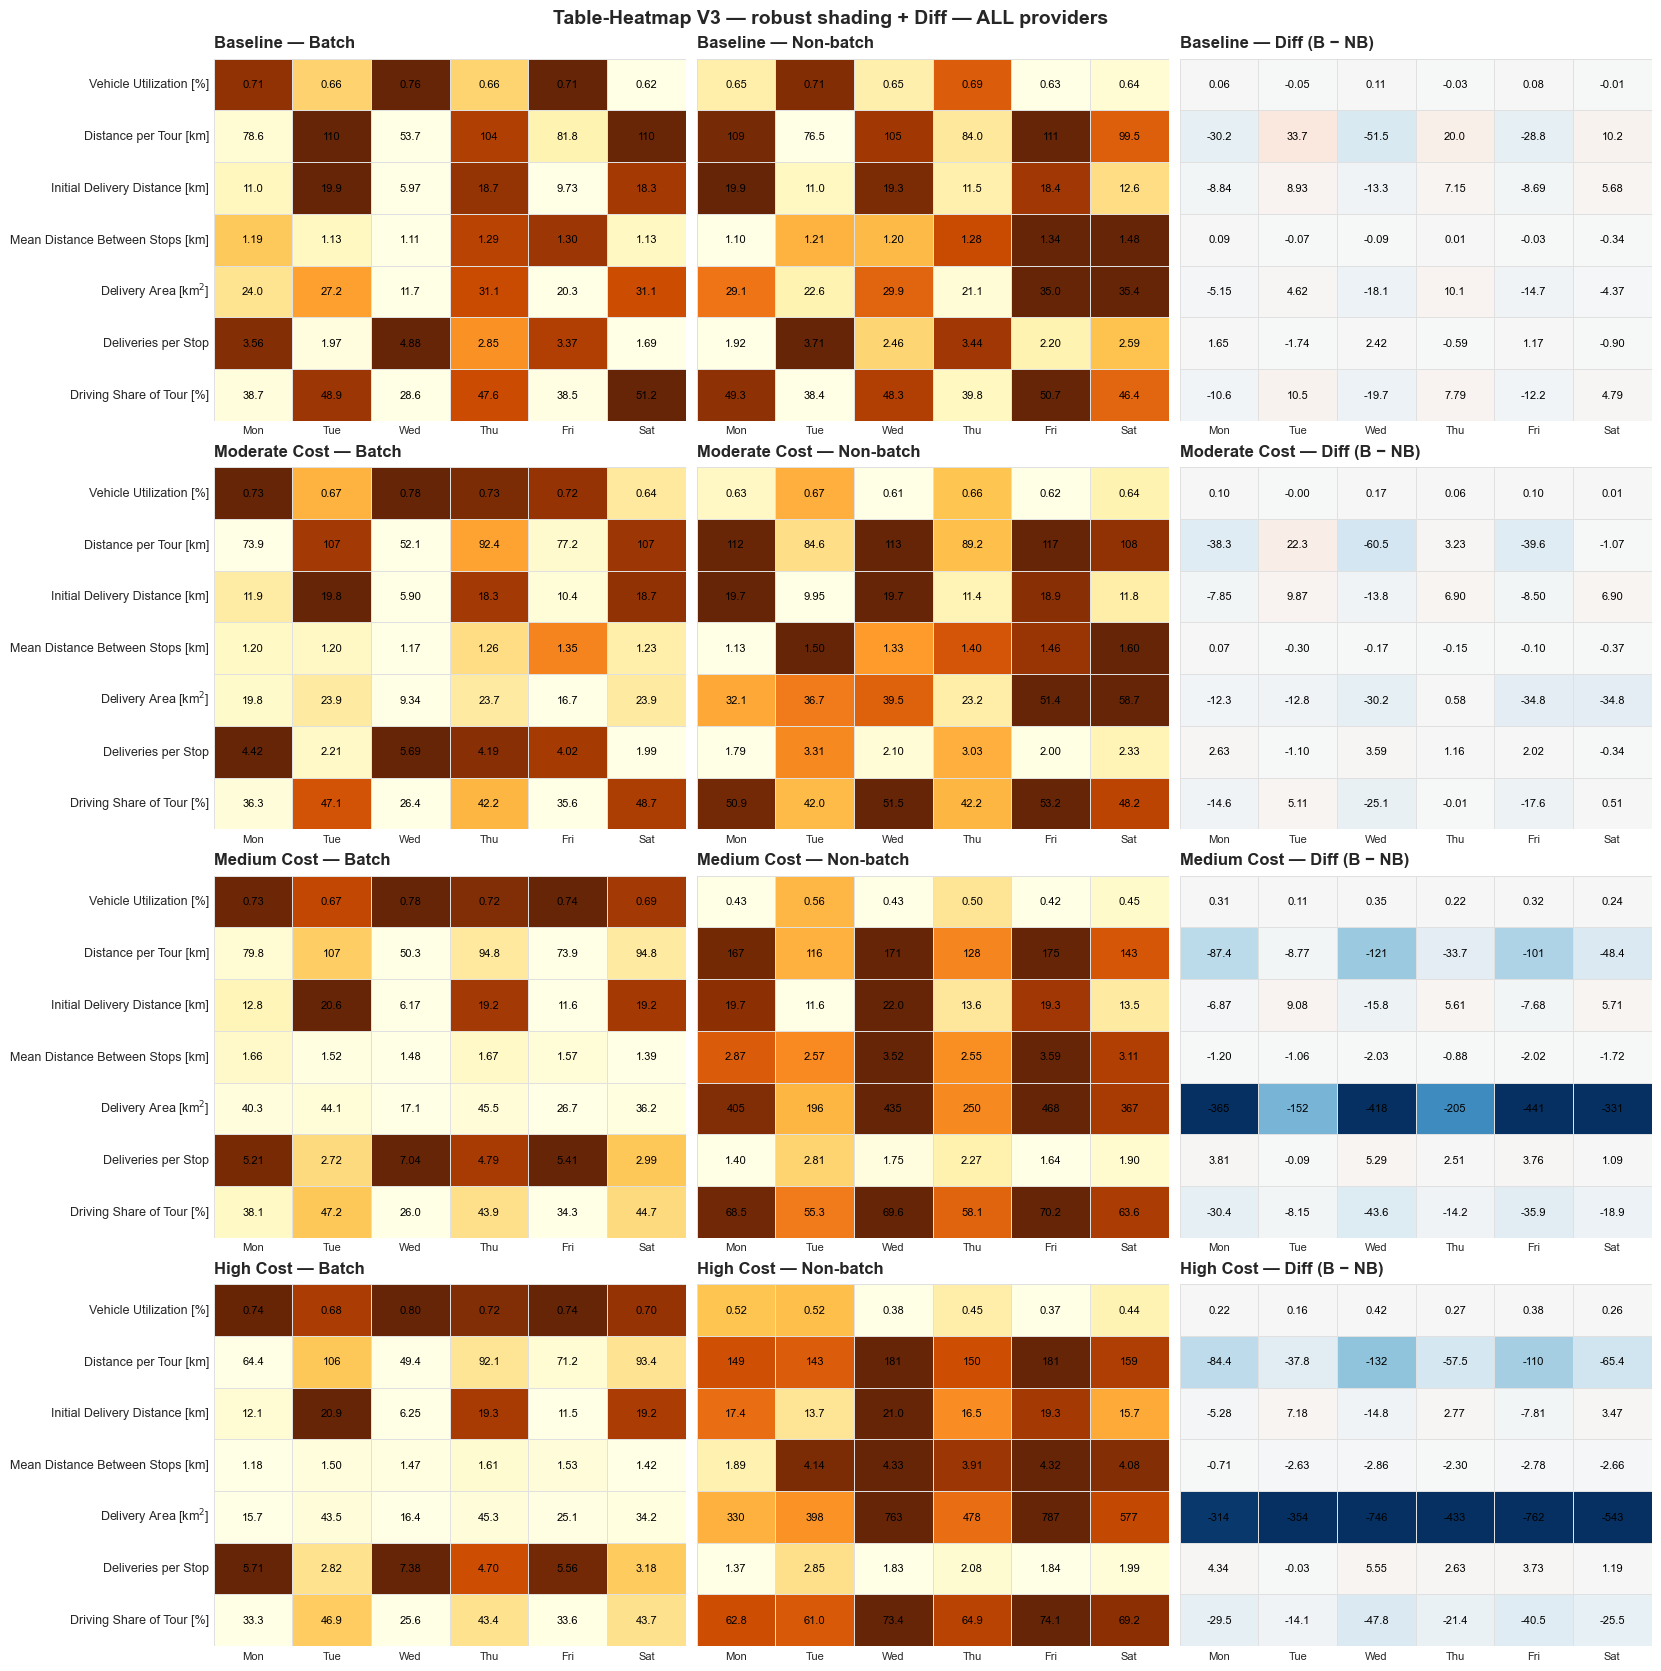

In [68]:
# Table-Heatmap V3: robuste Skalierung + optional Diff (Batch − Non-batch)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Settings
# -----------------------------
PROVIDER_TABLE_V3 = PROVIDER_TABLE_V2 if "PROVIDER_TABLE_V2" in globals() else (PROVIDER_TABLE if "PROVIDER_TABLE" in globals() else "__ALL__")
SCENARIOS_TABLE_V3 = SCENARIOS_TABLE_V2 if "SCENARIOS_TABLE_V2" in globals() else (SCENARIOS_TABLE if "SCENARIOS_TABLE" in globals() else None)
AG_BATCH_LOCAL = AG_BATCH if "AG_BATCH" in globals() else "Batch Delivery Day"
AG_NONB_LOCAL  = AG_NONBATCH if "AG_NONBATCH" in globals() else "Non-batch Delivery Day"

ADD_DIFF = True               # rechts zusätzlich Batch − Non-batch anzeigen
ROBUST_Q = (0.10, 0.90)        # Quantile für robuste Zeilen-Skalierung
DIFF_CLIP_Q = 0.95             # quantile(|diff|) für Farb-Clip
DIFF_CAP_MODE = "global"       # "global" (vergleichbar über Szenarien) oder "per_scenario"

if "df" not in globals():
    raise RuntimeError("df not found. Run the preprocessing cells first.")
if "kpis" not in globals() or not kpis:
    raise RuntimeError("kpis list not found/empty.")

d3 = df.copy()
if "provider" in d3.columns:
    d3["provider"] = d3["provider"].astype(str).str.strip().str.lower()
    if PROVIDER_TABLE_V3 != "__ALL__":
        d3 = d3[d3["provider"] == str(PROVIDER_TABLE_V3).strip().lower()]
        if d3.empty:
            raise RuntimeError(f"No rows for PROVIDER_TABLE_V3={PROVIDER_TABLE_V3!r}.")

kpis_present = [k for k in kpis if k in d3.columns]
for c in kpis_present:
    d3[c] = pd.to_numeric(d3[c], errors="coerce")

wd_order = weekday_order if "weekday_order" in globals() else sorted(d3["weekday"].astype(str).unique().tolist())
wd_labels = weekday_labels if "weekday_labels" in globals() else [str(w)[:3] for w in wd_order]
wd_label_map = dict(zip(wd_order, wd_labels))

# Aggregate: mean per run -> mean across runs
grp = ["activity_group", "weekday", "scenario"]
if "run_name" in d3.columns:
    per_run3 = d3.groupby(grp + ["run_name"], dropna=False, observed=False)[kpis_present].mean().reset_index()
    scen_avg_abs3 = per_run3.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()
else:
    scen_avg_abs3 = d3.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()

present_wd3 = scen_avg_abs3["weekday"].astype(str).unique().tolist()
wd_order3 = [w for w in wd_order if str(w) in present_wd3] or sorted(present_wd3)
wd_labels3 = [wd_label_map.get(w, str(w)[:3]) for w in wd_order3]

present_scens3 = scen_avg_abs3["scenario"].astype(str).unique().tolist()
if SCENARIOS_TABLE_V3 is None:
    if "BASELINE" in globals() and "scenarios_plot" in globals():
        SCENARIOS_TABLE_V3 = [str(BASELINE)] + [str(s) for s in scenarios_plot if str(s) in present_scens3]
        rest3 = [s for s in present_scens3 if s not in SCENARIOS_TABLE_V3]
        SCENARIOS_TABLE_V3 = SCENARIOS_TABLE_V3 + sorted(rest3)
    elif "BASELINE" in globals():
        SCENARIOS_TABLE_V3 = [str(BASELINE)] + sorted([s for s in present_scens3 if s != str(BASELINE)])
    else:
        SCENARIOS_TABLE_V3 = sorted(present_scens3)
else:
    SCENARIOS_TABLE_V3 = [str(s) for s in SCENARIOS_TABLE_V3 if str(s) in present_scens3] or sorted(present_scens3)

def _sc_lab(x: str) -> str:
    if "BASELINE" in globals() and str(x).lower() == str(BASELINE).lower():
        return "Baseline"
    return scenario_display.get(str(x), str(x)) if "scenario_display" in globals() else str(x)

def _k_lab(x: str) -> str:
    return kpi_display(x) if "kpi_display" in globals() else str(x)

def _fmt_val(v: float) -> str:
    if v is None or (isinstance(v, float) and not np.isfinite(v)):
        return ""
    v = float(v)
    av = abs(v)
    if av >= 1000:
        return f"{v:,.0f}"
    if av >= 100:
        return f"{v:.0f}"
    if av >= 10:
        return f"{v:.1f}"
    return f"{v:.2f}"

def _robust_norm_rowwise_pair(mat_left: pd.DataFrame, mat_right: pd.DataFrame, q_low=0.10, q_high=0.90):
    A = mat_left.copy().astype(float)
    B = mat_right.copy().astype(float)
    outA = A.copy()
    outB = B.copy()
    for idx in A.index:
        row = np.r_[A.loc[idx].to_numpy(dtype=float), B.loc[idx].to_numpy(dtype=float)]
        finite = np.isfinite(row)
        if not finite.any():
            outA.loc[idx] = 0.5
            outB.loc[idx] = 0.5
            continue
        vals = row[finite]
        lo = np.quantile(vals, q_low)
        hi = np.quantile(vals, q_high)
        if not np.isfinite(lo) or not np.isfinite(hi) or (hi - lo) < 1e-12:
            outA.loc[idx] = 0.5
            outB.loc[idx] = 0.5
            continue
        outA.loc[idx] = np.clip(A.loc[idx], lo, hi)
        outB.loc[idx] = np.clip(B.loc[idx], lo, hi)
        outA.loc[idx] = (outA.loc[idx] - lo) / (hi - lo)
        outB.loc[idx] = (outB.loc[idx] - lo) / (hi - lo)
    return outA, outB

def _build_mats_for_scenario(scen: str):
    sub = scen_avg_abs3[scen_avg_abs3["scenario"].astype(str) == str(scen)].copy()
    def _mat_for_ag(ag: str):
        mat = pd.DataFrame(index=kpis_present, columns=wd_order3, dtype=float)
        ann = pd.DataFrame(index=kpis_present, columns=wd_order3, dtype=object)
        sub_ag = sub[sub["activity_group"].astype(str) == str(ag)]
        for k in kpis_present:
            for wd in wd_order3:
                s = sub_ag[sub_ag["weekday"].astype(str) == str(wd)][k]
                v = float(s.mean()) if not s.empty else np.nan
                mat.loc[k, wd] = v
                ann.loc[k, wd] = _fmt_val(v)
        return mat, ann
    matB, annB = _mat_for_ag(AG_BATCH_LOCAL)
    matN, annN = _mat_for_ag(AG_NONB_LOCAL)
    normB, normN = _robust_norm_rowwise_pair(matB, matN, q_low=ROBUST_Q[0], q_high=ROBUST_Q[1])
    diff = matB - matN
    # avoid pandas applymap warning (pandas>=2.2): prefer DataFrame.map if available
    if hasattr(diff, "map"):
        annD = diff.map(_fmt_val)
    else:
        annD = diff.applymap(_fmt_val)
    return (matB, annB, normB), (matN, annN, normN), (diff, annD)

# -----------------------------
# Diff cap (optional global)
# -----------------------------
cap_global = None
if ADD_DIFF and DIFF_CAP_MODE == "global":
    abs_vals = []
    for scen in SCENARIOS_TABLE_V3:
        (_, _, _), (_, _, _), (diff_tmp, _) = _build_mats_for_scenario(scen)
        a = np.abs(diff_tmp.to_numpy(dtype=float)).ravel()
        a = a[np.isfinite(a)]
        if a.size:
            abs_vals.append(a)
    if abs_vals:
        flat = np.concatenate(abs_vals)
        cap_global = float(np.quantile(flat, DIFF_CLIP_Q))
        cap_global = max(cap_global, 1e-9)
    else:
        cap_global = 1.0

# -----------------------------
# Plot
# -----------------------------
sns.set_style("white")
n_s = len(SCENARIOS_TABLE_V3)
if n_s == 0:
    raise RuntimeError("No scenarios for SCENARIOS_TABLE_V3")

ncols = 3 if ADD_DIFF else 2
fig_w = max(13.0, 0.75 * len(wd_order3) + (12.0 if ADD_DIFF else 10.0))
fig_h = max(3.0, n_s * (0.40 * len(kpis_present) + 1.35))
fig, axes = plt.subplots(n_s, ncols, figsize=(fig_w, fig_h), constrained_layout=True)
if n_s == 1:
    axes = np.array([axes])

for i, scen in enumerate(SCENARIOS_TABLE_V3):
    (matB, annB, normB), (matN, annN, normN), (diff, annD) = _build_mats_for_scenario(scen)
    axL = axes[i, 0]
    axR = axes[i, 1]
    # Batch
    sns.heatmap(
        normB, ax=axL, cmap="YlOrBr", vmin=0, vmax=1, cbar=False,
        linewidths=0.6, linecolor="0.88",
        annot=annB.values, fmt="", annot_kws=dict(fontsize=8, color="black"),
    )
    axL.set_title(f"{_sc_lab(scen)} — Batch", loc="left", fontsize=12, fontweight="bold", pad=8)
    axL.set_xlabel("")
    axL.set_ylabel("")
    axL.set_yticklabels([_k_lab(k) for k in matB.index], rotation=0, fontsize=9)
    axL.set_xticklabels(wd_labels3, rotation=0, fontsize=8)
    axL.tick_params(axis="both", length=0)

    # Non-batch
    sns.heatmap(
        normN, ax=axR, cmap="YlOrBr", vmin=0, vmax=1, cbar=False,
        linewidths=0.6, linecolor="0.88",
        annot=annN.values, fmt="", annot_kws=dict(fontsize=8, color="black"),
    )
    axR.set_title(f"{_sc_lab(scen)} — Non-batch", loc="left", fontsize=12, fontweight="bold", pad=8)
    axR.set_xlabel("")
    axR.set_ylabel("")
    axR.set_yticklabels([])
    axR.set_xticklabels(wd_labels3, rotation=0, fontsize=8)
    axR.tick_params(axis="both", length=0)

    if ADD_DIFF:
        axD = axes[i, 2]
        diff_plot = diff.copy().astype(float)
        if DIFF_CAP_MODE == "global" and cap_global is not None:
            cap = cap_global
        else:
            flat = np.abs(diff_plot.to_numpy(dtype=float)).ravel()
            flat = flat[np.isfinite(flat)]
            cap = float(np.quantile(flat, DIFF_CLIP_Q)) if flat.size else 1.0
            cap = max(cap, 1e-9)
        diff_clip = diff_plot.clip(-cap, cap)
        sns.heatmap(
            diff_clip, ax=axD, cmap="RdBu_r", center=0.0, vmin=-cap, vmax=cap, cbar=False,
            linewidths=0.6, linecolor="0.88",
            annot=annD.values, fmt="", annot_kws=dict(fontsize=8, color="black"),
        )
        axD.set_title(f"{_sc_lab(scen)} — Diff (B − NB)", loc="left", fontsize=12, fontweight="bold", pad=8)
        axD.set_xlabel("")
        axD.set_ylabel("")
        axD.set_yticklabels([])
        axD.set_xticklabels(wd_labels3, rotation=0, fontsize=8)
        axD.tick_params(axis="both", length=0)

title_provider = "ALL providers" if PROVIDER_TABLE_V3 == "__ALL__" else f"provider={str(PROVIDER_TABLE_V3).strip().lower()}"
fig.suptitle(f"Table-Heatmap V3 — robust shading + Diff — {title_provider}", fontsize=14, fontweight="bold")
plt.show()

## TRB: KPI-Linien über die Woche (7 Provider als dünne Linien; Batch vs Non-batch)
Pro KPI eine Abbildung:
- x: Wochentag, y: KPI (absolut, gemittelt über Runs und Szenarien)
- zwei Panels: Batch vs Non-batch
- je Panel: 7 Provider als dünne Linien (gleiche Farben in beiden Panels)

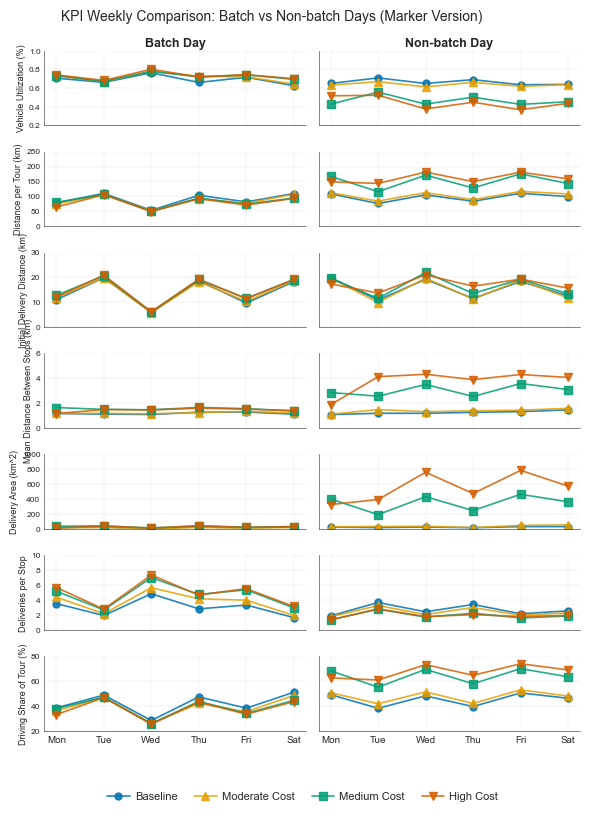

✓ Triangle marker version saved: 6.3" × 8.2"


In [69]:
# =============================================================================
# OLD VERSION: KPI Weekly Comparison with TRIANGLES (Different markers per scenario)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scenario markers: triangles for batch scenarios, circle for baseline
SCENARIO_MARKERS = {
    'basecase': 'o',           # Circle for baseline
    'batchmoderate': '^',      # Triangle up
    'batchmedium': 's',        # Square
    'batchhigh': 'v',          # Triangle down
}

# Colors - colorblind-friendly
COLORS_TRI = {
    'basecase': '#0072B2',
    'batchmoderate': '#E69F00',
    'batchmedium': '#009E73',
    'batchhigh': '#D55E00'
}

# Short row labels
ROW_LABELS_TRI = {
    'vehicle_utilization': 'Veh. Util. [%]',
    'distance_per_tour': 'Tour Dist. [km]',
    'initial_delivery_distance': 'Init. Del. Dist. [km]',
    'mean_distance_between_stops': 'Stop Dist. [km]',
    'delivery_area': 'Del. Area [km²]',
    'deliveries_per_stop': 'Del./Stop',
    'driving_share': 'Driving [%]',
}

# Prepare data
dline_tri = df.copy()

# Provider column
if "provider" not in dline_tri.columns:
    if "logisticProvider" in dline_tri.columns:
        dline_tri["provider"] = dline_tri["logisticProvider"].astype(str)
    elif "carrierID" in dline_tri.columns:
        dline_tri["provider"] = dline_tri["carrierID"].astype(str)
dline_tri["provider"] = dline_tri["provider"].astype(str).str.strip().str.lower()

# Scenarios
dline_tri["scenario"] = dline_tri["scenario"].astype(str)
present_sc_tri = dline_tri["scenario"].unique().tolist()
SCENARIOS_TRI = [s for s in ['basecase', 'batchmoderate', 'batchmedium', 'batchhigh'] if s in present_sc_tri]

# Weekday mapping
_weekday_idx_tri = {
    "mon": 0, "monday": 0, "tue": 1, "tuesday": 1, "wed": 2, "wednesday": 2,
    "thu": 3, "thursday": 3, "fri": 4, "friday": 4, "sat": 5, "saturday": 5,
    "sun": 6, "sunday": 6, "mo": 0, "di": 1, "mi": 2, "do": 3, "fr": 4, "sa": 5, "so": 6,
}
_idx_to_label_tri = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat"}

def canonical_weekday_idx_tri(x):
    if x is None: return np.nan
    return _weekday_idx_tri.get(str(x).strip().lower(), np.nan)

dline_tri["weekday"] = dline_tri["weekday"].astype(str)
dline_tri["weekday_idx"] = dline_tri["weekday"].map(canonical_weekday_idx_tri)
dline_tri = dline_tri[dline_tri["weekday_idx"].notna()].copy()
dline_tri["weekday_idx"] = dline_tri["weekday_idx"].astype(int)

# Weekday order
wd_order_idx_tri = sorted(dline_tri["weekday_idx"].unique().tolist())
wd_labels_tri = [_idx_to_label_tri.get(i, str(i)) for i in wd_order_idx_tri]

# Providers
providers_tri = [str(p).strip().lower() for p in provider_active_days.keys()]
providers_tri = [p for p in providers_tri if p in set(dline_tri["provider"].unique())]

# Provider active days
provider_active_days_idx_tri = {
    str(p).strip().lower(): {int(canonical_weekday_idx_tri(d)) for d in days if pd.notna(canonical_weekday_idx_tri(d))}
    for p, days in provider_active_days.items()
}

# KPIs
kpis_present_tri = [k for k in kpis if k in dline_tri.columns]
for c in kpis_present_tri:
    dline_tri[c] = pd.to_numeric(dline_tri[c], errors="coerce")

# Filter & batch flag
mask_tri = dline_tri["scenario"].isin(SCENARIOS_TRI) & dline_tri["provider"].isin(providers_tri)
dline_tri = dline_tri[mask_tri]
dline_tri["is_batch"] = dline_tri.apply(
    lambda r: r["weekday_idx"] in provider_active_days_idx_tri.get(r["provider"], set()), axis=1)

# Aggregate
grp_cols_tri = ["scenario", "weekday_idx", "is_batch"]
if "run_name" in dline_tri.columns:
    per_run_tri = dline_tri.groupby(grp_cols_tri + ["run_name"], dropna=False, observed=False)[kpis_present_tri].mean().reset_index()
    avg_data_tri = per_run_tri.groupby(grp_cols_tri, dropna=False, observed=False)[kpis_present_tri].mean().reset_index()
else:
    avg_data_tri = dline_tri.groupby(grp_cols_tri, dropna=False, observed=False)[kpis_present_tri].mean().reset_index()

xpos_tri = np.arange(len(wd_order_idx_tri))
wd_idx_to_xpos_tri = {idx: pos for pos, idx in enumerate(wd_order_idx_tri)}

# Scenario color/marker map
scen_color_map_tri = {}
scen_marker_map_tri = {}
for s in SCENARIOS_TRI:
    sl = s.lower()
    if 'base' in sl:
        scen_color_map_tri[s] = COLORS_TRI['basecase']
        scen_marker_map_tri[s] = SCENARIO_MARKERS['basecase']
    elif 'moderate' in sl:
        scen_color_map_tri[s] = COLORS_TRI['batchmoderate']
        scen_marker_map_tri[s] = SCENARIO_MARKERS['batchmoderate']
    elif 'medium' in sl:
        scen_color_map_tri[s] = COLORS_TRI['batchmedium']
        scen_marker_map_tri[s] = SCENARIO_MARKERS['batchmedium']
    elif 'high' in sl:
        scen_color_map_tri[s] = COLORS_TRI['batchhigh']
        scen_marker_map_tri[s] = SCENARIO_MARKERS['batchhigh']
    else:
        scen_color_map_tri[s] = '#333333'
        scen_marker_map_tri[s] = 'o'

scen_labels_tri = {'basecase': 'Baseline', 'batchmoderate': 'Moderate Cost', 
                   'batchmedium': 'Medium Cost', 'batchhigh': 'High Cost'}

# Nice tick function for clean Y-axis values
def nice_ticks_tri(y_min, y_max, n_ticks=4, force_zero=False):
    """Generate clean, round tick values that contain all data."""
    if y_max <= y_min:
        return [y_min]
    raw_step = (y_max - y_min) / max(n_ticks - 1, 1)
    magnitude = 10 ** np.floor(np.log10(raw_step + 1e-12))
    for nice in [1, 2, 2.5, 5, 10]:
        step = nice * magnitude
        if step >= raw_step * 0.9:
            break
    tick_min = np.floor(y_min / step) * step
    tick_max = np.ceil(y_max / step) * step
    # If force_zero, start at 0
    if force_zero:
        tick_min = 0
    ticks = np.arange(tick_min, tick_max + step * 0.5, step)
    # Filter out negative ticks if force_zero
    if force_zero:
        ticks = ticks[ticks >= 0]
    return ticks.tolist() if len(ticks) > 0 else [y_min, y_max]

# KPIs that should start at 0 (all physical quantities)
# Match both lowercase and original names
KPIS_START_AT_ZERO_TRI = {
    'delivery_area', 'deliveries_per_stop', 'mean_distance_between_stops',
    'distance_per_tour', 'initial_delivery_distance',
    # Also match formatted names
    'Delivery Area (km^2)', 'Deliveries per Stop', 'Mean Distance Between Stops',
    'Distance per Tour (km)', 'Initial Delivery Distance (km)'
}

def should_start_at_zero(kpi_name):
    """Check if KPI should start at 0, handling various naming conventions."""
    kpi_lower = kpi_name.lower()
    return (kpi_name in KPIS_START_AT_ZERO_TRI or 
            'area' in kpi_lower or 
            'distance' in kpi_lower or
            'per_stop' in kpi_lower or
            'per stop' in kpi_lower)

# =====================================================
# FIGURE WITH TRIANGLES - Different markers per scenario
# =====================================================
n_kpis_tri = len(kpis_present_tri)
fig_width_tri = 6.3
row_height_tri = 1.0
fig_height_tri = n_kpis_tri * row_height_tri + 1.2

fig_tri, axes_tri = plt.subplots(n_kpis_tri, 2, figsize=(fig_width_tri, fig_height_tri), sharex=True, squeeze=False)
plt.subplots_adjust(left=0.14, right=0.99, top=0.93, bottom=0.10, hspace=0.35, wspace=0.05)

all_handles_tri, all_labels_tri = [], []

for row, kpi in enumerate(kpis_present_tri):
    force_zero = should_start_at_zero(kpi)
    
    # Calculate SHARED Y-limits across both Batch and Non-batch panels
    all_vals_kpi = avg_data_tri[kpi].dropna().values
    if len(all_vals_kpi) > 0:
        y_min_data = all_vals_kpi.min()
        y_max_data = all_vals_kpi.max()
        if force_zero:
            y_min_data = 0
        y_range = y_max_data - y_min_data
        pad_tri = y_range * 0.12 if y_range > 0 else 0.1
        if force_zero:
            y_min_shared = 0
        else:
            y_min_shared = y_min_data - pad_tri * 0.3
        y_max_shared = y_max_data + pad_tri
    else:
        y_min_shared, y_max_shared = 0, 1
    
    # Calculate nice ticks shared for both panels
    yticks_shared = nice_ticks_tri(y_min_shared, y_max_shared, n_ticks=5, force_zero=force_zero)
    
    for col, (is_batch, title) in enumerate([(True, "Batch Day"), (False, "Non-batch Day")]):
        ax = axes_tri[row, col]
        sub_tri = avg_data_tri[avg_data_tri["is_batch"] == is_batch]
        
        for scen in SCENARIOS_TRI:
            sd_tri = sub_tri[sub_tri["scenario"] == scen].set_index("weekday_idx")[kpi]
            x_pts_tri = [wd_idx_to_xpos_tri[i] for i in wd_order_idx_tri if pd.notna(sd_tri.get(i, np.nan))]
            y_pts_tri = [sd_tri.get(i) for i in wd_order_idx_tri if pd.notna(sd_tri.get(i, np.nan))]
            
            if x_pts_tri:
                marker = scen_marker_map_tri.get(scen, 'o')
                color = scen_color_map_tri.get(scen, '#333')
                
                # Larger markers for triangles
                ms = 6 if marker in ['^', 'v', 's'] else 5
                
                line, = ax.plot(x_pts_tri, y_pts_tri, marker=marker, linestyle='-', 
                               color=color, alpha=0.85, markersize=ms, linewidth=1.2)
                
                if row == 0 and col == 0:
                    all_handles_tri.append(line)
                    all_labels_tri.append(scen_labels_tri.get(scen, scen))
        
        # Y-axis - use SHARED limits for direct comparison
        ax.set_yticks(yticks_shared)
        ax.set_ylim(yticks_shared[0], yticks_shared[-1])
        ax.tick_params(axis='y', labelsize=6)
        
        # Hide Y-axis labels on Non-batch column (col==1) since scale is shared
        if col == 1:
            ax.set_yticklabels([])
        
        # X-axis
        ax.set_xticks(xpos_tri)
        if row == n_kpis_tri - 1:
            ax.set_xticklabels(wd_labels_tri, fontsize=7)
        
        # Light grid on both axes
        ax.grid(True, axis="both", alpha=0.20, linewidth=0.3, linestyle='-', color='#888888')
        ax.tick_params(axis='both', length=2, width=0.4, pad=1)
        
        if col == 0:
            ax.set_ylabel(ROW_LABELS_TRI.get(kpi, kpi), fontsize=6.5, labelpad=2)
        
        if row == 0:
            ax.set_title(title, fontsize=9, fontweight='bold', pad=3)
        
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        for sp in ['left', 'bottom']:
            ax.spines[sp].set_linewidth(0.4)

# Legend with different markers shown
fig_tri.legend(all_handles_tri, all_labels_tri, loc='lower center', ncol=4, frameon=False, 
               fontsize=8, bbox_to_anchor=(0.55, 0.002), columnspacing=1.5, handletextpad=0.5)

fig_tri.suptitle("KPI Weekly Comparison: Batch vs Non-batch Days (Marker Version)", fontsize=10, y=0.98)

plt.savefig("KPI_weekly_triangle_markers.pdf", dpi=300, bbox_inches='tight')
plt.savefig("KPI_weekly_triangle_markers.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Triangle marker version saved: {fig_width_tri}\" × {fig_height_tri:.1f}\"")

In [96]:
df[(df["scenario"].astype(str).str.lower() == "basecase") & (df["weekday"].astype(str).str.lower() == "monday")]

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name,Cost per Parcel [€/parcel],weekday,scenario,active_flag,activity_group
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,NaN,NaN,NaN,NaN,NaN,2.656254,Monday,basecase,True,Batch Delivery Day
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,NaN,NaN,NaN,NaN,NaN,4.139754,Monday,basecase,True,Batch Delivery Day
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,NaN,NaN,NaN,NaN,NaN,3.246762,Monday,basecase,True,Batch Delivery Day
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,NaN,NaN,NaN,NaN,NaN,2.695286,Monday,basecase,True,Batch Delivery Day
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,NaN,NaN,NaN,NaN,NaN,3.574697,Monday,basecase,True,Batch Delivery Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1631,freight_ups_30539_veh_cep_size_m_14_3,59746.0,67822.0,2.243333,2206.0,1.630556,1970-01-01 16:35:46,1970-01-01 18:50:22,1970-01-01 02:14:36,1970-01-01 00:36:46,...,NaN,NaN,NaN,NaN,NaN,10.440376,Monday,basecase,True,Batch Delivery Day
1632,freight_amazon_31832_1_veh_cep_size_m_17_5,60714.0,74736.0,3.895000,6806.0,2.004444,1970-01-01 16:51:54,1970-01-01 20:45:36,1970-01-01 03:53:42,1970-01-01 01:53:26,...,NaN,NaN,NaN,NaN,NaN,3.689768,Monday,basecase,False,Non-batch Delivery Day
1633,freight_amazon_30855_1_veh_cep_size_m_17_9,60841.0,75443.0,4.056111,3441.0,3.100278,1970-01-01 16:54:01,1970-01-01 20:57:23,1970-01-01 04:03:22,1970-01-01 00:57:21,...,NaN,NaN,NaN,NaN,NaN,7.367063,Monday,basecase,False,Non-batch Delivery Day
1634,freight_amazon_31275_0_veh_cep_size_m_17_6,61233.0,66538.0,1.473611,2278.0,0.840833,1970-01-01 17:00:33,1970-01-01 18:28:58,1970-01-01 01:28:25,1970-01-01 00:37:58,...,NaN,NaN,NaN,NaN,NaN,10.950574,Monday,basecase,False,Non-batch Delivery Day


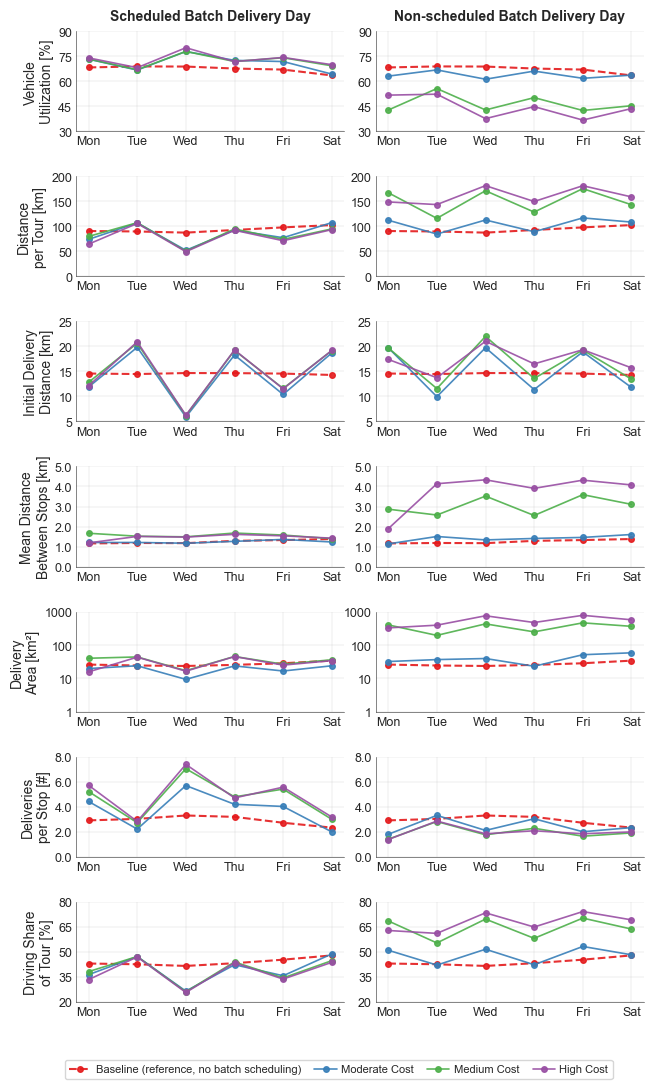

✓ Saved: TRB_KPI_weekly_comparison.pdf (7.09" × 11.0")
KPIs plotted: ['Vehicle Utilization (%)', 'Distance per Tour (km)', 'Initial Delivery Distance (km)', 'Mean Distance Between Stops (km)', 'Delivery Area (km^2)', 'Deliveries per Stop', 'Driving Share of Tour (%)']
Baseline: basecase (dashed line, same in both panels)
Batch scenarios: ['batchmoderate', 'batchmedium', 'batchhigh']


In [128]:
# TRB Publication Figure: KPI Weekly Comparison (Batch vs Non-batch Days)
# Compact multi-panel layout for Springer journal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# -----------------------------
# Springer Nature Publication Settings
# Double column width: 180mm = 7.09 inch
# -----------------------------
plt.rcParams.update({
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
    'axes.linewidth': 0.6,
    'lines.linewidth': 1.2,
    'lines.markersize': 4,
})

# Only batch scenarios for line plots (NOT baseline)
SCENARIOS_BATCH = [s for s in scenarios_plot if 'base' not in s.lower()] if "scenarios_plot" in globals() else None
BASELINE_SCENARIO = "basecase"  # Will be shown as dashed line

if "df" not in globals():
    raise RuntimeError("df not found.")
if "kpis" not in globals() or not kpis:
    raise RuntimeError("kpis list not found/empty.")

# Canonical weekday mapping
_weekday_idx = {
    "mon": 0, "monday": 0, "tue": 1, "tuesday": 1, "wed": 2, "wednesday": 2,
    "thu": 3, "thursday": 3, "fri": 4, "friday": 4, "sat": 5, "saturday": 5,
    "sun": 6, "sunday": 6, "mo": 0, "di": 1, "mi": 2, "do": 3, "fr": 4, "sa": 5, "so": 6,
}
_idx_to_label = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat"}

def canonical_weekday_idx(x):
    if x is None: return np.nan
    return _weekday_idx.get(str(x).strip().lower(), np.nan)

dline = df.copy()

# Provider column
if "provider" not in dline.columns:
    if "logisticProvider" in dline.columns:
        dline["provider"] = dline["logisticProvider"].astype(str)
    elif "carrierID" in dline.columns:
        dline["provider"] = dline["carrierID"].astype(str)
    else:
        raise RuntimeError("No provider column found.")
dline["provider"] = dline["provider"].astype(str).str.strip().str.lower()

# Scenarios
dline["scenario"] = dline["scenario"].astype(str)
present_sc = dline["scenario"].unique().tolist()

# Find baseline scenario
baseline_str = None
for sc in present_sc:
    if 'base' in sc.lower():
        baseline_str = sc
        break

# Set batch scenarios (excluding baseline)
if SCENARIOS_BATCH is None:
    SCENARIOS_BATCH = [s for s in sorted(present_sc) if 'base' not in s.lower()]
else:
    SCENARIOS_BATCH = [str(s) for s in SCENARIOS_BATCH if str(s) in present_sc and 'base' not in str(s).lower()]

# Weekdays
dline["weekday"] = dline["weekday"].astype(str)
dline["weekday_idx"] = dline["weekday"].map(canonical_weekday_idx)
dline = dline[dline["weekday_idx"].notna()].copy()
dline["weekday_idx"] = dline["weekday_idx"].astype(int)

if "weekday_order" in globals():
    _pref = [canonical_weekday_idx(w) for w in weekday_order]
    wd_order_idx = [int(i) for i in _pref if pd.notna(i)]
    present_idx = set(dline["weekday_idx"].unique().tolist())
    wd_order_idx = [i for i in wd_order_idx if i in present_idx] or sorted(present_idx)
else:
    wd_order_idx = sorted(dline["weekday_idx"].unique().tolist())

wd_labels = [_idx_to_label.get(i, str(i)) for i in wd_order_idx]

# Providers
if "provider_active_days" in globals() and isinstance(provider_active_days, dict):
    providers = [str(p).strip().lower() for p in provider_active_days.keys()]
    providers = [p for p in providers if p in set(dline["provider"].unique())]
else:
    providers = dline["provider"].unique().tolist()

# KPIs
kpis_present = [k for k in kpis if k in dline.columns]
for c in kpis_present:
    dline[c] = pd.to_numeric(dline[c], errors="coerce")

# =====================================================
# Unit conversions & Y-axis labels mapping
# =====================================================
UNIT_CONVERSIONS = {
    'vehicle_utilization': 100,
    'Vehicle Utilization (%)': 100,
}

ROW_LABELS = {
    'vehicle_utilization': 'Vehicle\nUtilization [%]',
    'Vehicle Utilization (%)': 'Vehicle\nUtilization [%]',
    'distance_per_tour': 'Distance\nper Tour [km]',
    'Distance per Tour (km)': 'Distance\nper Tour [km]',
    'initial_delivery_distance': 'Initial Delivery\nDistance [km]',
    'Initial Delivery Distance (km)': 'Initial Delivery\nDistance [km]',
    'mean_distance_between_stops': 'Mean Distance\nBetween Stops [km]',
    'Mean Distance Between Stops (km)': 'Mean Distance\nBetween Stops [km]',
    'delivery_area': 'Delivery\nArea [km²]',
    'Delivery Area (km^2)': 'Delivery\nArea [km²]',
    'deliveries_per_stop': 'Deliveries\nper Stop [#]',
    'Deliveries per Stop': 'Deliveries\nper Stop [#]',
    'driving_share': 'Driving Share\nof Tour [%]',
    'Driving Share of Tour (%)': 'Driving Share\nof Tour [%]',
}

# Apply unit conversions
for col, factor in UNIT_CONVERSIONS.items():
    if col in dline.columns:
        dline[col] = dline[col] * factor

# Provider active days
provider_active_days_idx = {
    str(p).strip().lower(): {int(canonical_weekday_idx(d)) for d in days if pd.notna(canonical_weekday_idx(d))}
    for p, days in provider_active_days.items()
}

# =====================================================
# Calculate BASELINE average per weekday (NO batch/non-batch distinction)
# =====================================================
baseline_data = dline[dline["scenario"] == baseline_str].copy() if baseline_str else pd.DataFrame()
baseline_avg_per_day = {}
if not baseline_data.empty:
    baseline_agg = baseline_data.groupby("weekday_idx")[kpis_present].mean()
    for kpi in kpis_present:
        baseline_avg_per_day[kpi] = baseline_agg[kpi].to_dict()

# =====================================================
# Filter for BATCH scenarios only & set batch flag
# =====================================================
mask = dline["scenario"].isin(SCENARIOS_BATCH) & dline["provider"].isin(providers)
dline_batch = dline[mask].copy()
dline_batch["is_batch"] = dline_batch.apply(
    lambda r: r["weekday_idx"] in provider_active_days_idx.get(r["provider"], set()), axis=1
)

# Aggregate KPIs for batch scenarios
grp_cols = ["scenario", "weekday_idx", "is_batch"]
if "run_name" in dline_batch.columns:
    per_run = dline_batch.groupby(grp_cols + ["run_name"], dropna=False, observed=False)[kpis_present].mean().reset_index()
    avg_data = per_run.groupby(grp_cols, dropna=False, observed=False)[kpis_present].mean().reset_index()
else:
    avg_data = dline_batch.groupby(grp_cols, dropna=False, observed=False)[kpis_present].mean().reset_index()

xpos = np.arange(len(wd_order_idx))
wd_idx_to_xpos = {idx: pos for pos, idx in enumerate(wd_order_idx)}

# ---------------------------------------------------------------------
# Assign Seaborn Set1 colors
# ---------------------------------------------------------------------
import seaborn as sns
scenario_order = ["Baseline", "Moderate Cost", "Medium Cost", "High Cost"]
palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

scen_labels = {
    'basecase': 'Baseline (no batching)',
    'batchmoderate': 'Moderate Cost',
    'batchmedium': 'Medium Cost',
    'batchhigh': 'High Cost'
}
scen_color_map = {}
for s in SCENARIOS_BATCH:
    sl = s.lower()
    if 'moderate' in sl: scen_color_map[s] = colors['Moderate Cost']
    elif 'medium' in sl: scen_color_map[s] = colors['Medium Cost']
    elif 'high' in sl: scen_color_map[s] = colors['High Cost']
    else: scen_color_map[s] = '#333333'

# Baseline color (red)
BASELINE_COLOR = colors['Baseline']

# =====================================================
# Pre-compute Y-axis limits (include baseline data)
# =====================================================
KPIS_START_AT_ZERO = {'delivery_area', 'deliveries_per_stop', 'mean_distance_between_stops',
                      'Delivery Area (km^2)', 'Deliveries per Stop', 'Mean Distance Between Stops (km)'}
KPIS_LOG_SCALE = {'delivery_area', 'Delivery Area (km^2)'}

kpi_ylims = {}
for kpi in kpis_present:
    all_vals = list(avg_data[kpi].dropna().values)
    # Include baseline values
    if kpi in baseline_avg_per_day:
        all_vals.extend(baseline_avg_per_day[kpi].values())
    all_vals = np.array(all_vals)
    if len(all_vals) > 0:
        y_min, y_max = all_vals.min(), all_vals.max()
        if kpi in KPIS_START_AT_ZERO:
            y_min = 0
        y_range = y_max - y_min
        pad = y_range * 0.08 if y_range > 0 else 0.1
        kpi_ylims[kpi] = (y_min, y_max + pad)
    else:
        kpi_ylims[kpi] = (0, 1)

def nice_ticks(vmin, vmax, n_ticks=5):
    if vmax <= vmin:
        return np.linspace(vmin, vmax, n_ticks)
    range_val = vmax - vmin
    rough_step = range_val / (n_ticks - 1)
    magnitude = 10 ** np.floor(np.log10(rough_step))
    residual = rough_step / magnitude
    if residual <= 1.5:
        nice_step = 1 * magnitude
    elif residual <= 3:
        nice_step = 2 * magnitude
    elif residual <= 7:
        nice_step = 5 * magnitude
    else:
        nice_step = 10 * magnitude
    nice_min = np.floor(vmin / nice_step) * nice_step
    nice_max = np.ceil(vmax / nice_step) * nice_step
    ticks = np.arange(nice_min, nice_max + nice_step * 0.5, nice_step)
    if len(ticks) > 6:
        ticks = np.linspace(ticks[0], ticks[-1], 5)
    return ticks, nice_min, nice_max

# =====================================================
# SPRINGER NATURE FIGURE
# =====================================================
n_kpis = len(kpis_present)
fig_width = 7.09  # 180mm
fig_height = 11.03

fig, axes = plt.subplots(n_kpis, 2, figsize=(fig_width, fig_height), sharex=False, squeeze=False)
plt.subplots_adjust(left=0.18, right=0.98, top=0.96, bottom=0.08, hspace=0.45, wspace=0.12)

all_handles, all_labels = [], []
baseline_handle_added = False

for row, kpi in enumerate(kpis_present):
    y_min_data, y_max_data = kpi_ylims[kpi]
    use_log = kpi in KPIS_LOG_SCALE
    
    if use_log:
        y_min = max(1, y_min_data * 0.5)
        y_max = y_max_data * 1.2
        ticks = None
    else:
        ticks, y_min, y_max = nice_ticks(y_min_data, y_max_data, n_ticks=5)
    
    for col, (is_batch, title) in enumerate([
        (True, "Scheduled Batch Delivery Day"),
        (False, "Non-scheduled Batch Delivery Day")
    ]):
        ax = axes[row, col]
        sub = avg_data[avg_data["is_batch"] == is_batch]
        
        # Plot BASELINE as dashed line (same for both panels - no batch distinction)
        if kpi in baseline_avg_per_day:
            x_pts_base = [wd_idx_to_xpos[i] for i in wd_order_idx if i in baseline_avg_per_day[kpi]]
            y_pts_base = [baseline_avg_per_day[kpi][i] for i in wd_order_idx if i in baseline_avg_per_day[kpi]]
            if x_pts_base:
                baseline_line, = ax.plot(x_pts_base, y_pts_base, 'o--', color=BASELINE_COLOR, 
                                         alpha=0.9, linewidth=1.5, markersize=4)
                if row == 0 and col == 0 and not baseline_handle_added:
                    all_handles.append(baseline_line)
                    all_labels.append("Baseline (reference, no batch scheduling)")
                    baseline_handle_added = True
        
        # Plot batch scenarios as solid lines
        for scen in SCENARIOS_BATCH:
            sd = sub[sub["scenario"] == scen].set_index("weekday_idx")[kpi]
            x_pts = [wd_idx_to_xpos[i] for i in wd_order_idx if pd.notna(sd.get(i, np.nan))]
            y_pts = [sd.get(i) for i in wd_order_idx if pd.notna(sd.get(i, np.nan))]
            if x_pts:
                line, = ax.plot(x_pts, y_pts, 'o-', color=scen_color_map[scen], alpha=0.9)
                if row == 0 and col == 0:
                    all_handles.append(line)
                    all_labels.append(scen_labels.get(scen, scen))
        
        # Y-axis
        if use_log:
            ax.set_yscale('log')
            ax.set_ylim(y_min, y_max)
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
        else:
            ax.set_ylim(y_min, y_max)
            ax.set_yticks(ticks)
            if y_max > 100:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
            elif y_max > 10:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.0f}'))
            elif y_max > 1:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
            else:
                ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.2f}'))
        
        # X-axis
        ax.set_xticks(xpos)
        ax.set_xticklabels(wd_labels)
        
        ax.grid(True, axis='both', alpha=0.4, linewidth=0.25, linestyle='-', color='#888888')
        ax.tick_params(axis='both', length=2, width=0.4, pad=1)
        
        if col == 0:
            ax.set_ylabel(ROW_LABELS.get(kpi, kpi), fontsize=10, labelpad=3)
        
        if row == 0:
            ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
        
        for sp in ['top', 'right']:
            ax.spines[sp].set_visible(False)
        for sp in ['left', 'bottom']:
            ax.spines[sp].set_linewidth(0.4)

# Legend
fig.legend(all_handles, all_labels, loc='lower center', ncol=len(all_labels),
           fontsize=8, bbox_to_anchor=(0.55, 0.005), columnspacing=1.2, handletextpad=0.4)

plt.savefig("TRB_KPI_weekly_comparison.pdf", dpi=300, bbox_inches='tight')
plt.savefig("TRB_KPI_weekly_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved: TRB_KPI_weekly_comparison.pdf ({fig_width}\" × {fig_height:.1f}\")")
print(f"KPIs plotted: {kpis_present}")
print(f"Baseline: {baseline_str} (dashed line, same in both panels)")
print(f"Batch scenarios: {SCENARIOS_BATCH}")

In [118]:
# =============================================================================
# Table: KPI Weekly Comparison Data (Scheduled vs Non-scheduled Batch Days)
# =============================================================================
import pandas as pd

# Mapping weekday idx to label
_idx_to_label = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat"}

# Prepare data for table output
table_rows = []
for _, row in avg_data.iterrows():
    scen = row["scenario"]
    wd_idx = int(row["weekday_idx"])
    is_batch = row["is_batch"]
    
    table_row = {
        "Scenario": scen_labels.get(scen, scen),
        "Weekday": _idx_to_label.get(wd_idx, str(wd_idx)),
        "Day Type": "Scheduled" if is_batch else "Non-scheduled",
    }
    
    # Add KPI values
    for kpi in kpis_present:
        kpi_label = ROW_LABELS.get(kpi, kpi).replace("\n", " ")
        table_row[kpi_label] = row[kpi]
    
    table_rows.append(table_row)

# Create DataFrame
table_df = pd.DataFrame(table_rows)

# Sort by Scenario, Day Type, Weekday
weekday_order_map = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3, "Fri": 4, "Sat": 5}
scenario_order_map = {"Baseline": 0, "Moderate Cost": 1, "Medium Cost": 2, "High Cost": 3}
day_type_order = {"Scheduled": 0, "Non-scheduled": 1}

table_df["_scen_order"] = table_df["Scenario"].map(scenario_order_map)
table_df["_wd_order"] = table_df["Weekday"].map(weekday_order_map)
table_df["_day_order"] = table_df["Day Type"].map(day_type_order)
table_df = table_df.sort_values(["_scen_order", "_day_order", "_wd_order"]).drop(columns=["_scen_order", "_wd_order", "_day_order"])
table_df = table_df.reset_index(drop=True)

# Round numeric columns
numeric_cols = [c for c in table_df.columns if c not in ["Scenario", "Weekday", "Day Type"]]
table_df[numeric_cols] = table_df[numeric_cols].round(2)

print("KPI Weekly Comparison Data:")
print(f"Scenarios: {table_df['Scenario'].unique().tolist()}")
print(f"Day Types: {table_df['Day Type'].unique().tolist()}")
print(f"KPIs: {numeric_cols}")
print()
table_df.to_csv("KPI_weekly_comparison_data.csv", index=False)

KPI Weekly Comparison Data:
Scenarios: ['Moderate Cost', 'Medium Cost', 'High Cost']
Day Types: ['Scheduled', 'Non-scheduled']
KPIs: ['Vehicle Utilization [%]', 'Distance per Tour [km]', 'Initial Delivery Distance [km]', 'Mean Distance Between Stops [km]', 'Delivery Area [km²]', 'Deliveries per Stop [#]', 'Driving Share of Tour [%]']



In [26]:
# =============================================================================
# TOUR MAP VISUALIZATION: GLS Carrier (Carrier gls_30161) - Thursday vs Friday
# Comparing Baseline tours with High Cost Batch scenario tours
# =============================================================================
import os
import gzip
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np

# --- Configuration ---
CARRIER_NAME = "gls"  # Filter by carrier name (e.g., "gls")

# Different PLZ areas for Thursday vs Friday (as they have different carriers)
PLZ_AREA_THURSDAY = "30161"    # PLZ area for Thursday (gls_30161)
PLZ_AREA_FRIDAY = "30916"      # PLZ area for Friday (gls_30916 - where deliveries are consolidated)

# Carrier filters for different days
CARRIER_ID_THURSDAY = f"{CARRIER_NAME}_{PLZ_AREA_THURSDAY}"  # gls_30161
CARRIER_ID_FRIDAY = f"{CARRIER_NAME}_{PLZ_AREA_FRIDAY}"      # gls_30916

# Paths to simulation results
BASE_PATH = r"C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch"
THURSDAY_DATE = "15052025"  # Donnerstag - Batch day for GLS
FRIDAY_DATE = "16052025"    # Freitag - Non-batch day for GLS

# Scenario folders with their carrier filters
scenarios_to_load = {
    "Baseline Thursday": {
        "path": f"basecase Week/basecase_{THURSDAY_DATE}_iter150_jsprit100",
        "carrier_filter": CARRIER_ID_THURSDAY
    },
    "High Cost Thursday": {
        "path": f"batchhigh Week/batchhigh_{THURSDAY_DATE}_iter150_jsprit100",
        "carrier_filter": CARRIER_ID_THURSDAY
    },
    "Baseline Friday": {
        "path": f"basecase Week/basecase_{FRIDAY_DATE}_iter150_jsprit100",
        "carrier_filter": CARRIER_ID_FRIDAY
    },
    "High Cost Friday": {
        "path": f"batchhigh Week/batchhigh_{FRIDAY_DATE}_iter150_jsprit100",
        "carrier_filter": CARRIER_ID_FRIDAY
    },
}

# --- Function to extract tours from events XML ---
def extract_tours_from_events(events_gz_path, carrier_filter):
    """
    Extract vehicle tour coordinates from MATSim events.xml.gz file.
    Returns a DataFrame with vehicle_id, activity_type, link_id, x, y, time for matching carriers.
    """
    tours = []
    
    if not os.path.exists(events_gz_path):
        print(f"[WARN] File not found: {events_gz_path}")
        return pd.DataFrame()
    
    print(f"[INFO] Parsing events from: {events_gz_path}")
    
    try:
        with gzip.open(events_gz_path, 'rt', encoding='utf-8') as f:
            # Use iterparse for large files
            context = ET.iterparse(f, events=('end',))
            
            for event, elem in context:
                if elem.tag == 'event':
                    event_type = elem.get('type', '')
                    vehicle = elem.get('vehicle', '') or elem.get('vehicleId', '') or elem.get('person', '')
                    
                    # Filter for our carrier
                    if carrier_filter.lower() not in vehicle.lower():
                        elem.clear()
                        continue
                    
                    # Relevant events: actend, actstart, entered link, left link
                    if event_type in ['actend', 'actstart', 'entered link', 'left link', 
                                      'freight shipment delivered', 'freight tour starts', 
                                      'freight tour ends', 'vehicle enters traffic',
                                      'vehicle leaves traffic']:
                        tours.append({
                            'vehicle_id': vehicle,
                            'event_type': event_type,
                            'time': float(elem.get('time', 0)),
                            'link': elem.get('link', ''),
                            'x': elem.get('x'),
                            'y': elem.get('y'),
                        })
                    
                elem.clear()
                
    except Exception as e:
        print(f"[ERROR] Failed to parse {events_gz_path}: {e}")
        return pd.DataFrame()
    
    if tours:
        df = pd.DataFrame(tours)
        print(f"[INFO] Found {len(df)} events for carrier filter '{carrier_filter}'")
        return df
    else:
        print(f"[WARN] No events found for carrier '{carrier_filter}'")
        return pd.DataFrame()


# --- Function to extract tours from carriers XML ---
def extract_tours_from_carriers(carriers_gz_path, carrier_filter):
    """
    Extract vehicle tour coordinates from MATSim output_carriers.xml.gz file.
    Returns a DataFrame with vehicle_id, service_id, link_id, location (x, y).
    """
    tours = []
    
    if not os.path.exists(carriers_gz_path):
        print(f"[WARN] File not found: {carriers_gz_path}")
        return pd.DataFrame()
    
    print(f"[INFO] Parsing carriers from: {carriers_gz_path}")
    
    try:
        with gzip.open(carriers_gz_path, 'rt', encoding='utf-8') as f:
            tree = ET.parse(f)
            root = tree.getroot()
            
            # Find all carriers
            for carrier in root.findall('.//carrier'):
                carrier_id = carrier.get('id', '')
                if carrier_filter.lower() not in carrier_id.lower():
                    continue
                
                print(f"[INFO] Found matching carrier: {carrier_id}")
                
                # Find plans/tours for this carrier
                for plan in carrier.findall('.//plan'):
                    for tour in plan.findall('.//tour'):
                        vehicle_id = tour.get('vehicleId', '')
                        
                        # Get activities in the tour (legs and acts)
                        stop_idx = 0
                        for child in tour:
                            if child.tag == 'leg':
                                # Legs have start/end links
                                start_link = child.get('startLinkId', '')
                                end_link = child.get('endLinkId', '')
                            elif child.tag == 'act':
                                # Activities (service, start, end)
                                act_type = child.get('type', '')
                                link_id = child.get('linkId', '')
                                service_id = child.get('serviceId', '')
                                start_time = child.get('startTime', '')
                                end_time = child.get('endTime', '')
                                
                                tours.append({
                                    'carrier_id': carrier_id,
                                    'vehicle_id': vehicle_id,
                                    'stop_index': stop_idx,
                                    'act_type': act_type,
                                    'service_id': service_id,
                                    'link_id': link_id,
                                    'start_time': start_time,
                                    'end_time': end_time,
                                })
                                stop_idx += 1
                
    except Exception as e:
        print(f"[ERROR] Failed to parse {carriers_gz_path}: {e}")
        return pd.DataFrame()
    
    if tours:
        df = pd.DataFrame(tours)
        print(f"[INFO] Found {len(df)} tour stops for carrier filter '{carrier_filter}'")
        return df
    else:
        print(f"[WARN] No tour data found for carrier '{carrier_filter}'")
        return pd.DataFrame()


# --- Function to get link coordinates from network ---
def load_network_coordinates(network_gz_path):
    """
    Load link coordinates from MATSim network.xml.gz file.
    Returns dict: link_id -> (from_x, from_y, to_x, to_y)
    """
    if not os.path.exists(network_gz_path):
        print(f"[WARN] Network file not found: {network_gz_path}")
        return {}
    
    print(f"[INFO] Loading network coordinates from: {network_gz_path}")
    
    nodes = {}
    links = {}
    
    try:
        with gzip.open(network_gz_path, 'rt', encoding='utf-8') as f:
            tree = ET.parse(f)
            root = tree.getroot()
            
            # First pass: collect all nodes
            for node in root.findall('.//node'):
                node_id = node.get('id')
                x = float(node.get('x', 0))
                y = float(node.get('y', 0))
                nodes[node_id] = (x, y)
            
            # Second pass: collect links with from/to node coords
            for link in root.findall('.//link'):
                link_id = link.get('id')
                from_node = link.get('from')
                to_node = link.get('to')
                
                if from_node in nodes and to_node in nodes:
                    fx, fy = nodes[from_node]
                    tx, ty = nodes[to_node]
                    # Store midpoint as link location
                    links[link_id] = ((fx + tx) / 2, (fy + ty) / 2)
                    
        print(f"[INFO] Loaded {len(links)} link coordinates")
        
    except Exception as e:
        print(f"[ERROR] Failed to load network: {e}")
        
    return links


# --- Load carrier tours for each scenario ---
print("="*60)
print(f"Loading tours for carriers: {CARRIER_ID_THURSDAY} (Thursday) / {CARRIER_ID_FRIDAY} (Friday)")
print("="*60)

all_tours = {}

for scenario_name, config in scenarios_to_load.items():
    rel_path = config["path"]
    carrier_filter = config["carrier_filter"]
    
    full_path = os.path.join(BASE_PATH, rel_path)
    
    # Find the carriers XML file
    prefix = os.path.basename(rel_path).replace("_iter150_jsprit100", "")
    carriers_file = os.path.join(full_path, f"{prefix}.output_carriers.xml.gz")
    events_file = os.path.join(full_path, f"{prefix}.output_events.xml.gz")
    
    print(f"\n--- {scenario_name} (Carrier: {carrier_filter}) ---")
    print(f"Looking for carriers file: {carriers_file}")
    
    # Try carriers XML first
    df_tours = extract_tours_from_carriers(carriers_file, carrier_filter)
    
    if df_tours.empty:
        print("[INFO] Trying events file instead...")
        df_tours = extract_tours_from_events(events_file, carrier_filter)
    
    all_tours[scenario_name] = df_tours

print("\n" + "="*60)
print("Data loading complete. Preparing visualization...")
print("="*60)

Loading tours for carriers: gls_30161 (Thursday) / gls_30916 (Friday)

--- Baseline Thursday (Carrier: gls_30161) ---
Looking for carriers file: C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\basecase Week/basecase_15052025_iter150_jsprit100\basecase_15052025.output_carriers.xml.gz
[INFO] Parsing carriers from: C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\basecase Week/basecase_15052025_iter150_jsprit100\basecase_15052025.output_carriers.xml.gz
[WARN] No tour data found for carrier 'gls_30161'
[INFO] Trying events file instead...
[INFO] Parsing events from: C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\basecase Week/basecase_15052025_iter150_jsprit100\basecase_15052025.output_events.xml.gz
[INFO] Found 4708 events for carrier filter 'gls_30161'

--- High Cost Thursday (Carrier: gls_30161) ---
Looking for carriers file: C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\

In [27]:
# =============================================================================
# LOAD NETWORK COORDINATES AND PREPARE TOUR VISUALIZATION DATA
# =============================================================================

# --- Load network to get link coordinates ---
# Use the network from one of the scenarios (same network for all)
network_path = os.path.join(BASE_PATH, "basecase Week/basecase_15052025_iter150_jsprit100", 
                            "basecase_15052025.output_network.xml.gz")

link_coords = load_network_coordinates(network_path)

# --- Add coordinates to tour data ---
def add_coordinates_to_tours(df, link_coords):
    """Add x, y coordinates based on link_id from network."""
    if df.empty:
        return df
    
    # For events data, use 'link' column
    if 'link' in df.columns:
        link_col = 'link'
    elif 'link_id' in df.columns:
        link_col = 'link_id'
    else:
        return df
    
    # Map link to coordinates
    def get_coords(link_id):
        if link_id in link_coords:
            return link_coords[link_id]
        return (np.nan, np.nan)
    
    coords = df[link_col].apply(get_coords)
    df = df.copy()
    df['x'] = coords.apply(lambda c: c[0])
    df['y'] = coords.apply(lambda c: c[1])
    
    return df

# Add coordinates to all tour data
for scenario_name in all_tours:
    if not all_tours[scenario_name].empty:
        all_tours[scenario_name] = add_coordinates_to_tours(all_tours[scenario_name], link_coords)
        # Filter out rows without coordinates
        all_tours[scenario_name] = all_tours[scenario_name].dropna(subset=['x', 'y'])
        print(f"{scenario_name}: {len(all_tours[scenario_name])} events with coordinates")

# --- Show summary of vehicles per scenario ---
print("\n" + "="*60)
print("Summary of vehicles per scenario:")
print("="*60)
for scenario_name, df in all_tours.items():
    if not df.empty:
        vehicles = df['vehicle_id'].unique()
        print(f"\n{scenario_name}:")
        print(f"  Total events: {len(df)}")
        print(f"  Unique vehicles: {len(vehicles)}")
        for v in sorted(vehicles)[:10]:  # Show first 10 vehicles
            v_count = len(df[df['vehicle_id'] == v])
            print(f"    - {v}: {v_count} events")

[INFO] Loading network coordinates from: C:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\input\simRes\batch\basecase Week/basecase_15052025_iter150_jsprit100\basecase_15052025.output_network.xml.gz
[INFO] Loaded 544514 link coordinates
Baseline Thursday: 4708 events with coordinates
High Cost Thursday: 6664 events with coordinates
Baseline Friday: 8730 events with coordinates
High Cost Friday: 23600 events with coordinates

Summary of vehicles per scenario:

Baseline Thursday:
  Total events: 4708
  Unique vehicles: 3
    - freight_gls_30161_veh_cep_size_l_8_3: 808 events
    - freight_gls_30161_veh_cep_size_m_7_1: 1890 events
    - freight_gls_30161_veh_cep_size_m_7_2: 2010 events

High Cost Thursday:
  Total events: 6664
  Unique vehicles: 6
    - freight_gls_30161_veh_cep_size_m_10_6: 726 events
    - freight_gls_30161_veh_cep_size_m_7_2: 1096 events
    - freight_gls_30161_veh_cep_size_m_7_3: 1206 events
    - freight_gls_30161_veh_cep_size_m_7_4: 1264 events
    - fre

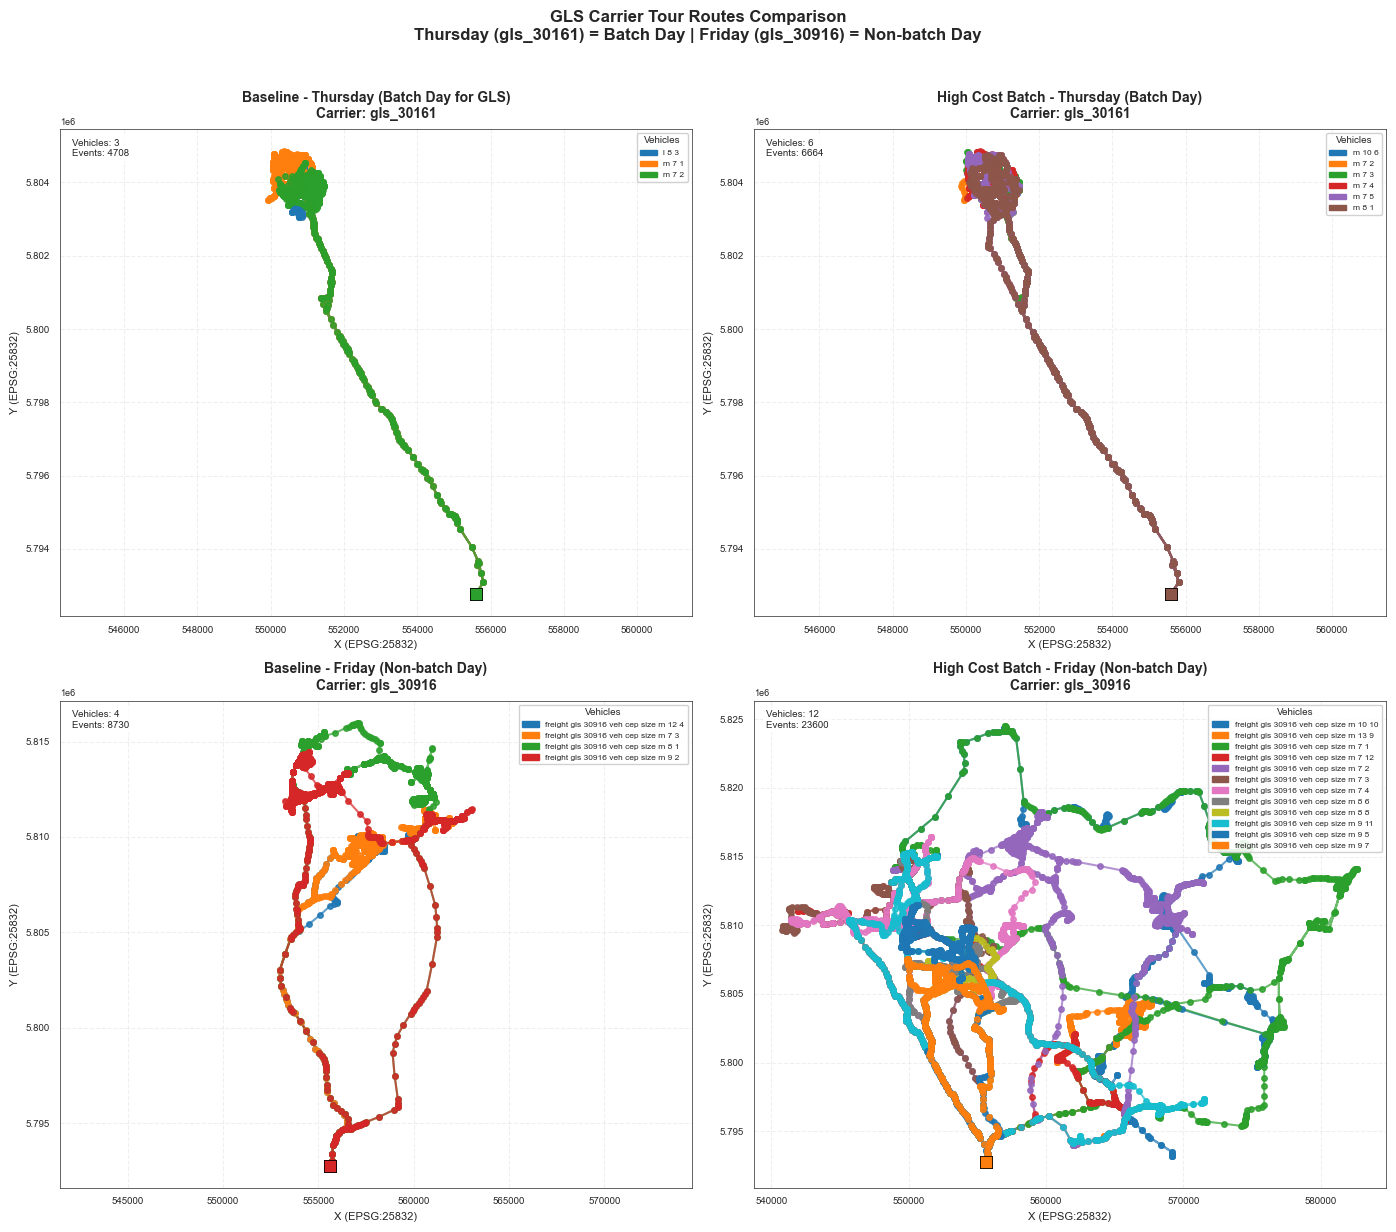


✓ Saved: tour_map_gls_thursday_friday_comparison.png/pdf


In [28]:
# =============================================================================
# TOUR MAP VISUALIZATION: 2x2 Grid Comparison
# Top Row: Thursday (Batch Day for GLS) - Baseline vs High Cost
# Bottom Row: Friday (Non-batch Day) - Baseline vs High Cost
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
import contextily as ctx

# --- Color palette for vehicles ---
vehicle_colors = plt.cm.tab10.colors  # 10 distinct colors

def plot_tour_routes(ax, df, title, show_legend=True):
    """
    Plot all vehicle tour routes on a matplotlib axis.
    Each vehicle gets a different color, routes are drawn as connected lines.
    """
    if df.empty:
        ax.text(0.5, 0.5, "No data available", ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(title, fontsize=10, fontweight='bold')
        return
    
    # Get unique vehicles
    vehicles = sorted(df['vehicle_id'].unique())
    
    # Create color mapping
    color_map = {v: vehicle_colors[i % len(vehicle_colors)] for i, v in enumerate(vehicles)}
    
    # Plot each vehicle's tour
    legend_handles = []
    
    for vehicle in vehicles:
        veh_df = df[df['vehicle_id'] == vehicle].sort_values('time')
        
        if len(veh_df) < 2:
            continue
        
        # Get coordinates
        x_coords = veh_df['x'].values
        y_coords = veh_df['y'].values
        
        # Short vehicle name for legend
        short_name = vehicle.replace('freight_gls_30161_veh_cep_size_', '').replace('_', ' ')
        
        # Plot route as connected line segments
        color = color_map[vehicle]
        ax.plot(x_coords, y_coords, '-', color=color, alpha=0.7, linewidth=1.5, 
                label=short_name, zorder=2)
        
        # Mark start point (hub/depot)
        ax.scatter(x_coords[0], y_coords[0], c=[color], s=80, marker='s', 
                   edgecolors='black', linewidths=0.5, zorder=4)
        
        # Mark stop points
        ax.scatter(x_coords[1:-1], y_coords[1:-1], c=[color], s=15, alpha=0.6, zorder=3)
        
        # Mark end point
        ax.scatter(x_coords[-1], y_coords[-1], c=[color], s=80, marker='s',
                   edgecolors='black', linewidths=0.5, zorder=4)
        
        legend_handles.append(mpatches.Patch(color=color, label=short_name))
    
    # Set title and labels
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    ax.set_xlabel('X (EPSG:25832)', fontsize=8)
    ax.set_ylabel('Y (EPSG:25832)', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)
    
    # Add legend
    if show_legend and legend_handles:
        ax.legend(handles=legend_handles, loc='upper right', fontsize=6, 
                  framealpha=0.9, title='Vehicles', title_fontsize=7)
    
    # Equal aspect ratio
    ax.set_aspect('equal', adjustable='datalim')
    
    # Grid
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add stats annotation
    n_vehicles = len(vehicles)
    n_stops = len(df)
    stats_text = f"Vehicles: {n_vehicles}\nEvents: {n_stops}"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=7,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# --- Create 2x2 plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Define what to plot in each subplot
plot_configs = [
    (axes[0, 0], "Baseline Thursday", f"Baseline - Thursday (Batch Day for GLS)\nCarrier: {CARRIER_ID_THURSDAY}"),
    (axes[0, 1], "High Cost Thursday", f"High Cost Batch - Thursday (Batch Day)\nCarrier: {CARRIER_ID_THURSDAY}"),
    (axes[1, 0], "Baseline Friday", f"Baseline - Friday (Non-batch Day)\nCarrier: {CARRIER_ID_FRIDAY}"),
    (axes[1, 1], "High Cost Friday", f"High Cost Batch - Friday (Non-batch Day)\nCarrier: {CARRIER_ID_FRIDAY}"),
]

for ax, scenario_key, title in plot_configs:
    df_plot = all_tours.get(scenario_key, pd.DataFrame())
    plot_tour_routes(ax, df_plot, title)

# Overall title
fig.suptitle(f'GLS Carrier Tour Routes Comparison\n'
             f'Thursday ({CARRIER_ID_THURSDAY}) = Batch Day | Friday ({CARRIER_ID_FRIDAY}) = Non-batch Day',
             fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig(f"tour_map_gls_thursday_friday_comparison.png", dpi=200, bbox_inches='tight')
plt.savefig(f"tour_map_gls_thursday_friday_comparison.pdf", dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: tour_map_gls_thursday_friday_comparison.png/pdf")

Global map extent (Web Mercator):
  X: 1063209 to 1142821
  Y: 6847200 to 6907515


c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\contextily\plotting.py:298: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from font(s) Arial.
  draw()
c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\contextily\plotting.py:298: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from font(s) Arial.
  draw()
c:\Users\bienzeisler\Documents\GitHub\HAGRID\parcel-analysis\matsim-py\Lib\site-packages\contextily\plotting.py:298: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from font(s) Arial.
  draw()
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_14516\2312935608.py:194: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.025, 1, 0.97])
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_14516\2312935608.py:195: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from font(s) Arial.
  plt.savefig(f"tour_map_gls_thursday_friday_clean.p

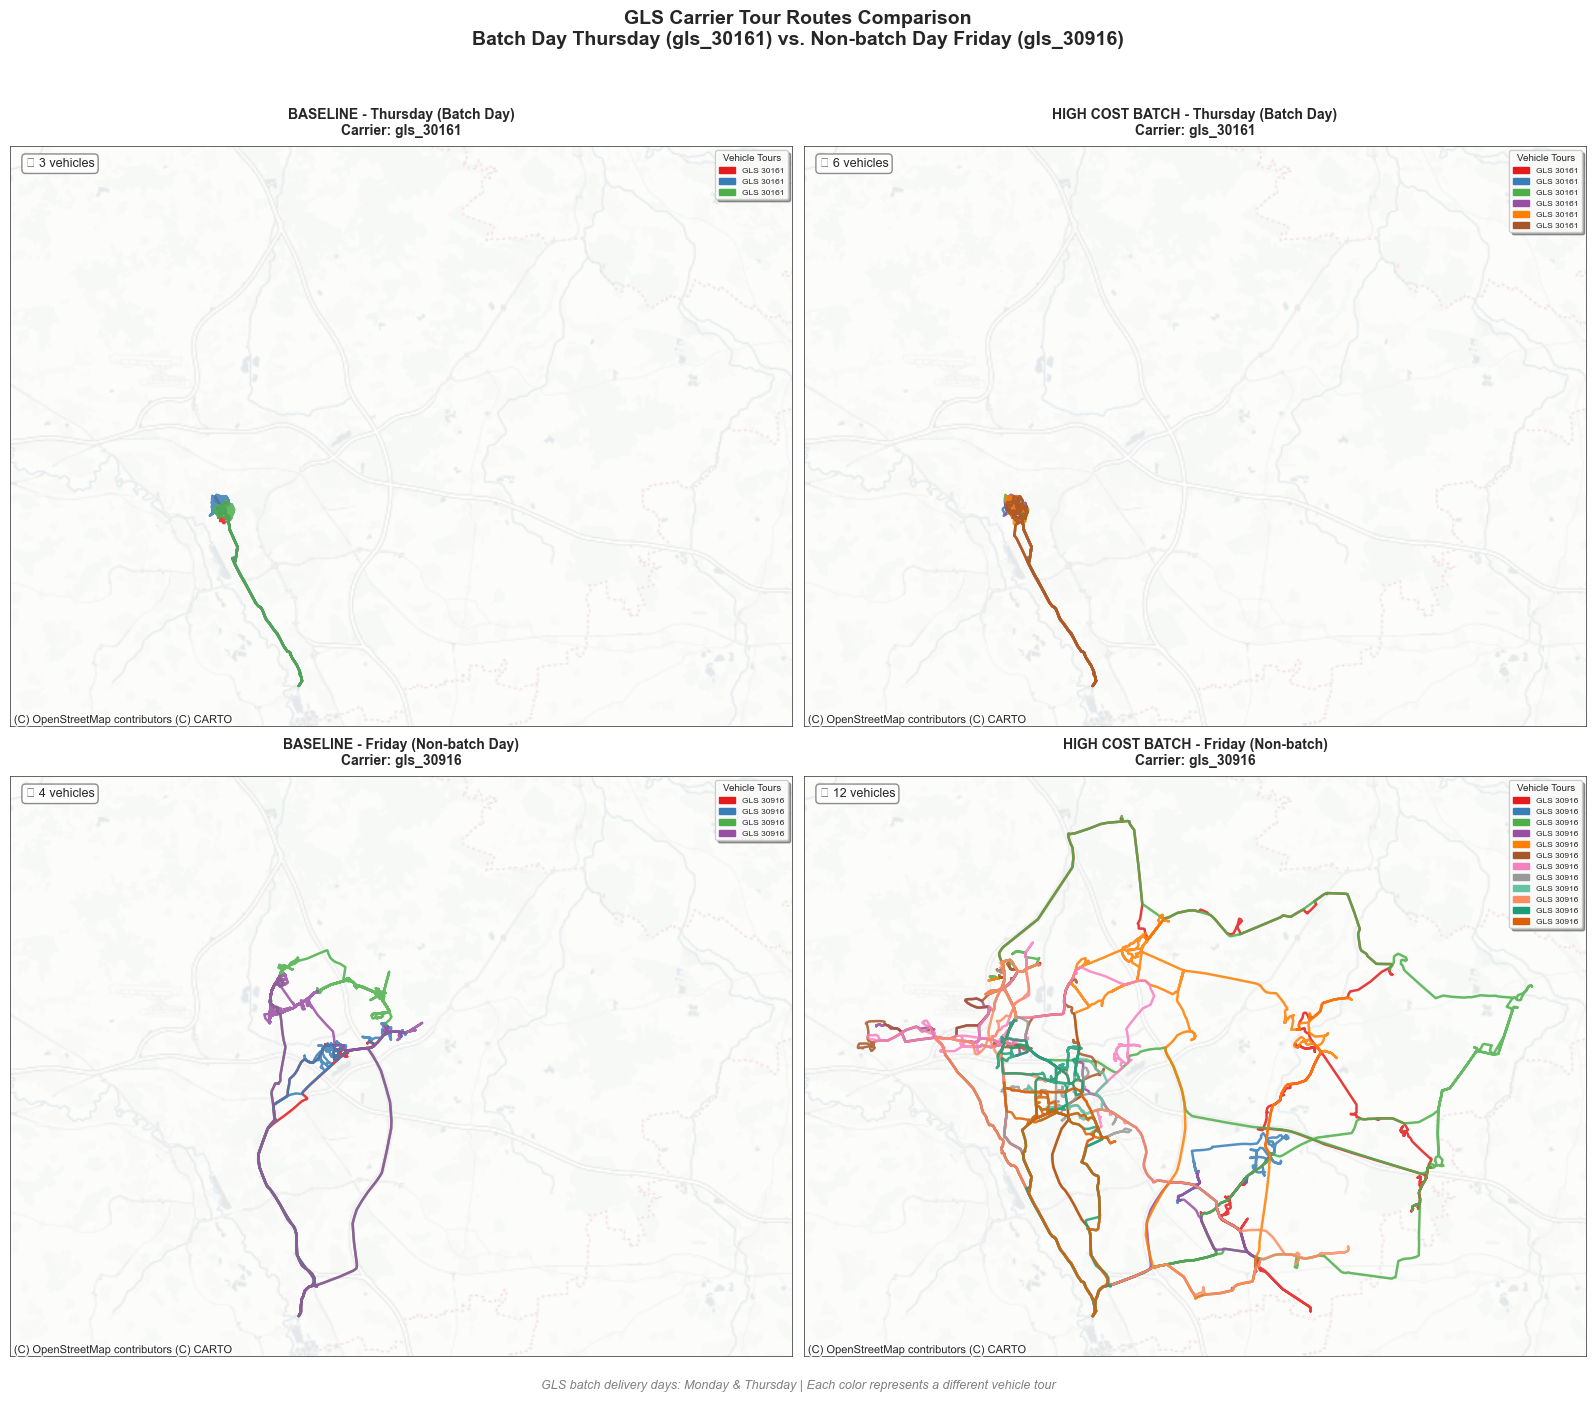


✓ Saved: tour_map_gls_thursday_friday_clean.png/pdf


In [29]:
# =============================================================================
# ENHANCED TOUR MAP WITH BASEMAP - Clean Routes Only
# Light gray basemap, no stops, consistent map extent across all scenarios
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, LineString
import contextily as ctx
from pyproj import Transformer

# --- Convert EPSG:25832 to Web Mercator (EPSG:3857) for basemap ---
transformer_to_wm = Transformer.from_crs("EPSG:25832", "EPSG:3857", always_xy=True)
transformer_to_wgs = Transformer.from_crs("EPSG:25832", "EPSG:4326", always_xy=True)

def transform_coords_to_webmercator(x_arr, y_arr):
    """Transform coordinates from EPSG:25832 to EPSG:3857 (Web Mercator)."""
    x_wm, y_wm = transformer_to_wm.transform(x_arr, y_arr)
    return np.array(x_wm), np.array(y_wm)


# --- First pass: Calculate global extent from Baseline Thursday ---
def get_scenario_bounds(df):
    """Get bounds of a scenario in Web Mercator coordinates."""
    if df.empty:
        return None
    
    all_x_wm, all_y_wm = [], []
    vehicles = df['vehicle_id'].unique()
    
    for vehicle in vehicles:
        veh_df = df[df['vehicle_id'] == vehicle].sort_values('time')
        if len(veh_df) < 2:
            continue
        x_coords = veh_df['x'].values
        y_coords = veh_df['y'].values
        x_wm, y_wm = transform_coords_to_webmercator(x_coords, y_coords)
        all_x_wm.extend(x_wm)
        all_y_wm.extend(y_wm)
    
    if not all_x_wm:
        return None
    
    return {
        'x_min': min(all_x_wm), 'x_max': max(all_x_wm),
        'y_min': min(all_y_wm), 'y_max': max(all_y_wm)
    }

# Get bounds from all scenarios and combine them
all_bounds = []
for scenario_name, df in all_tours.items():
    bounds = get_scenario_bounds(df)
    if bounds:
        all_bounds.append(bounds)

# Calculate combined global extent
if all_bounds:
    GLOBAL_X_MIN = min(b['x_min'] for b in all_bounds)
    GLOBAL_X_MAX = max(b['x_max'] for b in all_bounds)
    GLOBAL_Y_MIN = min(b['y_min'] for b in all_bounds)
    GLOBAL_Y_MAX = max(b['y_max'] for b in all_bounds)
    
    # Add 8% padding
    x_pad = (GLOBAL_X_MAX - GLOBAL_X_MIN) * 0.08
    y_pad = (GLOBAL_Y_MAX - GLOBAL_Y_MIN) * 0.08
    
    GLOBAL_X_MIN -= x_pad
    GLOBAL_X_MAX += x_pad
    GLOBAL_Y_MIN -= y_pad
    GLOBAL_Y_MAX += y_pad

print(f"Global map extent (Web Mercator):")
print(f"  X: {GLOBAL_X_MIN:.0f} to {GLOBAL_X_MAX:.0f}")
print(f"  Y: {GLOBAL_Y_MIN:.0f} to {GLOBAL_Y_MAX:.0f}")


def plot_tour_routes_clean(ax, df, title, show_legend=True):
    """
    Plot vehicle tour routes - ROUTES ONLY, no stops.
    Light gray basemap, consistent extent across all plots.
    """
    if df.empty:
        ax.text(0.5, 0.5, "No data available", ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='gray')
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xticks([])
        ax.set_yticks([])
        # Still set the global extent for empty plots
        ax.set_xlim(GLOBAL_X_MIN, GLOBAL_X_MAX)
        ax.set_ylim(GLOBAL_Y_MIN, GLOBAL_Y_MAX)
        try:
            ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.PositronNoLabels, 
                            alpha=0.6, zorder=1)
        except:
            pass
        return
    
    # Get unique vehicles
    vehicles = sorted(df['vehicle_id'].unique())
    
    # Create color mapping with more distinct colors
    colors_palette = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00', 
                      '#a65628', '#f781bf', '#999999', '#66c2a5', '#fc8d62',
                      '#1b9e77', '#d95f02', '#7570b3']
    color_map = {v: colors_palette[i % len(colors_palette)] for i, v in enumerate(vehicles)}
    
    # Plot each vehicle's tour - ROUTES ONLY
    legend_handles = []
    
    for vehicle in vehicles:
        veh_df = df[df['vehicle_id'] == vehicle].sort_values('time')
        
        if len(veh_df) < 2:
            continue
        
        # Get coordinates and transform to Web Mercator
        x_coords = veh_df['x'].values
        y_coords = veh_df['y'].values
        x_wm, y_wm = transform_coords_to_webmercator(x_coords, y_coords)
        
        # Short vehicle name for legend
        short_name = vehicle.split('_veh_')[0].replace('freight_gls_', 'GLS ').replace('_', ' ')
        
        # Plot route as connected line segments - ONLY LINES, NO MARKERS
        color = color_map[vehicle]
        ax.plot(x_wm, y_wm, '-', color=color, alpha=0.85, linewidth=1.8, 
                label=short_name, zorder=3)
        
        legend_handles.append(mpatches.Patch(color=color, label=short_name))
    
    # Set GLOBAL axis limits (same for all plots)
    ax.set_xlim(GLOBAL_X_MIN, GLOBAL_X_MAX)
    ax.set_ylim(GLOBAL_Y_MIN, GLOBAL_Y_MAX)
    
    # Add light gray basemap
    try:
        ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.PositronNoLabels, 
                        alpha=0.6, zorder=1)
    except Exception as e:
        print(f"[WARN] Could not add basemap: {e}")
    
    # Set title
    ax.set_title(title, fontsize=10, fontweight='bold', pad=8)
    
    # Hide axis labels
    ax.set_xticks([])
    ax.set_yticks([])
    
    # Add legend
    if show_legend and legend_handles:
        ax.legend(handles=legend_handles, loc='upper right', fontsize=6, 
                  framealpha=0.95, title='Vehicle Tours', title_fontsize=7,
                  fancybox=True, shadow=True)
    
    # Add stats annotation
    n_vehicles = len(vehicles)
    stats_text = f"🚚 {n_vehicles} vehicles"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', fontfamily='sans-serif',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='gray'))


# --- Create enhanced 2x2 plot with consistent extent ---
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Define what to plot in each subplot
plot_configs = [
    (axes[0, 0], "Baseline Thursday", 
     f"BASELINE - Thursday (Batch Day)\nCarrier: {CARRIER_ID_THURSDAY}"),
    (axes[0, 1], "High Cost Thursday", 
     f"HIGH COST BATCH - Thursday (Batch Day)\nCarrier: {CARRIER_ID_THURSDAY}"),
    (axes[1, 0], "Baseline Friday", 
     f"BASELINE - Friday (Non-batch Day)\nCarrier: {CARRIER_ID_FRIDAY}"),
    (axes[1, 1], "High Cost Friday", 
     f"HIGH COST BATCH - Friday (Non-batch)\nCarrier: {CARRIER_ID_FRIDAY}"),
]

for ax, scenario_key, title in plot_configs:
    df_plot = all_tours.get(scenario_key, pd.DataFrame())
    plot_tour_routes_clean(ax, df_plot, title)

# Overall title
fig.suptitle(f'GLS Carrier Tour Routes Comparison\n'
             f'Batch Day Thursday ({CARRIER_ID_THURSDAY}) vs. Non-batch Day Friday ({CARRIER_ID_FRIDAY})',
             fontsize=14, fontweight='bold', y=0.995)

# Add explanatory text
fig.text(0.5, 0.01, 
         "GLS batch delivery days: Monday & Thursday | Each color represents a different vehicle tour",
         ha='center', fontsize=9, style='italic', color='gray')

plt.tight_layout(rect=[0, 0.025, 1, 0.97])
plt.savefig(f"tour_map_gls_thursday_friday_clean.png", dpi=250, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.savefig(f"tour_map_gls_thursday_friday_clean.pdf", dpi=250, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: tour_map_gls_thursday_friday_clean.png/pdf")

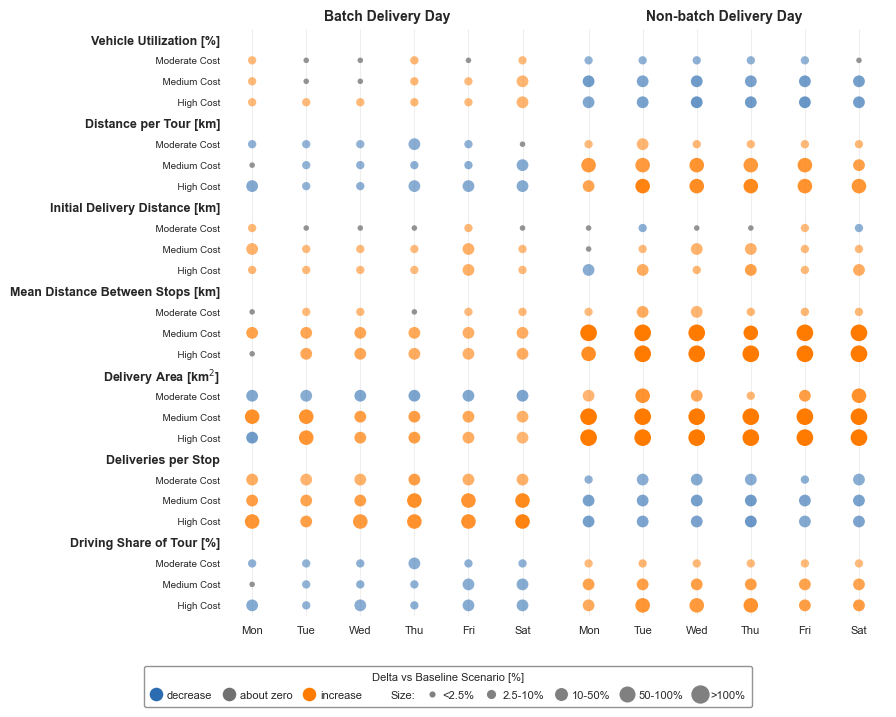

✓ Bubble plot saved: kpi_bubble_overview_active_vs_inactive.pdf/png


In [36]:
# =============================================================================
# BUBBLE PLOT: KPI Delta Overview (Batch vs Non-batch Days)
# Bubble size = magnitude of delta, color = direction (increase/decrease)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
import re

# -----------------------------
# Plot settings: scenarios without baseline
# -----------------------------
scen_order_pref_bub = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
present_scens_bub = pct_tbl["scenario"].astype(str).unique().tolist()
scenarios_all_bub = [s for s in scen_order_pref_bub if s in present_scens_bub] or sorted(present_scens_bub)
scenarios_plot_bub = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] if s in scenarios_all_bub]
scenario_display_bub = {"batchmoderate": "Moderate Cost", "batchmedium": "Medium Cost", "batchhigh": "High Cost"}

sns.set_style("whitegrid")

# -----------------------------
# Visual encoding
# -----------------------------
NEUTRAL_BAND_BUB = 2.5
COLOR_NEG_BUB = "#2b6cb0"  # Blue for decrease
COLOR_NEU_BUB = "#707070"  # Gray for neutral
COLOR_POS_BUB = "#ff7b00"  # Orange for increase
SIZE_CAP_BUB = 100.0

# Constants for bubble sizes
MIN_SIZE_BUB = 4
MAX_SIZE_BUB = 12
BIN_RADII_BUB = [MIN_SIZE_BUB, 6, 8.5, 10.5, MAX_SIZE_BUB]
THRESHOLDS_BUB = [2.5, 10.0, 50.0, 100.0]


def color_for_delta_bub(x: float):
    """Return (facecolor, edgecolor, filled_flag) with alpha scaled by |x|."""
    if not np.isfinite(x):
        return ("white", "0.5", False)

    a = abs(float(x))
    t = min(a / SIZE_CAP_BUB, 1.0)
    alpha = 0.5 + 0.5 * t

    if x < -NEUTRAL_BAND_BUB:
        base = COLOR_NEG_BUB
    elif x > NEUTRAL_BAND_BUB:
        base = COLOR_POS_BUB
    else:
        base = COLOR_NEU_BUB
        alpha = 0.75

    rgba = list(mcolors.to_rgba(base))
    rgba[3] = alpha
    return (tuple(rgba), "none", True)


def kpi_display_bub(name: str) -> str:
    if not isinstance(name, str):
        return str(name)
    if name.strip() in ("Delivery Area (km^2)", "Delivery Area (km²)"):
        return "Delivery Area [km$^2$]"
    m = re.match(r"^(.*)\s*\(([^)]+)\)\s*$", name.strip())
    if not m:
        return name
    base = m.group(1).strip()
    unit = m.group(2).strip().replace("km²", "km^2").replace("^2", "$^2$")
    return f"{base} [{unit}]"


def size_for_delta_bub(x: float) -> float:
    """Return bubble area using discrete bins."""
    if not np.isfinite(x):
        return float(BIN_RADII_BUB[0] ** 2)

    a = abs(float(x))
    if a < THRESHOLDS_BUB[0]:
        idx = 0
    elif a < THRESHOLDS_BUB[1]:
        idx = 1
    elif a < THRESHOLDS_BUB[2]:
        idx = 2
    elif a <= THRESHOLDS_BUB[3]:
        idx = 3
    else:
        idx = 4

    return float(BIN_RADII_BUB[idx] ** 2)


def plot_panel_bub(ax, df_group, title, kpis_list, scenarios_list):
    """Plot bubble panel for one activity group."""
    rows, is_header = [], []
    for k in kpis_list:
        rows.append((k, None))
        is_header.append(True)
        for s in scenarios_list:
            rows.append((k, s))
            is_header.append(False)

    n_rows = len(rows)
    n_cols = len(weekday_order)

    xs, ys, ss = [], [], []
    facecols, edgecols, filled_flags = [], [], []

    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_group[df_group["scenario"] == s]
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan
            sz = size_for_delta_bub(val)
            fc, ec, filled = color_for_delta_bub(val)
            xs.append(c_idx)
            ys.append(r_idx)
            ss.append(sz)
            facecols.append(fc)
            edgecols.append(ec)
            filled_flags.append(bool(filled))

    xs = np.array(xs)
    ys = np.array(ys)
    ss = np.array(ss)
    facecols = mcolors.to_rgba_array(facecols)
    edgecols = np.array(edgecols, dtype=object)
    filled_flags = np.array(filled_flags, dtype=bool)

    # Draw hollow (NaN) then filled
    mask_hollow = ~filled_flags
    if mask_hollow.any():
        ax.scatter(xs[mask_hollow], ys[mask_hollow], s=ss[mask_hollow],
                   facecolors="white", edgecolors=edgecols[mask_hollow], linewidths=0.9)

    mask_filled = ~mask_hollow
    if mask_filled.any():
        ax.scatter(xs[mask_filled], ys[mask_filled], s=ss[mask_filled],
                   facecolors=facecols[mask_filled], edgecolors="none")

    # Axis setup
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels, fontsize=8)

    yticklabels = []
    for (k, s), hdr in zip(rows, is_header):
        if hdr:
            yticklabels.append(kpi_display_bub(k))
        else:
            yticklabels.append("  " + scenario_display_bub.get(str(s), str(s)))
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(yticklabels, fontsize=7)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, len(rows) - 0.5)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)

    for lbl, hdr in zip(ax.get_yticklabels(), is_header):
        if hdr:
            lbl.set_fontweight("bold")
            lbl.set_fontsize(9)

    ax.set_axisbelow(True)
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=10, pad=6, weight="bold")
    ax.grid(False)
    ax.grid(axis="x", alpha=0.3)
    ax.yaxis.grid(False)


# -----------------------------
# Build figure with two panels: Active vs Not active
# -----------------------------
present_groups_bub = list(pct_tbl["activity_group"].unique())
if not present_groups_bub:
    raise RuntimeError("No activity groups found in pct_tbl.")

fig_w_bub, fig_h_bub = 9.0, 6.5
fig_bub, axes_bub = plt.subplots(1, len(present_groups_bub), figsize=(fig_w_bub, fig_h_bub))
if len(present_groups_bub) == 1:
    axes_bub = np.array([axes_bub])

plt.subplots_adjust(top=0.88, bottom=0.25, left=0.08, right=0.95, wspace=0.25)

for j, g in enumerate(present_groups_bub):
    ax = axes_bub[j]
    df_g_bub = pct_tbl[pct_tbl["activity_group"] == g]
    plot_panel_bub(ax, df_g_bub, g, kpis, scenarios_plot_bub)
    if j != 0:
        ax.set_yticklabels([])


# Legend function
def make_bubble_legend_single_row_bub(
    fig,
    color_items=None,
    size_labels=("<2.5%", "2.5-10%", "10-50%", "50-100%", ">100%"),
    separator_label="Size:",
    y_bottom=-0.10,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
):
    if color_items is None:
        color_items = [
            ("decrease", COLOR_NEG_BUB, False),
            ("about zero", COLOR_NEU_BUB, False),
            ("increase", COLOR_POS_BUB, False),
        ]

    handles, labels = [], []

    ms_color = BIN_RADII_BUB[2] * scale_colors
    for lab, col, hollow in color_items:
        h = Line2D([0], [0], marker="o", linestyle="None",
                   markersize=ms_color,
                   markerfacecolor=("white" if hollow else col),
                   markeredgecolor=("0.5" if hollow else "none"),
                   markeredgewidth=(1.0 if hollow else 0.0))
        handles.append(h)
        labels.append(lab)

    handles.append(Line2D([], [], linestyle="None"))
    labels.append(separator_label)

    for r, lab in zip(BIN_RADII_BUB, size_labels):
        h = Line2D([0], [0], marker="o", linestyle="None",
                   markersize=(r * scale_sizes),
                   markerfacecolor="#808080",
                   markeredgecolor="none")
        handles.append(h)
        labels.append(lab)

    leg = fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, y_bottom),
        ncol=len(labels),
        frameon=True, fancybox=True, framealpha=0.85,
        edgecolor="0.5", fontsize=8, title=legend_title,
        handlelength=1.0, handletextpad=0.5, columnspacing=1.0,
        borderpad=0.6, labelspacing=0.7
    )
    return leg


make_bubble_legend_single_row_bub(
    fig_bub,
    color_items=[
        ("decrease", COLOR_NEG_BUB, False),
        ("about zero", COLOR_NEU_BUB, False),
        ("increase", COLOR_POS_BUB, False),
    ],
    separator_label="Size:",
    y_bottom=-0.10,
    scale_colors=1.15,
    scale_sizes=1.10,
    legend_title="Delta vs Baseline Scenario [%]"
)

plt.tight_layout()
fig_bub.savefig("kpi_bubble_overview_active_vs_inactive.pdf", dpi=300, bbox_inches="tight")
fig_bub.savefig("kpi_bubble_overview_active_vs_inactive.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Bubble plot saved: kpi_bubble_overview_active_vs_inactive.pdf/png")

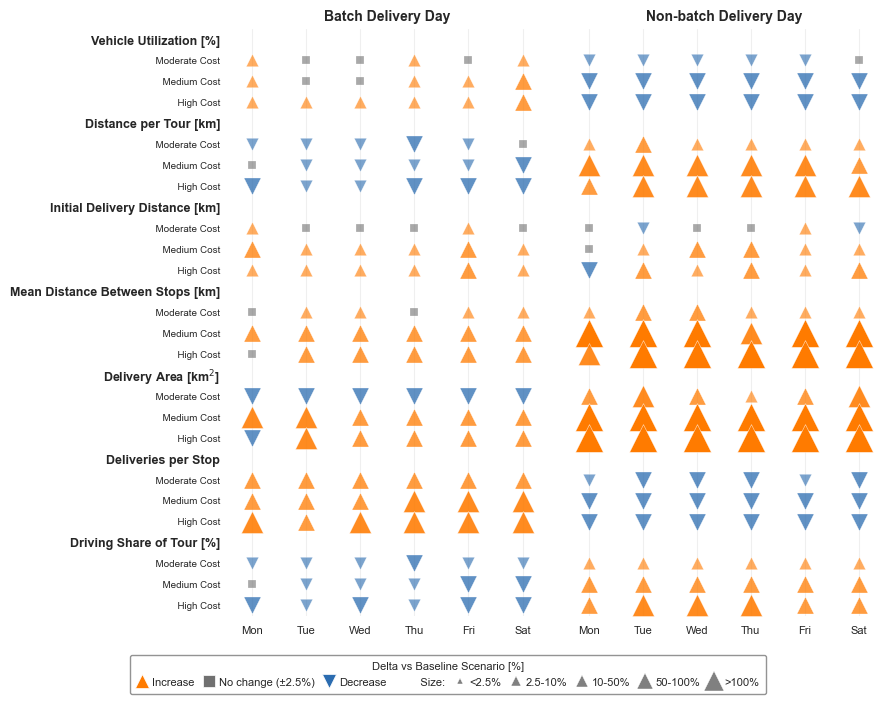

✓ Arrow plot saved: kpi_arrow_overview_active_vs_inactive.pdf/png


In [38]:
# =============================================================================
# ARROW PLOT: KPI Delta Overview mit Pfeilen (▲/▼) statt Bubbles
# Pfeil-Richtung = increase/decrease, Größe = Stärke der Änderung
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
import re

# -----------------------------
# Plot settings
# -----------------------------
scen_order_pref_arr = ["basecase", "batchmoderate", "batchmedium", "batchhigh"]
present_scens_arr = pct_tbl["scenario"].astype(str).unique().tolist()
scenarios_all_arr = [s for s in scen_order_pref_arr if s in present_scens_arr] or sorted(present_scens_arr)
scenarios_plot_arr = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] if s in scenarios_all_arr]
scenario_display_arr = {"batchmoderate": "Moderate Cost", "batchmedium": "Medium Cost", "batchhigh": "High Cost"}

sns.set_style("whitegrid")

# -----------------------------
# Visual encoding - Farben
# -----------------------------
NEUTRAL_BAND_ARR = 2.5
COLOR_DOWN_ARR = "#2b6cb0"   # Blau für Abnahme
COLOR_NEU_ARR = "#707070"    # Grau für neutral
COLOR_UP_ARR = "#ff7b00"     # Orange für Zunahme

# Größen-Stufen für Pfeile (Marker-Größe in points²)
SIZE_BINS_ARR = [2.5, 10.0, 50.0, 100.0]  # Schwellen in %
ARROW_SIZES_ARR = [30, 80, 150, 250, 400]  # Fläche für scatter (s parameter)


def get_arrow_props(x: float):
    """
    Bestimme Marker, Farbe und Größe basierend auf Delta-Wert.
    Returns: (marker, color, size, alpha)
    """
    if not np.isfinite(x):
        return ("o", "lightgray", 20, 0.3)  # Kleiner grauer Punkt für NaN
    
    a = abs(float(x))
    
    # Größen-Bin bestimmen
    if a < SIZE_BINS_ARR[0]:
        size_idx = 0
    elif a < SIZE_BINS_ARR[1]:
        size_idx = 1
    elif a < SIZE_BINS_ARR[2]:
        size_idx = 2
    elif a <= SIZE_BINS_ARR[3]:
        size_idx = 3
    else:
        size_idx = 4
    
    size = ARROW_SIZES_ARR[size_idx]
    
    # Alpha basierend auf Größe (stärkere Änderung = mehr opak)
    alpha = 0.5 + 0.5 * (size_idx / 4)
    
    # Richtung und Farbe
    if x < -NEUTRAL_BAND_ARR:
        marker = "v"  # Dreieck nach unten = Abnahme
        color = COLOR_DOWN_ARR
    elif x > NEUTRAL_BAND_ARR:
        marker = "^"  # Dreieck nach oben = Zunahme
        color = COLOR_UP_ARR
    else:
        marker = "s"  # Quadrat für neutral/keine Änderung
        color = COLOR_NEU_ARR
        alpha = 0.6
    
    return (marker, color, size, alpha)


def kpi_display_arr(name: str) -> str:
    if not isinstance(name, str):
        return str(name)
    if name.strip() in ("Delivery Area (km^2)", "Delivery Area (km²)"):
        return "Delivery Area [km$^2$]"
    m = re.match(r"^(.*)\s*\(([^)]+)\)\s*$", name.strip())
    if not m:
        return name
    base = m.group(1).strip()
    unit = m.group(2).strip().replace("km²", "km^2").replace("^2", "$^2$")
    return f"{base} [{unit}]"


def plot_panel_arrows(ax, df_group, title, kpis_list, scenarios_list):
    """Plot arrow panel for one activity group."""
    rows, is_header = [], []
    for k in kpis_list:
        rows.append((k, None))
        is_header.append(True)
        for s in scenarios_list:
            rows.append((k, s))
            is_header.append(False)

    n_rows = len(rows)
    n_cols = len(weekday_order)

    # Sammle alle Punkte nach Marker-Typ
    points_by_marker = {}  # marker -> {xs, ys, sizes, colors, alphas}

    for r_idx, (k, s) in enumerate(rows):
        if s is None:
            continue
        sub = df_group[df_group["scenario"] == s]
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, k]
            val = float(series.mean()) if not series.empty else np.nan
            
            marker, color, size, alpha = get_arrow_props(val)
            
            if marker not in points_by_marker:
                points_by_marker[marker] = {"xs": [], "ys": [], "sizes": [], "colors": [], "alphas": []}
            
            points_by_marker[marker]["xs"].append(c_idx)
            points_by_marker[marker]["ys"].append(r_idx)
            points_by_marker[marker]["sizes"].append(size)
            points_by_marker[marker]["colors"].append(color)
            points_by_marker[marker]["alphas"].append(alpha)

    # Zeichne jeden Marker-Typ separat
    for marker, data in points_by_marker.items():
        xs = np.array(data["xs"])
        ys = np.array(data["ys"])
        sizes = np.array(data["sizes"])
        colors = data["colors"]
        alphas = data["alphas"]
        
        # Gruppiere nach (color, alpha) für effizienten Plot
        for i in range(len(xs)):
            ax.scatter(xs[i], ys[i], s=sizes[i], c=colors[i], 
                      marker=marker, alpha=alphas[i], edgecolors="white", linewidths=0.3)

    # Axis setup
    ax.set_xticks(np.arange(n_cols))
    ax.set_xticklabels(weekday_labels, fontsize=8)

    yticklabels = []
    for (k, s), hdr in zip(rows, is_header):
        if hdr:
            yticklabels.append(kpi_display_arr(k))
        else:
            yticklabels.append("  " + scenario_display_arr.get(str(s), str(s)))
    ax.set_yticks(np.arange(len(rows)))
    ax.set_yticklabels(yticklabels, fontsize=7)

    ax.set_xlim(-0.5, n_cols - 0.5)
    ax.set_ylim(-0.5, len(rows) - 0.5)
    ax.invert_yaxis()
    ax.tick_params(axis="y", length=0)

    for lbl, hdr in zip(ax.get_yticklabels(), is_header):
        if hdr:
            lbl.set_fontweight("bold")
            lbl.set_fontsize(9)

    ax.set_axisbelow(True)
    ax.set_frame_on(False)
    ax.set_title(title, fontsize=10, pad=6, weight="bold")
    ax.grid(False)
    ax.grid(axis="x", alpha=0.3)
    ax.yaxis.grid(False)


# -----------------------------
# Build figure with two panels
# -----------------------------
present_groups_arr = list(pct_tbl["activity_group"].unique())
if not present_groups_arr:
    raise RuntimeError("No activity groups found in pct_tbl.")

fig_w_arr, fig_h_arr = 9.0, 6.5
fig_arr, axes_arr = plt.subplots(1, len(present_groups_arr), figsize=(fig_w_arr, fig_h_arr))
if len(present_groups_arr) == 1:
    axes_arr = np.array([axes_arr])

plt.subplots_adjust(top=0.88, bottom=0.20, left=0.08, right=0.95, wspace=0.25)

for j, g in enumerate(present_groups_arr):
    ax = axes_arr[j]
    df_g_arr = pct_tbl[pct_tbl["activity_group"] == g]
    plot_panel_arrows(ax, df_g_arr, g, kpis, scenarios_plot_arr)
    if j != 0:
        ax.set_yticklabels([])


# -----------------------------
# Legend mit Pfeilen
# -----------------------------
def make_arrow_legend(fig, y_bottom=-0.08):
    handles, labels = [], []
    
    # Richtung (Pfeil-Typ)
    handles.append(Line2D([0], [0], marker="^", linestyle="None", markersize=10,
                         markerfacecolor=COLOR_UP_ARR, markeredgecolor="white", markeredgewidth=0.5))
    labels.append("Increase")
    
    handles.append(Line2D([0], [0], marker="s", linestyle="None", markersize=8,
                         markerfacecolor=COLOR_NEU_ARR, markeredgecolor="white", markeredgewidth=0.5))
    labels.append("No change (±2.5%)")
    
    handles.append(Line2D([0], [0], marker="v", linestyle="None", markersize=10,
                         markerfacecolor=COLOR_DOWN_ARR, markeredgecolor="white", markeredgewidth=0.5))
    labels.append("Decrease")
    
    # Separator
    handles.append(Line2D([], [], linestyle="None"))
    labels.append("   Size:")
    
    # Größen-Legende
    size_labels = ["<2.5%", "2.5-10%", "10-50%", "50-100%", ">100%"]
    size_markers = [5, 7, 9, 11, 14]  # markersize (sqrt of area roughly)
    
    for ms, lab in zip(size_markers, size_labels):
        handles.append(Line2D([0], [0], marker="^", linestyle="None", markersize=ms,
                             markerfacecolor="#808080", markeredgecolor="white", markeredgewidth=0.3))
        labels.append(lab)
    
    leg = fig.legend(
        handles, labels,
        loc="lower center", bbox_to_anchor=(0.5, y_bottom),
        ncol=len(labels),
        frameon=True, fancybox=True, framealpha=0.85,
        edgecolor="0.5", fontsize=8, title="Delta vs Baseline Scenario [%]",
        handlelength=1.0, handletextpad=0.4, columnspacing=0.8,
        borderpad=0.6
    )
    return leg


make_arrow_legend(fig_arr, y_bottom=-0.08)

plt.tight_layout()
fig_arr.savefig("kpi_arrow_overview_active_vs_inactive.pdf", dpi=300, bbox_inches="tight")
fig_arr.savefig("kpi_arrow_overview_active_vs_inactive.png", dpi=300, bbox_inches="tight")
plt.show()
print("✓ Arrow plot saved: kpi_arrow_overview_active_vs_inactive.pdf/png")

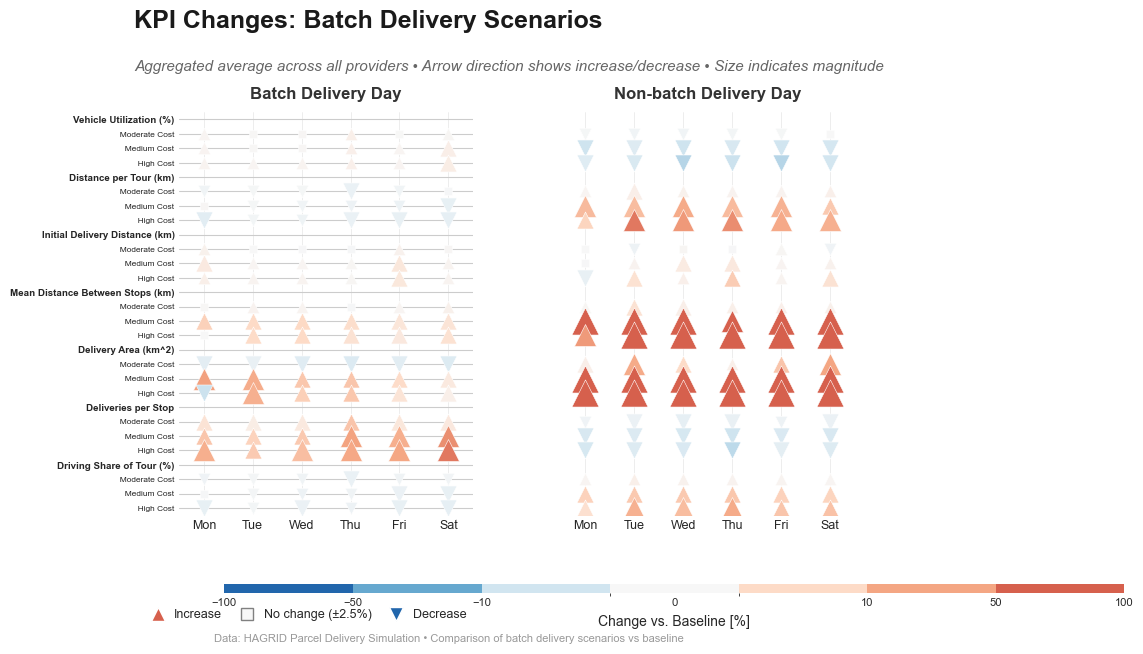

✓ Stylish arrow plot saved: kpi_stylish_arrow_overview.pdf/png


In [40]:
# =============================================================================
# STYLISH ARROW CHART: Aggregated KPI Deltas (All Providers Average)
# Inspired by data visualization best practices
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import re

# -----------------------------
# Aggregiere über alle Provider (Durchschnitt)
# -----------------------------
# pct_tbl enthält bereits die Delta-Werte pro Scenario/Weekday/Activity_Group

# Aggregiere: Mittelwert über alle Einträge pro (scenario, weekday, activity_group)
agg_data_styled = pct_tbl.groupby(
    ["scenario", "weekday", "activity_group"], 
    as_index=False, observed=True
)[kpis].mean()

# Szenarien ohne Baseline
scenarios_styled = [s for s in ["batchmoderate", "batchmedium", "batchhigh"] 
                    if s in agg_data_styled["scenario"].unique()]
scenario_labels_styled = {
    "batchmoderate": "Moderate Cost", 
    "batchmedium": "Medium Cost", 
    "batchhigh": "High Cost"
}

# KPI Display Namen (kurz)
kpi_labels_styled = {
    'vehicle_utilization': 'Vehicle Util.',
    'distance_per_tour': 'Tour Distance',
    'initial_delivery_distance': 'Init. Delivery Dist.',
    'mean_distance_between_stops': 'Stop Distance',
    'delivery_area': 'Delivery Area',
    'deliveries_per_stop': 'Deliveries/Stop',
    'driving_share': 'Driving Share',
}

# Farben
CMAP_STYLED = mcolors.LinearSegmentedColormap.from_list(
    "diverging_blue_orange",
    ["#2166ac", "#67a9cf", "#d1e5f0", "#f7f7f7", "#fddbc7", "#f4a582", "#d6604d"]
)

# -----------------------------
# Create stylish figure
# -----------------------------
present_groups_styled = list(agg_data_styled["activity_group"].unique())
n_groups = len(present_groups_styled)

fig_styled = plt.figure(figsize=(9.0, 6.5), facecolor='white')

# Title and subtitle space
fig_styled.subplots_adjust(top=0.82, bottom=0.20, left=0.20, right=0.95, wspace=0.3)

# Create axes for each group
axes_styled = []
for i, grp in enumerate(present_groups_styled):
    ax = fig_styled.add_subplot(1, n_groups, i + 1)
    axes_styled.append(ax)

# Prepare data matrix for heatmap-style arrows
for ax_idx, (ax, grp) in enumerate(zip(axes_styled, present_groups_styled)):
    grp_data = agg_data_styled[agg_data_styled["activity_group"] == grp]
    
    # Build matrix: rows = (KPI, Scenario), cols = Weekday
    row_labels = []
    row_types = []  # 'header' or 'data'
    
    for kpi in kpis:
        row_labels.append(kpi_labels_styled.get(kpi, kpi))
        row_types.append('header')
        for scen in scenarios_styled:
            row_labels.append(f"  {scenario_labels_styled.get(scen, scen)}")
            row_types.append('data')
    
    n_rows_styled = len(row_labels)
    n_cols_styled = len(weekday_order)
    
    # Plot arrows
    for r_idx, (kpi_idx, scen_idx) in enumerate([
        (k_i, s_i) 
        for k_i, kpi in enumerate(kpis) 
        for s_i, scen in enumerate([None] + scenarios_styled)
    ]):
        if scen_idx == 0:  # Header row (KPI name)
            continue
        
        kpi = kpis[kpi_idx]
        scen = scenarios_styled[scen_idx - 1]
        
        sub = grp_data[(grp_data["scenario"] == scen)]
        
        for c_idx, wd in enumerate(weekday_order):
            series = sub.loc[sub["weekday"] == wd, kpi]
            val = float(series.mean()) if not series.empty else np.nan
            
            if not np.isfinite(val):
                continue
            
            # Determine marker and color
            abs_val = abs(val)
            
            # Size based on magnitude
            if abs_val < 2.5:
                size = 40
            elif abs_val < 10:
                size = 80
            elif abs_val < 50:
                size = 150
            elif abs_val <= 100:
                size = 250
            else:
                size = 380
            
            # Color intensity based on value
            norm_val = np.clip(val / 100, -1, 1)  # Normalize to [-1, 1]
            color = CMAP_STYLED((norm_val + 1) / 2)  # Map to [0, 1] for colormap
            
            # Marker
            if val < -2.5:
                marker = "v"  # Down arrow
            elif val > 2.5:
                marker = "^"  # Up arrow
            else:
                marker = "s"  # Square for neutral
            
            ax.scatter(c_idx, r_idx, s=size, c=[color], marker=marker, 
                      edgecolors="white", linewidths=0.4, zorder=3)
    
    # Axis setup
    ax.set_xticks(np.arange(n_cols_styled))
    ax.set_xticklabels(weekday_labels, fontsize=9, fontweight='medium')
    
    if ax_idx == 0:
        ax.set_yticks(np.arange(len(row_labels)))
        ax.set_yticklabels(row_labels, fontsize=6)
        # Bold the KPI headers
        for i, (lbl, typ) in enumerate(zip(ax.get_yticklabels(), row_types)):
            if typ == 'header':
                lbl.set_fontweight('bold')
                lbl.set_fontsize(7)
    else:
        ax.set_yticks([])
    
    ax.set_xlim(-0.5, n_cols_styled - 0.5)
    ax.set_ylim(-0.5, len(row_labels) - 0.5)
    ax.invert_yaxis()
    
    # Styling
    ax.set_frame_on(False)
    ax.tick_params(axis='both', length=0)
    ax.grid(True, axis='x', alpha=0.2, color='gray', linestyle='-', linewidth=0.5)
    ax.set_axisbelow(True)
    
    # Panel title
    ax.set_title(grp, fontsize=12, fontweight='bold', pad=10, color='#333333')

# -----------------------------
# Add colorbar legend
# -----------------------------
cbaxes = inset_axes(
    axes_styled[0], 
    width="200%", 
    height="100%", 
    loc="center",
    bbox_to_anchor=(0.5, 0.08, 0.5, 0.015),
    bbox_transform=fig_styled.transFigure
)

# Discrete bounds for colorbar
bounds = [-100, -50, -10, -2.5, 2.5, 10, 50, 100]
norm_cb = mpl.colors.BoundaryNorm(bounds, CMAP_STYLED.N)

cb = fig_styled.colorbar(
    ScalarMappable(norm=norm_cb, cmap=CMAP_STYLED),
    cax=cbaxes,
    orientation="horizontal",
    ticks=[-100, -50, -10, 0, 10, 50, 100]
)
cb.outline.set_visible(False)
cb.ax.xaxis.set_tick_params(size=0)
cb.ax.tick_params(labelsize=8)
cb.set_label("Change vs. Baseline [%]", size=10, labelpad=5)

# -----------------------------
# Add marker legend
# -----------------------------
legend_handles = [
    Line2D([0], [0], marker="^", linestyle="None", markersize=10, 
           markerfacecolor="#d6604d", markeredgecolor="white", label="Increase"),
    Line2D([0], [0], marker="s", linestyle="None", markersize=8, 
           markerfacecolor="#f7f7f7", markeredgecolor="gray", label="No change (±2.5%)"),
    Line2D([0], [0], marker="v", linestyle="None", markersize=10, 
           markerfacecolor="#2166ac", markeredgecolor="white", label="Decrease"),
]

fig_styled.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.15, 0.02),
    ncol=3,
    frameon=False,
    fontsize=9,
    handletextpad=0.3,
    columnspacing=1.0
)

# -----------------------------
# Title and annotations
# -----------------------------
title_styled = "KPI Changes: Batch Delivery Scenarios"
subtitle_styled = "Aggregated average across all providers • Arrow direction shows increase/decrease • Size indicates magnitude"

fig_styled.text(0.15, 0.95, title_styled, fontsize=18, weight="bold", ha="left", va="baseline", color="#1a1a1a")
fig_styled.text(0.15, 0.90, subtitle_styled, fontsize=11, ha="left", va="top", color="#666666", style="italic")

# Caption
caption_styled = "Data: HAGRID Parcel Delivery Simulation • Comparison of batch delivery scenarios vs baseline"
fig_styled.text(0.5, 0.005, caption_styled, fontsize=8, ha="center", va="baseline", color="#999999")

# Save
fig_styled.savefig("kpi_stylish_arrow_overview.pdf", dpi=300, bbox_inches="tight", facecolor='white')
fig_styled.savefig("kpi_stylish_arrow_overview.png", dpi=300, bbox_inches="tight", facecolor='white')
plt.show()
print("✓ Stylish arrow plot saved: kpi_stylish_arrow_overview.pdf/png")

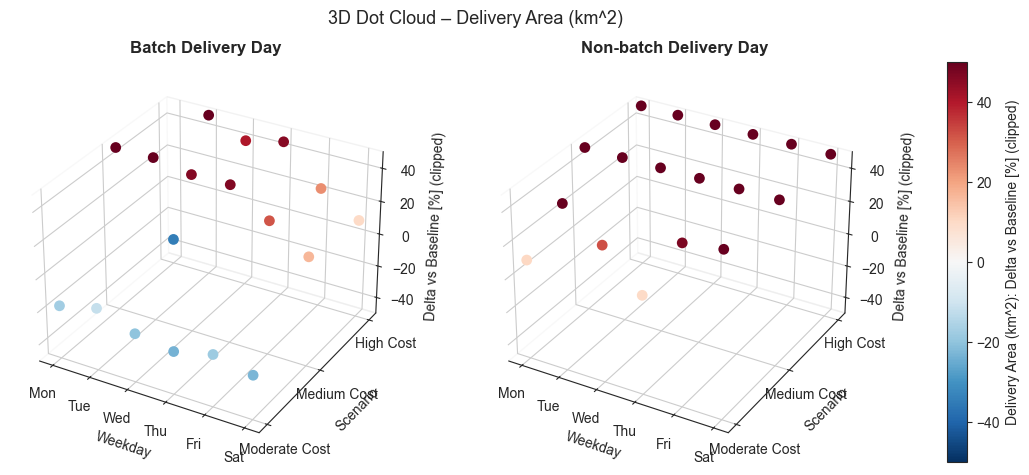

In [ ]:
# Alternative Plot (kreativ / "conference style"): 3D Dot Cloud
# x = weekday, y = scenario, z = Delta vs Baseline [%]
# Farbe = Delta vs Baseline [%] (clipped)
# -> pro activity_group eine 3D-Achse, für EIN ausgewähltes KPI

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --------- Settings ---------
KPI_3D = "Delivery Area (km^2)"  # <-- hier KPI wählen (muss in pct_tbl-Spalten existieren)
CAP_3D = 50.0                    # <-- clipping für Farbskala/Z-Achse (in %)
SCENARIOS_3D = scenarios_plot     # <-- oder z.B. ["batchmoderate","batchmedium","batchhigh"]

# Ordnung/Labels
wd_order = [wd for wd in weekday_order if wd in pct_tbl["weekday"].astype(str).unique()] or sorted(pct_tbl["weekday"].astype(str).unique())
wd_label_map = dict(zip(weekday_order, weekday_labels))
wd_tick_labels = [wd_label_map.get(wd, str(wd)[:3]) for wd in wd_order]

sc_order = [s for s in SCENARIOS_3D if s in pct_tbl["scenario"].astype(str).unique()] or sorted(pct_tbl["scenario"].astype(str).unique())
sc_tick_labels = [scenario_display.get(str(s), str(s)) for s in sc_order]

if KPI_3D not in pct_tbl.columns:
    raise RuntimeError(f"KPI_3D not found in pct_tbl columns: {KPI_3D}")

# Prepare data
plot_df = pct_tbl.copy()
plot_df["weekday"] = plot_df["weekday"].astype(str)
plot_df["scenario"] = plot_df["scenario"].astype(str)
plot_df["activity_group"] = plot_df["activity_group"].astype(str)
plot_df[KPI_3D] = pd.to_numeric(plot_df[KPI_3D], errors="coerce")

plot_df = plot_df[
    plot_df["weekday"].isin(wd_order)
    & plot_df["scenario"].isin([str(s) for s in sc_order])
]

groups = plot_df["activity_group"].unique().tolist()
if not groups:
    raise RuntimeError("No activity_group values found in pct_tbl.")

# 3D figure
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

n = len(groups)
fig = plt.figure(figsize=(6.2 * n, 5.2))

norm = mpl.colors.TwoSlopeNorm(vmin=-CAP_3D, vcenter=0.0, vmax=CAP_3D)
cmap = mpl.colormaps.get_cmap("RdBu_r")

for i, g in enumerate(groups, start=1):
    ax = fig.add_subplot(1, n, i, projection="3d")

    sub = plot_df[plot_df["activity_group"] == g].copy()

    # Map to numeric axes
    wd_to_x = {wd: j for j, wd in enumerate(wd_order)}
    sc_to_y = {sc: j for j, sc in enumerate(sc_order)}

    # One point per (scenario, weekday): take mean if duplicates exist
    grid = (
        sub.groupby(["scenario", "weekday"], dropna=False)[KPI_3D]
        .mean()
        .reset_index()
    )

    xs = grid["weekday"].map(wd_to_x).to_numpy(dtype=float)
    ys = grid["scenario"].map(sc_to_y).to_numpy(dtype=float)
    zs = grid[KPI_3D].to_numpy(dtype=float)

    # clip (both z and color) for readability
    zs_clip = np.clip(zs, -CAP_3D, CAP_3D)

    ax.scatter(
        xs,
        ys,
        zs_clip,
        c=zs_clip,
        cmap=cmap,
        norm=norm,
        s=60,
        depthshade=False,
        edgecolors="none",
    )

    ax.set_title(g, pad=10, fontsize=12, fontweight="bold")
    ax.set_xlabel("Weekday")
    ax.set_ylabel("Scenario")
    ax.set_zlabel("Delta vs Baseline [%] (clipped)")

    ax.set_xticks(range(len(wd_order)))
    ax.set_xticklabels(wd_tick_labels)

    ax.set_yticks(range(len(sc_order)))
    ax.set_yticklabels(sc_tick_labels)

    ax.set_zlim(-CAP_3D, CAP_3D)

    # make it a bit cleaner
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(True, alpha=0.25)

# Shared colorbar
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cb = fig.colorbar(sm, ax=fig.axes, fraction=0.025, pad=0.08)
cb.set_label(f"{KPI_3D}: Delta vs Baseline [%] (clipped)")

fig.suptitle(f"3D Dot Cloud – {KPI_3D}", y=0.98, fontsize=13)
plt.show()

## Carrier-/Provider-Vergleich (Batch-Day vs Non-Batch): mehrere Plot-Ideen
Diese Sektion erzeugt eine **provider-spezifische** Delta-Tabelle (`pct_tbl_provider`) und zeigt danach mehrere Visualisierungen, um KPIs **zwischen Carriern** und **zwischen Szenarien** zu vergleichen – jeweils getrennt nach `activity_group` (Batch Delivery Day vs Non-batch Delivery Day).

Wenn dir ein Plot gefällt, sag kurz welchen (A/B/C/D) – dann kann ich ihn noch „paper-ready“ stylen (Schriftgrößen, Export als PDF/SVG, etc.).

## WOW Plot: Fancy Radar Charts (KPIs)
Vergleicht KPI-Delta vs Baseline als **Radar** – mit **Batch Delivery Day vs Non-batch Delivery Day** ("online") pro Provider, je Szenario.

In [ ]:
# Fancy Radar Charts (Plotly)
# - Uses deltas vs baseline (pct_tbl_provider if available, otherwise builds it)
# - Each subplot = one scenario; traces = Batch vs Non-batch

import numpy as np
import pandas as pd

try:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
except Exception as e:
    raise RuntimeError("Plotly is required for this radar chart. Install plotly or switch to matplotlib.") from e

# --------------------
# Settings
# --------------------
PROVIDER_RADAR = "dhl"              # <- provider/carrier to show (lowercase)
SCENARIOS_RADAR = ["batchmoderate", "batchmedium", "batchhigh"]  # <- scenario order
KPIS_RADAR = [k for k in kpis if k in df.columns]                 # <- KPI list (uses existing 'kpis')
CAP_RADAR = 50.0                    # <- clipping for readability (in %)
AG_BATCH = "Batch Delivery Day"
AG_NONBATCH = "Non-batch Delivery Day"

# If you want fewer KPIs (often looks better), uncomment and edit:
# KPIS_RADAR = [
#     "Vehicle Utilization (%)",
#     "Distance per Tour (km)",
#     "Initial Delivery Distance (km)",
#     "Mean Distance Between Stops (km)",
#     "Delivery Area (km^2)",
#     "Deliveries per Stop",
# ]

# --------------------
# Ensure we have provider-level delta table
# --------------------
def _build_pct_tbl_provider_if_needed():
    if "pct_tbl_provider" in globals() and isinstance(globals()["pct_tbl_provider"], pd.DataFrame):
        return globals()["pct_tbl_provider"]

    # build from df (same logic as earlier cell, but compact)
    d = df.copy()
    if "provider" not in d.columns:
        if "logisticProvider" in d.columns:
            d["provider"] = d["logisticProvider"].astype(str).str.lower()
        elif "carrierID" in d.columns:
            d["provider"] = d["carrierID"].astype(str).str.lower()
        else:
            raise RuntimeError("No provider column found to build pct_tbl_provider.")
    d["provider"] = d["provider"].astype(str).str.strip().str.lower()

    if "activity_group" not in d.columns:
        def _is_active_row(row):
            prov = str(row.get("provider", "")).strip().lower()
            wd = str(row.get("weekday", "")).strip()
            return wd in provider_active_days.get(prov, set())
        d["active_flag"] = d.apply(_is_active_row, axis=1)
        d["activity_group"] = np.where(d["active_flag"], AG_BATCH, AG_NONBATCH)

    kpis_present = [k for k in KPIS_RADAR if k in d.columns]
    if not kpis_present:
        raise RuntimeError("No KPI columns available for radar.")
    for c in kpis_present:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    grp = ["provider", "activity_group", "weekday", "scenario"]
    if "run_name" in d.columns:
        per_run = d.groupby(grp + ["run_name"], dropna=False, observed=False)[kpis_present].mean().reset_index()
        scen_avg = per_run.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()
    else:
        scen_avg = d.groupby(grp, dropna=False, observed=False)[kpis_present].mean().reset_index()

    base = (
        scen_avg[scen_avg["scenario"].astype(str) == str(BASELINE)]
        .loc[:, ["provider", "activity_group", "weekday"] + kpis_present]
        .rename(columns={c: f"base__{c}" for c in kpis_present})
    )
    m = scen_avg.merge(base, on=["provider", "activity_group", "weekday"], how="left")
    for c in kpis_present:
        num = pd.to_numeric(m[c], errors="coerce")
        den = pd.to_numeric(m[f"base__{c}"], errors="coerce")
        m[c] = (num / den - 1.0) * 100.0
    m[kpis_present] = m[kpis_present].replace([np.inf, -np.inf], np.nan)
    out = m[["provider", "activity_group", "weekday", "scenario"] + kpis_present].copy()
    globals()["pct_tbl_provider"] = out
    return out

pct_tbl_provider = _build_pct_tbl_provider_if_needed()

# --------------------
# Prepare radar data (avg over weekdays) for chosen provider
# --------------------
p = str(PROVIDER_RADAR).strip().lower()
rad = pct_tbl_provider.copy()
rad["provider"] = rad["provider"].astype(str).str.lower()
rad = rad[rad["provider"] == p]

if rad.empty:
    present = sorted(pct_tbl_provider["provider"].astype(str).str.lower().unique().tolist())
    raise RuntimeError(f"Provider '{p}' not found. Try one of: {present[:20]} ...")

# scenarios present (keep order)
sc_present = [s for s in SCENARIOS_RADAR if s in rad["scenario"].astype(str).unique().tolist()]
if not sc_present:
    sc_present = sorted(rad["scenario"].astype(str).unique().tolist())

kpis_present = [k for k in KPIS_RADAR if k in rad.columns]
if not kpis_present:
    raise RuntimeError("None of KPIS_RADAR are present in pct_tbl_provider.")

# Aggregate over weekdays
agg = (
    rad.groupby(["scenario", "activity_group"], dropna=False, observed=False)[kpis_present]
    .mean()
    .reset_index()
)

# Helper: map delta [-CAP, CAP] -> radius [0, 1] (so we can show negative values nicely)
def _to_radius(delta):
    d = np.asarray(delta, dtype=float)
    d = np.clip(d, -CAP_RADAR, CAP_RADAR)
    return (d + CAP_RADAR) / (2.0 * CAP_RADAR)

theta = kpis_present
theta_closed = theta + [theta[0]]  # close polygon

# Build multi-polar subplot figure: one radar per scenario
fig = make_subplots(
    rows=1,
    cols=len(sc_present),
    specs=[[{"type": "polar"}] * len(sc_present)],
    subplot_titles=[scenario_display.get(s, s) for s in sc_present],
    horizontal_spacing=0.06,
)

# Styling ("WOW" look)
COL_BATCH = "rgba(255, 122, 0, 0.85)"     # warm orange
COL_NONB = "rgba(43, 108, 176, 0.85)"     # cool blue
FILL_BATCH = "rgba(255, 122, 0, 0.22)"
FILL_NONB = "rgba(43, 108, 176, 0.22)"

for j, scen in enumerate(sc_present, start=1):
    for ag, name, line_col, fill_col in [
        (AG_BATCH, "Batch Day", COL_BATCH, FILL_BATCH),
        (AG_NONBATCH, "Non-batch Day", COL_NONB, FILL_NONB),
    ]:
        row = agg[(agg["scenario"].astype(str) == str(scen)) & (agg["activity_group"].astype(str) == ag)]
        if row.empty:
            continue
        vals = row.iloc[0][kpis_present].to_numpy(dtype=float)
        r = _to_radius(vals)
        r_closed = np.r_[r, r[0]]

        # Hover shows actual delta values (%)
        hover = [f"{k}<br>{name}<br>Δ={v:.1f}%" if np.isfinite(v) else f"{k}<br>{name}<br>Δ=NA" for k, v in zip(kpis_present, vals)]
        hover_closed = hover + [hover[0]]

        fig.add_trace(
            go.Scatterpolar(
                r=r_closed,
                theta=theta_closed,
                mode="lines+markers",
                name=name,
                line=dict(color=line_col, width=3),
                marker=dict(size=7, color=line_col, line=dict(width=0)),
                fill="toself",
                fillcolor=fill_col,
                hovertext=hover_closed,
                hoverinfo="text",
            ),
            row=1,
            col=j,
        )

    # Polar axis tuning per subplot
    fig.update_polars(
        row=1,
        col=j,
        bgcolor="rgba(0,0,0,0)",
        radialaxis=dict(
            range=[0, 1],
            tickmode="array",
            tickvals=[0, 0.25, 0.5, 0.75, 1.0],
            ticktext=[f"-{CAP_RADAR:.0f}%", f"-{CAP_RADAR/2:.0f}%", "0%", f"+{CAP_RADAR/2:.0f}%", f"+{CAP_RADAR:.0f}%"],
            gridcolor="rgba(255,255,255,0.12)",
            linecolor="rgba(255,255,255,0.20)",
            tickfont=dict(size=10),
        ),
        angularaxis=dict(
            gridcolor="rgba(255,255,255,0.10)",
            linecolor="rgba(255,255,255,0.20)",
            tickfont=dict(size=11),
        ),
    )

fig.update_layout(
    template="plotly_dark",
    title=dict(
        text=f"Radar KPI WOW — Provider: {p} (Δ vs Baseline, avg weekday)",
        x=0.5,
        xanchor="center",
        font=dict(size=20),
    ),
    legend=dict(orientation="h", yanchor="bottom", y=-0.10, xanchor="center", x=0.5),
    margin=dict(l=40, r=40, t=80, b=80),
    height=520,
    width=max(980, 360 * len(sc_present)),
    font=dict(family="Arial", size=12),
    paper_bgcolor="rgba(10,10,14,1)",
    plot_bgcolor="rgba(10,10,14,1)",
)

fig.show()

In [ ]:
df

,vehicle_id,Start time,End time,Tour Duration (hrs),Service Duration,Driving Time (hrs),Start time formatted,End time formatted,Tour Duration formatted,Service Duration formatted,...,vehicle_load_factor,is_van,is_ev,emissions,main_area_type_name,Cost per Parcel [€/parcel],weekday,scenario,active_flag,activity_group
0,freight_fedex_31832_veh_cep_size_m_7_1,24139.0,72066.0,13.313056,18233.0,8.248333,1970-01-01 06:42:19,1970-01-01 20:01:06,1970-01-01 13:18:47,1970-01-01 05:03:53,...,NaN,NaN,NaN,NaN,NaN,2.656254,Monday,basecase,True,Batch Delivery Day
1,freight_gls_31535_veh_cep_size_l_7_1,24722.0,64152.0,10.952778,10584.0,8.012778,1970-01-01 06:52:02,1970-01-01 17:49:12,1970-01-01 10:57:10,1970-01-01 02:56:24,...,NaN,NaN,NaN,NaN,NaN,4.139754,Monday,basecase,True,Batch Delivery Day
2,freight_ups_31311_veh_cep_size_m_7_1,25075.0,69743.0,12.407778,14136.0,8.481111,1970-01-01 06:57:55,1970-01-01 19:22:23,1970-01-01 12:24:28,1970-01-01 03:55:36,...,NaN,NaN,NaN,NaN,NaN,3.246762,Monday,basecase,True,Batch Delivery Day
3,freight_ups_31832_veh_cep_size_m_7_1,25101.0,72941.0,13.288889,17985.0,8.293056,1970-01-01 06:58:21,1970-01-01 20:15:41,1970-01-01 13:17:20,1970-01-01 04:59:45,...,NaN,NaN,NaN,NaN,NaN,2.695286,Monday,basecase,True,Batch Delivery Day
4,freight_gls_31535_veh_cep_size_m_7_5,25208.0,63241.0,10.564722,11392.0,7.400278,1970-01-01 07:00:08,1970-01-01 17:34:01,1970-01-01 10:33:53,1970-01-01 03:09:52,...,NaN,NaN,NaN,NaN,NaN,3.574697,Monday,basecase,True,Batch Delivery Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39470,freight_amazon_30900_1_veh_cep_size_m_16_5,58148.0,64111.0,1.656389,1873.0,1.136111,1970-01-01 16:09:08,1970-01-01 17:48:31,1970-01-01 01:39:23,1970-01-01 00:31:13,...,NaN,NaN,NaN,NaN,NaN,12.620688,Saturday,batchmoderate,True,Batch Delivery Day
39471,freight_amazon_31319_1_veh_cep_size_m_17_4,60689.0,74985.0,3.971111,3630.0,2.962778,1970-01-01 16:51:29,1970-01-01 20:49:45,1970-01-01 03:58:16,1970-01-01 01:00:30,...,NaN,NaN,NaN,NaN,NaN,6.881250,Saturday,batchmoderate,True,Batch Delivery Day
39472,freight_amazon_30826_veh_cep_size_m_17_5,62458.0,71712.0,2.570556,4035.0,1.449722,1970-01-01 17:20:58,1970-01-01 19:55:12,1970-01-01 02:34:14,1970-01-01 01:07:15,...,NaN,NaN,NaN,NaN,NaN,5.886592,Saturday,batchmoderate,True,Batch Delivery Day
39473,freight_amazon_31275_0_veh_cep_size_m_17_6,62620.0,67565.0,1.373611,1848.0,0.860278,1970-01-01 17:23:40,1970-01-01 18:46:05,1970-01-01 01:22:25,1970-01-01 00:30:48,...,NaN,NaN,NaN,NaN,NaN,13.183782,Saturday,batchmoderate,True,Batch Delivery Day


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_36904\1513377149.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["scenario_label","provider","weekday","run_name"], dropna=False)
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_36904\1513377149.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_run.groupby(["scenario_label","provider","weekday"], dropna=False)["vehicles"]


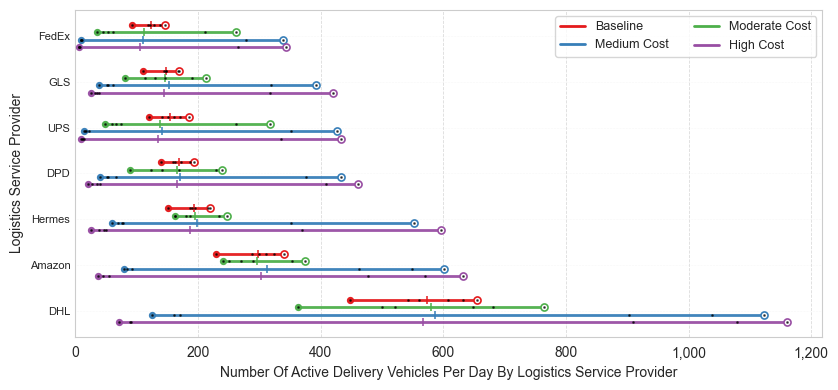

In [95]:
## =============================================================================
# Lollipop per scenario: per-carrier weekly min, mean, and max vehicles (providers visible)
# =============================================================================
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# --- 1) Prepare scenario, weekday, provider -----------------------------------
work = df.copy()

# Common weekday map (EN->DE) used for both detection and normalization
map_en_de = {
    "Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
    "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"
}

# Scenario column (fallback from run_name if missing)
if "scenario" not in work.columns and "run_name" in work.columns:
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

def _weekday_from_runname(run_name):
    m = re.search(r"_(\d{8})_", str(run_name))
    if not m:
        return None
    dt = datetime.strptime(m.group(1), "%d%m%Y")
    return map_en_de.get(dt.strftime("%A"))

# Weekday column: use existing if present; otherwise derive from run_name
if "weekday" in work.columns:
    w_raw = work["weekday"].astype(str)
    w_mapped = w_raw.map(map_en_de)
    work["weekday"] = w_mapped.fillna(w_raw)  # keep german if already german
elif "run_name" in work.columns:
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)
else:
    raise RuntimeError("No weekday information: neither 'weekday' nor 'run_name' available.")

if "provider" not in work.columns:
    raise RuntimeError("Column 'provider' missing in df_all/df")

weekday_order = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# Scenario label mapping: prefer global mapping and order if present
scenario_display_local = scenario_display if "scenario_display" in globals() else {
    "basecase":"Baseline",
    "batchmoderate":"Moderate Cost",
    "batchmedium":"Medium Cost",
    "batchhigh":"High Cost",
}
work["scenario_label"] = work["scenario"].astype(str).map(scenario_display_local).fillna(work["scenario"].astype(str))
present_labels = work["scenario_label"].dropna().astype(str).unique().tolist()

scenario_order_local = None
if "scenario_order" in globals() and scenario_order:
    scenario_order_local = [s for s in scenario_order if s in present_labels] + [s for s in present_labels if s not in scenario_order]
elif "scenarios_plot" in globals() and "BASELINE" in globals():
    pref = [str(BASELINE)] + [str(s) for s in scenarios_plot]
    scenario_order_local = [scenario_display_local.get(s, s) for s in pref if scenario_display_local.get(s, s) in present_labels] + [s for s in present_labels if s not in pref]
else:
    scenario_order_local = sorted(present_labels)

if not scenario_order_local:
    raise RuntimeError(f"No scenarios present in data. Found labels: {present_labels}")

if work.dropna(subset=["weekday"]).empty:
    raise RuntimeError("No rows with weekdays present after preprocessing. Check weekday values or run_name format.")

# --- 2) Aggregate per-day vehicle counts --------------------------------------
if "run_name" in work.columns:
    per_run = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday","run_name"], dropna=False)
            .size().reset_index(name="vehicles")
    )
    per_day = (
        per_run.groupby(["scenario_label","provider","weekday"], dropna=False)["vehicles"]
               .max().reset_index()
    )
else:
    per_day = (
        work.dropna(subset=["weekday"])
            .groupby(["scenario_label","provider","weekday"], dropna=False)
            .size().reset_index(name="vehicles")
    )

# --- 3) Weekly min, mean, max per carrier per scenario -------------------------
weekly_stats = (
    per_day.groupby(["scenario_label","provider"], dropna=False)["vehicles"]
           .agg(week_min="min", week_mean="mean", week_max="max")
           .reset_index()
)
if weekly_stats.empty:
    raise RuntimeError("No weekly vehicle stats computed. Check provider/scenario/weekday data.")

# --- 4) Provider order (no anonymization, tidy names) --------------------------
name_map = {
    "dhl":"DHL",
    "hermes":"Hermes",
    "dpd":"DPD",
    "gls":"GLS",
    "ups":"UPS",
    "amazon":"Amazon",
    "fedex":"FedEx",
}
def _clean_provider(p):
    if p is None:
        return p
    key = str(p).strip().lower()
    return name_map.get(key, str(p).strip())
weekly_stats["provider_display"] = weekly_stats["provider"].apply(_clean_provider)
provider_display_map = dict(zip(weekly_stats["provider"], weekly_stats["provider_display"]))
provider_order = (
    weekly_stats.groupby("provider")["week_max"]
    .max()
    .sort_values(ascending=False)
    .index.tolist()
)
provider_order_display = [provider_display_map.get(p, p) for p in provider_order]
if not provider_order_display:
    raise RuntimeError("No providers after grouping. Check provider values.")

# --- Build full matrix in the exact desired order ---
idx = pd.MultiIndex.from_product([provider_order_display, scenario_order_local],
                                 names=["provider_display", "scenario_label"])
plot_df = (
    weekly_stats.set_index(["provider_display", "scenario_label"])
                .reindex(idx)               # <- respects both orders
                .reset_index()
)

# --- 6) Plot setup -------------------------------------------------------------
sns.set_style("whitegrid")
palette = sns.color_palette("Set1", len(scenario_order_local))
colors = dict(zip(scenario_order_local, palette))

# Offsets vertically per scenario
offset_map = {
    "Baseline":       0.24,
    "Moderate Cost":  0.08,
    "Medium Cost":   -0.08,
    "High Cost":     -0.24,
}
default_offset = 0.0

# Create figure
fig, ax = plt.subplots(figsize=(8.5, max(4, 0.40*len(provider_order_display))))
y_base = np.arange(len(provider_order_display))
ax.set_yticks(y_base)
ax.set_yticklabels(provider_order_display, fontsize=8)

xmax_global = float(plot_df["week_max"].max()) if plot_df["week_max"].notna().any() else 1.0
ax.set_xlim(0.0, xmax_global * 1.05)

# --- 7) Draw lollipops with mean markers + weekday dots (on scenario line) -----
for i, scen in enumerate(scenario_order_local):
    sub = plot_df[plot_df["scenario_label"] == scen].set_index("provider_display").reindex(provider_order_display)
    c = colors.get(scen, (0.4, 0.4, 0.4))
    y = y_base + offset_map.get(scen, default_offset)

    x_min = sub["week_min"].fillna(0.0).values
    x_max = sub["week_max"].fillna(0.0).values
    x_mean = sub["week_mean"].fillna(0.0).values

    z = 10 + i
    # Lollipop line
    ax.hlines(y=y, xmin=x_min, xmax=x_max, color=c, alpha=0.95, linewidth=2.0, zorder=z)
    # Min marker
    ax.scatter(x_min, y, s=18, color=c, alpha=0.95, zorder=z+1)
    # Max marker (white)
    ax.scatter(x_max, y, s=26, facecolors="white", edgecolors=c, linewidths=1.2, zorder=z+2)
    # Mean marker (small X)
    ax.scatter(x_mean, y, marker="|", s=35, color=c, linewidths=1.1, zorder=z+3)

    # Small weekday dots directly on scenario line (no labels)
    per_day_sub = per_day[per_day["scenario_label"] == scen].copy()
    for p_disp, y0 in zip(provider_order_display, y_base):
        rows = per_day_sub[per_day_sub["provider"].map(provider_display_map) == p_disp]
        if rows.empty:
            continue
        for _, r in rows.iterrows():
            veh = float(r["vehicles"]) if pd.notna(r["vehicles"]) else np.nan
            if not np.isfinite(veh):
                continue
            ax.scatter(veh, y0 + offset_map.get(scen, default_offset), s=1, color="black", alpha=0.6, zorder=z+40)

# --- 8) Formatting ------------------------------------------------------------
ax.set_xlabel(
    "Number Of Active Delivery Vehicles Per Day By Logistics Service Provider",
    fontsize=10
)
ax.set_ylabel("Logistics Service Provider", fontsize=10)
ax.grid(axis="x", linestyle="--", linewidth=0.6, color="0.8", alpha=0.7)
ax.grid(axis="y", linestyle=":", linewidth=0.4, color="0.9", alpha=0.6)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

# Legend in correct order
handles = [
    Line2D([0],[0], color=colors[s], lw=2.0, label=s)
    for s in scenario_order_local if s in plot_df["scenario_label"].unique()
]
ax.legend(handles=handles, title="", ncols=2, fontsize=9, frameon=True, loc="upper right")

ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig("lollipop_weekly_min_mean_max_per_carrier_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [120]:
df_all.groupby("scenario")["vehicle_cost"].sum()

scenario
basecase         2.289263e+06
batchhigh        2.116528e+06
batchmedium      2.233142e+06
batchmoderate    2.248796e+06
Name: vehicle_cost, dtype: float64

C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_36904\964384590.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["weekday","scenario_label","activity_group"], dropna=False)


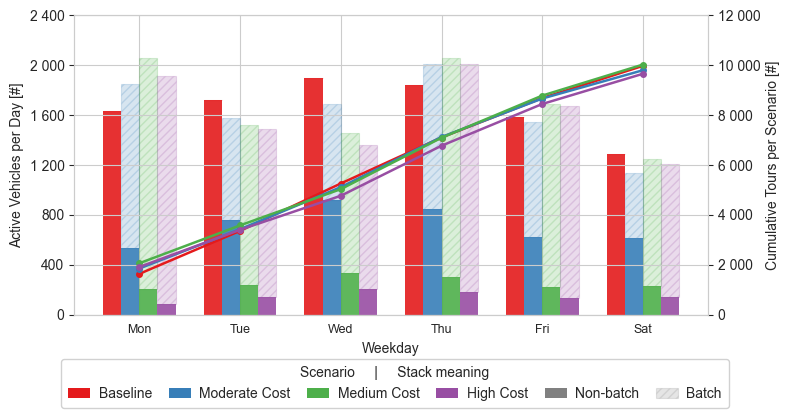


=== Vehicle (tour) count by scenario & activity_group ===
scenario_label         activity_group  # Vehicles (tours)
      Baseline     Batch Delivery Day                   0
      Baseline Non-batch Delivery Day                9979
     High Cost     Batch Delivery Day                8780
     High Cost Non-batch Delivery Day                 881
   Medium Cost     Batch Delivery Day                8502
   Medium Cost Non-batch Delivery Day                1529
 Moderate Cost     Batch Delivery Day                5503
 Moderate Cost Non-batch Delivery Day                4301
      Baseline                  Total                9979
     High Cost                  Total                9661
   Medium Cost                  Total               10031
 Moderate Cost                  Total                9804



In [118]:
# =============================================================================
# Stacked bars: daily vehicle (tour) counts per scenario, split Non-batch/Batch
# + cumulative total tours per scenario (second y-axis, synced ticks)
# =============================================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from matplotlib.ticker import MaxNLocator, FuncFormatter
from matplotlib.patches import Patch

# ---------- 1) Prepare df (wie im Distanz-Plot) ----------
work = df_all.copy()

# scenario
if "scenario" not in work.columns:
    if "run_name" not in work.columns:
        raise RuntimeError("run_name missing; cannot derive scenario")
    work["scenario"] = work["run_name"].astype(str).str.split("_").str[0]

# weekday (German)
if "weekday" not in work.columns:
    def _weekday_from_runname(run_name):
        m = re.search(r"_(\d{8})_", str(run_name))
        if not m:
            return None
        dt = datetime.strptime(m.group(1), "%d%m%Y")
        map_en_de = {"Monday":"Montag","Tuesday":"Dienstag","Wednesday":"Mittwoch",
                     "Thursday":"Donnerstag","Friday":"Freitag","Saturday":"Samstag"}
        return map_en_de.get(dt.strftime("%A"))
    work["weekday"] = work["run_name"].apply(_weekday_from_runname)

weekday_order  = ["Montag","Dienstag","Mittwoch","Donnerstag","Freitag","Samstag"]
weekday_labels = ["Mon","Tue","Wed","Thu","Fri","Sat"]
weekday_map = {
    "monday": "Montag", "mon": "Montag", "1": "Montag",
    "tuesday": "Dienstag", "tue": "Dienstag", "tues": "Dienstag", "2": "Dienstag",
    "wednesday": "Mittwoch", "wed": "Mittwoch", "3": "Mittwoch",
    "thursday": "Donnerstag", "thu": "Donnerstag", "thur": "Donnerstag", "thurs": "Donnerstag", "4": "Donnerstag",
    "friday": "Freitag", "fri": "Freitag", "5": "Freitag",
    "saturday": "Samstag", "sat": "Samstag", "6": "Samstag",
}

def _normalize_weekday(val):
    if pd.isna(val):
        return None
    s = str(val).strip()
    key = s.lower()
    return weekday_map.get(key, s if s in weekday_order else None)

work["weekday"] = work["weekday"].apply(_normalize_weekday)
work = work.dropna(subset=["weekday"]).copy()
work["weekday"] = pd.Categorical(work["weekday"], categories=weekday_order, ordered=True)

# activity_group (Batch-Day vs Non-batch-Day)
if "activity_group" not in work.columns:
    provider_active_days = {
        "dhl": {"Montag","Mittwoch","Freitag"},
        "hermes": {"Dienstag","Samstag"},
        "dpd": {"Dienstag","Freitag"},
        "gls": {"Montag","Donnerstag"},
        "ups": {"Montag","Donnerstag"},
        "amazon": {"Dienstag","Donnerstag","Samstag"},
        "fedex": {"Montag","Donnerstag"},
    }
    def _is_active(row):
        prov = str(row.get("provider","")).strip().lower()
        wd   = str(row.get("weekday","")).strip()
        return wd in provider_active_days.get(prov, set())
    work["active_flag"]   = work.apply(_is_active, axis=1)
    work["activity_group"] = np.where(work["active_flag"], "Batch Delivery Day", "Non-batch Delivery Day")

# Baseline stets Non-batch
work.loc[work["scenario"].str.lower().str.contains("base"), "activity_group"] = "Non-batch Delivery Day"

# Szenario Labels / Reihenfolge / Farben
scenario_display = {
    "basecase": "Baseline",
    "batchmoderate": "Moderate Cost",
    "batchmedium":  "Medium Cost",
    "batchhigh":    "High Cost",
}
work["scenario_label"] = work["scenario"].map(scenario_display).fillna(work["scenario"])
scenario_order = ["Baseline","Moderate Cost","Medium Cost","High Cost"]
scen_present  = [s for s in scenario_order if s in work["scenario_label"].unique().tolist()] or \
                sorted(work["scenario_label"].unique().tolist())

# ---------- 2) Aggregate: tägliche Tour-Anzahlen je activity_group ----------
# Eine Zeile im df = eine Tour → zählen:
daily = (
    work.dropna(subset=["weekday"])
        .groupby(["weekday","scenario_label","activity_group"], dropna=False)
        .size()
        .reset_index(name="tours")
)

# Ensure both stacks per day/scenario
all_keys = pd.MultiIndex.from_product(
    [weekday_order, scen_present, ["Non-batch Delivery Day","Batch Delivery Day"]],
    names=["weekday","scenario_label","activity_group"]
)
daily = (daily.set_index(["weekday","scenario_label","activity_group"])
              .reindex(all_keys).fillna(0).reset_index())

# Pivot zu Spalten „Non-batch tours“ / „Batch tours“
pivot = (
    daily.pivot_table(index=["weekday","scenario_label"], columns="activity_group",
                      values="tours", aggfunc="sum")
         .reset_index()
         .rename(columns={
             "Non-batch Delivery Day": "Non-batch tours",
             "Batch Delivery Day":     "Batch tours"
         })
)

# ---------- 3) Plot ----------
sns.set_style("whitegrid")
palette = sns.color_palette("Set1", len(scenario_order))
colors  = dict(zip(scenario_order, palette))

fig, ax1 = plt.subplots(figsize=(8,4))
x_pos = np.arange(len(weekday_order))
width = 0.18
hatch_pattern = "////"
edge_lw = 0.8

# Bars (stacked)
for i, scen in enumerate(scen_present):
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    nonbatch = sub["Non-batch tours"].to_numpy()
    batch    = sub["Batch tours"].to_numpy()
    xpos     = x_pos + (i - (len(scen_present)-1)/2.0)*width
    base_col = colors.get(scen, (0.5,0.5,0.5))

    ax1.bar(xpos, nonbatch, width=width, color=base_col, alpha=0.9, edgecolor="none")
    ax1.bar(xpos, batch,    width=width, bottom=nonbatch,
            facecolor=base_col, alpha=0.2, hatch=hatch_pattern,
            edgecolor=base_col, linewidth=edge_lw)

# Lines (cumulative total tours per scenario)
ax2   = ax1.twinx()
max_y = 0
for scen in scen_present:
    sub = pivot[pivot["scenario_label"] == scen].set_index("weekday").reindex(weekday_order)
    total = sub["Non-batch tours"] + sub["Batch tours"]
    cum   = total.cumsum()
    max_y = max(max_y, cum.max())
    ax2.plot(x_pos, cum, color=colors[scen], linewidth=1.8, marker="o", markersize=4,
             label=f"{scen} cumulative")

# ---------- 4) Synchronisierte Ticks ----------
# datengetriebene Bereiche mit Puffer
ax1_min, ax1_max = 0.0, max(10.0, 2400  if len(daily) else 10.0)
ax2_min, ax2_max = 0.0, max(10.0, 12000)

ax2.set_ylim(ax2_min, ax2_max)
ax1.set_ylim(ax1_min, ax1_max)

# schöne Ticks rechts, links gespiegelt
nbins = 6
ax2.yaxis.set_major_locator(MaxNLocator(nbins=nbins))
ax2_ticks = ax2.get_yticks()
tick_fracs = (ax2_ticks - ax2_min)/(ax2_max - ax2_min) if (ax2_max - ax2_min) else np.zeros_like(ax2_ticks)
ax1.set_yticks(ax1_min + tick_fracs*(ax1_max - ax1_min))

fmt = FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", " "))
ax1.yaxis.set_major_formatter(fmt)
ax2.yaxis.set_major_formatter(fmt)

# Achsen, Labels, X-Ticks
ax1.set_xlabel("Weekday", fontsize=10)
ax1.set_ylabel("Active Vehicles per Day [#]", fontsize=10)
ax2.set_ylabel("Cumulative Tours per Scenario [#]", fontsize=10)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(weekday_labels, fontsize=9)

ax1.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)
ax1.set_axisbelow(True)

# Gemeinsame Legende unten (Szenarien + Stack-Bedeutung)
scenario_handles = [Patch(facecolor=colors[s], edgecolor="none", label=s) for s in scen_present]
stack_handles = [
    Patch(facecolor="gray", edgecolor="none", label="Non-batch"),
    Patch(facecolor="gray", alpha=0.20, hatch=hatch_pattern, edgecolor="gray", linewidth=edge_lw, label="Batch"),
]
handles = scenario_handles + stack_handles
labels  = [h.get_label() for h in handles]
fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.05),
           ncol=len(handles), frameon=True, fancybox=True, framealpha=0.9,
           title="Scenario     |     Stack meaning",
           handlelength=1.6, handletextpad=0.6, columnspacing=1.2, borderpad=0.5)

plt.tight_layout(rect=(0, 0.06, 1, 1))
plt.savefig("vehicles_all_scenarios.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ---------- 5) Optional: Summen drucken ----------
totals = (
    daily.assign(tours=lambda d: d["tours"].astype(int))
         .groupby(["scenario_label","activity_group"], dropna=False)["tours"]
         .sum()
         .reset_index()
)
totals_all = totals.groupby("scenario_label", as_index=False)["tours"].sum().assign(activity_group="Total")
print("\n=== Vehicle (tour) count by scenario & activity_group ===")
print(pd.concat([totals, totals_all], ignore_index=True)
        .rename(columns={"tours":"# Vehicles (tours)"}).to_string(index=False))
print("==========================================================\n")
